# Controlled Benchmark Analysis — Notebook V1

This notebook analyzes the frozen **Controlled12** benchmark for:

- PyMuPDF4LLM
- Docling
- MinerU
- PaddleOCR / PPStructureV3

## Scope

V1 is an **operational and structural comparison**, not a final quality ranking.

It covers the reproduction procedure, the frozen official snapshot, comparability gates, processing integrity, OCR behavior, tokens, normalization, performance, resource consumption, Markdown structure/noise, per-page anomalies, operational trade-offs, and limitations.

**Methodological rule:** parser-native object counts are diagnostics, not ground truth. A final parser-quality ranking requires an external reviewed reference.

## 1. Reproduce the Controlled12 benchmark

Run the commands in this section from the repository root after cloning the repository and confirming that Docker with Docker Compose is available.

Controlled input:

```text
data/benchmark/controlled/benchmark_controlado_v1.pdf
```

Reproduction runs deliberately write to:

```text
outputs/reproduction/
```

This prevents a local rerun from overwriting the committed official benchmark snapshot.

CPU, RAM and elapsed time can vary across machines. Model download/cache-population time must not be interpreted as formal parser benchmark time.

### 1.1 Build all Docker images

```bash
docker compose build
```

### 1.2 Docling model preparation

The validated Docling CPU/OCR profile uses local artifacts for layout, TableFormer and RapidOCR (`torch:pt`).

Run this before the measured Docling reproduction:

```bash
docker compose run --rm \
  --entrypoint sh \
  docling \
  -lc '
set -eu

docling-tools models download \
  --output-dir /home/appuser/.cache/docling/models \
  --rapidocr-backend-lang torch:pt \
  layout \
  tableformer \
  rapidocr
'
```

In restricted corporate environments, model acquisition must follow the organization's approved network and certificate process.

### 1.3 PyMuPDF4LLM

Profile: `ocr_auto_rapidtess`

```bash
docker compose run --rm \
  -e PYTHONPATH=/app \
  --entrypoint python \
  pymupdf \
  /app/src/parsers/pymupdf_v2.py \
  --input /data/benchmark/controlled/benchmark_controlado_v1.pdf \
  --output-root /outputs/reproduction \
  --profile ocr_auto_rapidtess \
  --artifacts all \
  --verbose
```

### 1.4 Docling

Profile: `ocr_auto`

```bash
docker compose run --rm \
  -e PYTHONPATH=/app \
  --entrypoint python \
  docling \
  /app/src/parsers/docling_v2.py \
  --input /data/benchmark/controlled/benchmark_controlado_v1.pdf \
  --output-root /outputs/reproduction \
  --profile ocr_auto \
  --artifacts all \
  --verbose
```

### 1.5 MinerU

Profile: `auto`

```bash
docker compose run --rm \
  -e PYTHONPATH=/app \
  --entrypoint python \
  mineru \
  /app/src/parsers/mineru_v2.py \
  --input /data/benchmark/controlled/benchmark_controlado_v1.pdf \
  --output-root /outputs/reproduction \
  --profile auto \
  --artifacts all \
  --verbose
```

On a clean machine, populate the MinerU model cache before treating a run as a warm-cache performance measurement.

### 1.6 PaddleOCR / PPStructureV3

Profile: `mvp_structured`

```bash
docker compose run --rm \
  -e PYTHONPATH=/app \
  --entrypoint python \
  paddleocr \
  /app/src/parsers/paddleocr_v2.py \
  --input /data/benchmark/controlled/benchmark_controlado_v1.pdf \
  --output-root /outputs/reproduction \
  --profile mvp_structured \
  --artifacts all \
  --verbose
```

On a clean machine, populate the PaddleOCR model cache before treating a run as a warm-cache performance measurement.

### 1.7 Expected artifacts

Each parser run must produce:

```text
on the following directory:
/outputs/reproduction/<parcer_name>/benchmark_controlado_v1/<execution_mode>/
these files will be produced:
raw.md
document.md
document.jsonl
metrics.json
removed_content.jsonl
run.log
```

If the artifact set is incomplete, stop and investigate before comparing the run.

## 2. Load the frozen official benchmark snapshot

In [16]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

In [17]:
def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (
            (candidate / "compose.yaml").is_file()
            and (candidate / "config" / "benchmark_profiles.json").is_file()
            and (candidate / "outputs").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Repository root not found. Start Jupyter from inside the "
        "document-ai-benchmark repository."
    )


REPO_ROOT = find_repo_root()

CONTROLLED_PDF = (
    REPO_ROOT
    / "data"
    / "benchmark"
    / "controlled"
    / "benchmark_controlado_v1.pdf"
)

SOURCE_INVENTORY = (
    REPO_ROOT
    / "outputs"
    / "_source_inventory"
    / "benchmark_controlado_v1.json"
)

JOBS = {
    "PyMuPDF": REPO_ROOT / "outputs" / "pymupdf" / "benchmark_controlado_v1" / "ocr_auto_rapidtess",
    "Docling": REPO_ROOT / "outputs" / "docling" / "benchmark_controlado_v1" / "ocr_auto",
    "MinerU": REPO_ROOT / "outputs" / "mineru" / "benchmark_controlado_v1" / "auto",
    "PaddleOCR": REPO_ROOT / "outputs" / "paddleocr" / "benchmark_controlado_v1" / "mvp_structured",
}

print("Repository root:", REPO_ROOT)
print("Controlled PDF:", CONTROLLED_PDF)
print("Jobs:", ", ".join(JOBS))

Repository root: /home/victorperone/workspace/document-ai-benchmark
Controlled PDF: /home/victorperone/workspace/document-ai-benchmark/data/benchmark/controlled/benchmark_controlado_v1.pdf
Jobs: PyMuPDF, Docling, MinerU, PaddleOCR


In [18]:
EXPECTED_ARTIFACTS = (
    "raw.md",
    "document.md",
    "document.jsonl",
    "metrics.json",
    "removed_content.jsonl",
    "run.log",
)

required_paths = [CONTROLLED_PDF, SOURCE_INVENTORY]

for job_dir in JOBS.values():
    required_paths.extend(job_dir / name for name in EXPECTED_ARTIFACTS)

missing = [path for path in required_paths if not path.is_file()]

if missing:
    formatted = "\n".join(f" - {path}" for path in missing)
    raise FileNotFoundError(
        "The frozen Controlled12 snapshot is incomplete:\n" + formatted
    )

print(f"Artifact presence check: PASS ({len(required_paths)} files)")

Artifact presence check: PASS (26 files)


In [19]:
def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def load_jsonl(path: Path) -> list[dict]:
    records = []

    with path.open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue

            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(
                    f"Invalid JSONL in {path} at line {line_number}"
                ) from exc

    return records


metrics_by_parser = {
    parser: load_json(job_dir / "metrics.json")
    for parser, job_dir in JOBS.items()
}

pages_by_parser = {
    parser: load_jsonl(job_dir / "document.jsonl")
    for parser, job_dir in JOBS.items()
}

removed_by_parser = {
    parser: load_jsonl(job_dir / "removed_content.jsonl")
    for parser, job_dir in JOBS.items()
}

source_inventory = load_json(SOURCE_INVENTORY)

print("Loaded metrics:", len(metrics_by_parser))
print(
    "JSONL page records:",
    {parser: len(records) for parser, records in pages_by_parser.items()},
)

Loaded metrics: 4
JSONL page records: {'PyMuPDF': 12, 'Docling': 12, 'MinerU': 12, 'PaddleOCR': 12}


In [20]:
snapshot_rows = []

for parser, job_dir in JOBS.items():
    snapshot_rows.append(
        {
            "parser": parser,
            "profile_dir": job_dir.name,
            "metrics_bytes": (job_dir / "metrics.json").stat().st_size,
            "document_md_bytes": (job_dir / "document.md").stat().st_size,
            "document_jsonl_bytes": (job_dir / "document.jsonl").stat().st_size,
            "removed_jsonl_bytes": (job_dir / "removed_content.jsonl").stat().st_size,
            "run_log_bytes": (job_dir / "run.log").stat().st_size,
        }
    )

df_snapshot = pd.DataFrame(snapshot_rows).set_index("parser")
df_snapshot

,profile_dir,metrics_bytes,document_md_bytes,document_jsonl_bytes,removed_jsonl_bytes,run_log_bytes
parser,,,,,,
PyMuPDF,ocr_auto_rapidtess,8214,13597,48504,2522,917
Docling,ocr_auto,9458,13897,66868,0,955
MinerU,auto,8192,19590,73971,7244,10447
PaddleOCR,mvp_structured,9896,14703,35429,0,323


## 3. Gate 1 — Comparability

Before any performance comparison, the notebook checks the shared invariants:

- document SHA-256;
- page count;
- schema version;
- reference tokenizer;
- resource-monitor version;
- monitor sampling interval;
- normalization configuration.

Parser name/profile and parser-specific configuration are expected to differ and are reported rather than forced to be equal.

In [21]:
def require_path(data: dict, *keys):
    current = data
    walked = []

    for key in keys:
        walked.append(key)

        if not isinstance(current, dict) or key not in current:
            raise KeyError(
                "Required metrics field missing: " + ".".join(walked)
            )

        current = current[key]

    return current


def canonical_json(value) -> str:
    return json.dumps(
        value,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    )


comparability_rows = []

for label, metrics in metrics_by_parser.items():
    comparability_rows.append(
        {
            "parser": label,
            "stored_parser": require_path(metrics, "run", "parser"),
            "profile": require_path(metrics, "run", "profile"),
            "sha256": require_path(metrics, "document", "sha256"),
            "pages": require_path(metrics, "document", "pages"),
            "schema_version": require_path(
                metrics, "benchmark", "schema_version"
            ),
            "reference_tokenizer": require_path(
                metrics, "benchmark", "reference_tokenizer"
            ),
            "monitor_version": require_path(
                metrics, "resources", "monitor_version"
            ),
            "sampling_interval_seconds": require_path(
                metrics, "resources", "sampling_interval_seconds"
            ),
            "logical_cpus": require_path(
                metrics, "resources", "logical_cpus"
            ),
            "normalization_config": canonical_json(
                require_path(metrics, "normalization", "config")
            ),
        }
    )

df_comparability = pd.DataFrame(comparability_rows).set_index("parser")
df_comparability

,stored_parser,profile,sha256,pages,schema_version,reference_tokenizer,monitor_version,sampling_interval_seconds,logical_cpus,normalization_config
parser,,,,,,,,,,
PyMuPDF,pymupdf,ocr_auto_rapidtess,8089a3e142f9e8bcc5b92e5b2cc5313ff9be41ef5f2947aae69984ee07a749f7,12,2,o200k_base,process_tree_v2,0.1,20,"{""footer_candidate_lines"":3,""header_candidate_lines"":3,""header_footer_cleanup"":true,""keep_removed_content_audit"":tru..."
Docling,docling,ocr_auto,8089a3e142f9e8bcc5b92e5b2cc5313ff9be41ef5f2947aae69984ee07a749f7,12,2,o200k_base,process_tree_v2,0.1,20,"{""footer_candidate_lines"":3,""header_candidate_lines"":3,""header_footer_cleanup"":true,""keep_removed_content_audit"":tru..."
MinerU,mineru,auto,8089a3e142f9e8bcc5b92e5b2cc5313ff9be41ef5f2947aae69984ee07a749f7,12,2,o200k_base,process_tree_v2,0.1,20,"{""footer_candidate_lines"":3,""header_candidate_lines"":3,""header_footer_cleanup"":true,""keep_removed_content_audit"":tru..."
PaddleOCR,paddleocr,mvp_structured,8089a3e142f9e8bcc5b92e5b2cc5313ff9be41ef5f2947aae69984ee07a749f7,12,2,o200k_base,process_tree_v2,0.1,20,"{""footer_candidate_lines"":3,""header_candidate_lines"":3,""header_footer_cleanup"":true,""keep_removed_content_audit"":tru..."


In [22]:
def assert_single_value(frame: pd.DataFrame, column: str) -> None:
    values = frame[column].tolist()
    unique = []

    for value in values:
        if value not in unique:
            unique.append(value)

    if len(unique) != 1:
        raise AssertionError(
            f"Comparability gate FAILED for {column}: {unique}"
        )


GATE_COLUMNS = (
    "sha256",
    "pages",
    "schema_version",
    "reference_tokenizer",
    "monitor_version",
    "sampling_interval_seconds",
    "normalization_config",
)

for column in GATE_COLUMNS:
    assert_single_value(df_comparability, column)

inventory_sha = source_inventory.get("sha256")
metrics_sha = df_comparability["sha256"].iloc[0]

if inventory_sha is None:
    raise KeyError("Source Inventory is missing top-level field: sha256")

if inventory_sha != metrics_sha:
    raise AssertionError(
        "Source Inventory SHA-256 does not match parser metrics."
    )

expected_page_records = int(df_comparability["pages"].iloc[0])

for parser, records in pages_by_parser.items():
    page_numbers = [record.get("page_number") for record in records]
    expected_numbers = list(range(1, expected_page_records + 1))

    if page_numbers != expected_numbers:
        raise AssertionError(
            f"{parser}: document.jsonl page sequence mismatch. "
            f"Observed={page_numbers}, expected={expected_numbers}"
        )

print("COMPARABILITY GATE: PASS")
print(f"Document SHA-256: {metrics_sha}")
print(f"Pages: {expected_page_records}")
print(
    "Reference tokenizer:",
    df_comparability["reference_tokenizer"].iloc[0],
)
print(
    "Monitor:",
    df_comparability["monitor_version"].iloc[0],
)

COMPARABILITY GATE: PASS
Document SHA-256: 8089a3e142f9e8bcc5b92e5b2cc5313ff9be41ef5f2947aae69984ee07a749f7
Pages: 12
Reference tokenizer: o200k_base
Monitor: process_tree_v2


### Gate interpretation

A `PASS` means the frozen jobs satisfy the minimum shared invariants required for the V1 comparison.

It does not mean the parsers have equivalent OCR behavior or equivalent internal models.

If this cell fails, stop the analysis before generating comparative conclusions.

## 4. Processing integrity

Before comparing tokens, runtime or resource consumption, this section verifies
that each parser completed the Controlled12 workload consistently.

The integrity analysis checks:

- expected document pages;
- processed pages;
- failed pages;
- partial pages, when available;
- empty output pages;
- canonical `document.jsonl` page records;
- conversion status, when available;
- warnings;
- errors;
- retries.

### Interpretation rules

A missing metric is **not interpreted as zero or failure**.

For example, the frozen PyMuPDF result does not expose
`conversion_status`. In that case, the value is reported as unavailable
rather than inferred.

Warnings and empty output pages are also not automatic processing failures.

A parser fails the processing-integrity gate only when the stored evidence
indicates an actual processing inconsistency, such as:

- missing processed pages;
- failed pages;
- parser errors;
- conversion failure;
- inconsistent canonical page records.

In [37]:
def optional_path(
    data: dict,
    *keys,
    default=None,
):
    """
    Read an optional nested metric.

    Missing fields remain unavailable instead of being
    interpreted as zero.
    """
    current = data

    for key in keys:
        if not isinstance(current, dict):
            return default

        if key not in current:
            return default

        current = current[key]

    return current


def markdown_is_empty(text) -> bool:
    """
    Match the Common Core empty-page definition:
    a page is empty when it contains no alphanumeric character.
    """
    text = text or ""

    return not any(
        character.isalnum()
        for character in text
    )


integrity_rows = []

for parser, metrics in metrics_by_parser.items():
    processing = require_path(
        metrics,
        "processing",
    )

    page_records = pages_by_parser[parser]

    empty_page_numbers = [
        record["page_number"]
        for record in page_records
        if markdown_is_empty(
            record.get(
                "clean_markdown",
                "",
            )
        )
    ]

    document_pages = require_path(
        metrics,
        "document",
        "pages",
    )

    pages_total = require_path(
        processing,
        "pages_total",
    )

    pages_processed = require_path(
        processing,
        "pages_processed",
    )

    failed_pages = require_path(
        processing,
        "failed_pages",
    )

    partial_pages = require_path(
        processing,
        "partial_pages",
    )

    empty_output_pages = require_path(
        processing,
        "empty_output_pages",
    )

    errors_count = require_path(
        processing,
        "errors_count",
    )

    retry_count = require_path(
        processing,
        "retry_count",
    )

    warnings_count = require_path(
        processing,
        "warnings_count",
    )

    parser_log_warning_lines = require_path(
        processing,
        "parser_log_warning_lines",
    )

    parser_log_error_lines = require_path(
        processing,
        "parser_log_error_lines",
    )

    conversion_status = optional_path(
        processing,
        "conversion_status",
    )

    heuristic_empty_pages = require_path(
        metrics,
        "heuristics",
        "cleaned",
        "empty_pages",
    )

    completion_percent = (
        100.0 * pages_processed / pages_total
        if pages_total
        else None
    )

    integrity_rows.append(
        {
            "parser": parser,
            "document_pages": document_pages,
            "pages_total": pages_total,
            "pages_processed": pages_processed,
            "completion_percent": completion_percent,
            "failed_pages": failed_pages,
            "partial_pages": partial_pages,
            "empty_output_pages": empty_output_pages,
            "empty_page_numbers": empty_page_numbers,
            "heuristic_empty_pages": heuristic_empty_pages,
            "conversion_status": conversion_status,
            "warnings_count": warnings_count,
            "parser_log_warning_lines": parser_log_warning_lines,
            "errors_count": errors_count,
            "parser_log_error_lines": parser_log_error_lines,
            "retry_count": retry_count,
            "jsonl_page_records": len(page_records),
        }
    )


df_integrity = (
    pd.DataFrame(integrity_rows)
    .set_index("parser")
)

In [38]:
df_integrity_summary = (
    df_integrity[
        [
            "pages_processed",
            "completion_percent",
            "failed_pages",
            "partial_pages",
            "empty_output_pages",
            "empty_page_numbers",
            "conversion_status",
            "warnings_count",
            "errors_count",
            "retry_count",
        ]
    ]
    .copy()
)


# Improve presentation without modifying the source metrics.
df_integrity_summary["completion_percent"] = (
    df_integrity_summary[
        "completion_percent"
    ]
    .round(1)
)

df_integrity_summary["partial_pages"] = (
    df_integrity_summary[
        "partial_pages"
    ]
    .apply(
        lambda value:
        "N/A"
        if pd.isna(value)
        else value
    )
)

df_integrity_summary["conversion_status"] = (
    df_integrity_summary[
        "conversion_status"
    ]
    .apply(
        lambda value:
        "N/A"
        if pd.isna(value)
        else value
    )
)


df_integrity_summary.columns = [
    "Pages processed",
    "Completion %",
    "Failed pages",
    "Partial pages",
    "Empty output pages",
    "Empty page numbers",
    "Conversion status",
    "Warnings",
    "Errors",
    "Retries",
]


df_integrity_summary

,Pages processed,Completion %,Failed pages,Partial pages,Empty output pages,Empty page numbers,Conversion status,Warnings,Errors,Retries
parser,,,,,,,,,,
PyMuPDF,12,100.0,0,N/A,0,[],N/A,0,0,0
Docling,12,100.0,0,N/A,1,[12],success,3,0,0
MinerU,12,100.0,0,N/A,1,[12],success,0,0,0
PaddleOCR,12,100.0,0,N/A,0,[],success,2,0,0


In [39]:
integrity_failures = []


for parser, row in df_integrity.iterrows():
    status = row[
        "conversion_status"
    ]

    partial_pages = row[
        "partial_pages"
    ]

    # Missing status means "not exposed",
    # not processing failure.
    status_ok = (
        pd.isna(status)
        or str(status).lower()
        == "success"
    )

    # Missing partial-page information
    # means "not exposed".
    partial_pages_ok = (
        pd.isna(partial_pages)
        or partial_pages == 0
    )

    page_count_consistent = (
        row["document_pages"]
        == row["pages_total"]
        == row["pages_processed"]
        == row["jsonl_page_records"]
    )

    empty_page_count_consistent = (
        row["empty_output_pages"]
        == row["heuristic_empty_pages"]
        == len(
            row[
                "empty_page_numbers"
            ]
        )
    )

    no_failed_pages = (
        row["failed_pages"]
        == 0
    )

    no_errors = (
        row["errors_count"]
        == 0
        and
        row[
            "parser_log_error_lines"
        ]
        == 0
    )

    checks = {
        "status_ok":
            status_ok,
        "partial_pages_ok":
            partial_pages_ok,
        "page_count_consistent":
            page_count_consistent,
        "empty_page_count_consistent":
            empty_page_count_consistent,
        "no_failed_pages":
            no_failed_pages,
        "no_errors":
            no_errors,
    }

    failed_checks = [
        name
        for name, passed
        in checks.items()
        if not passed
    ]

    if failed_checks:
        integrity_failures.append(
            {
                "parser": parser,
                "failed_checks":
                    failed_checks,
            }
        )


if integrity_failures:
    raise AssertionError(
        "PROCESSING INTEGRITY GATE FAILED:\n"
        + json.dumps(
            integrity_failures,
            indent=2,
            ensure_ascii=False,
        )
    )


print(
    "PROCESSING INTEGRITY GATE: PASS"
)

print(
    "All four parsers completed "
    "the integrity checks."
)

PROCESSING INTEGRITY GATE: PASS
All four parsers completed the integrity checks.


### Processing-integrity findings

All four parsers successfully completed the 12-page Controlled12 workload.

**No hard processing failures were observed:**

- all four parsers processed 12 of 12 pages;
- no failed pages were reported;
- no processing errors were reported;
- no parser-log error lines were recorded;
- no retries were required.

However, the successful executions were not identical.

#### Empty output pages

- **PyMuPDF:** no empty output pages.
- **Docling:** one empty output page.
- **MinerU:** one empty output page.
- **PaddleOCR:** no empty output pages.

The exact affected page numbers are shown in the executive table above.

An empty output page is treated as an **output anomaly**, not as an automatic
processing failure. The affected pages will be investigated later in the
per-page analysis.

#### Warnings

- **PyMuPDF:** no warnings.
- **MinerU:** no warnings.
- **Docling:** three warnings.
- **PaddleOCR:** two warnings.

The recorded warnings did not correspond to parser errors or failed pages,
therefore they do not cause the processing-integrity gate to fail.

#### Conversion status

Docling, MinerU and PaddleOCR explicitly report a conversion status of
`success`.

The frozen PyMuPDF metrics do not expose a `conversion_status` field.
This is reported as **N/A**, rather than being inferred as either success
or failure.

#### Processing-integrity conclusion

All four parsers pass the processing-integrity gate and can proceed to the
subsequent operational comparison.

The differences in empty output pages and warnings remain relevant diagnostic
signals and will be carried forward to the later page-level analysis.

## 5. OCR behavior

This section compares how OCR is configured and how much OCR activity can be
reliably observed for each parser.

The analysis separates two different concepts:

1. **OCR configuration** — whether OCR is enabled and how it is configured;
2. **OCR observability** — whether the parser exposes reliable page-level OCR
   counters.

These concepts must not be confused.

A missing OCR page counter does **not** mean that OCR was not executed.

### Interpretation rules

- `0` means the parser explicitly reported zero.
- `N/A` means the metric is not reliably exposed by the adapter.
- Page-level OCR counts are only compared when they are actually available.
- Parser-specific OCR strategies are reported descriptively and are not treated
  as equivalent workloads.
- The number of OCR pages is not a quality metric by itself.

For example, a parser that OCRs all pages is not automatically better or worse
than a parser that selectively invokes OCR.

In [40]:
ocr_rows = []

for parser, metrics in metrics_by_parser.items():
    ocr = require_path(
        metrics,
        "processing",
        "ocr",
    )

    pages_total = require_path(
        metrics,
        "processing",
        "pages_total",
    )

    pages_requested = optional_path(
        ocr,
        "pages_requested",
    )

    pages_processed = optional_path(
        ocr,
        "pages_processed",
    )

    failed_ocr_pages = optional_path(
        ocr,
        "failed_ocr_pages",
    )

    requested_page_numbers = optional_path(
        ocr,
        "requested_page_numbers",
    )

    failed_page_numbers = optional_path(
        ocr,
        "failed_page_numbers",
    )

    ocr_coverage_percent = (
        100.0
        * pages_processed
        / pages_total
        if (
            pages_processed is not None
            and pages_total
        )
        else None
    )

    ocr_rows.append(
        {
            "parser": parser,

            "enabled": optional_path(
                ocr,
                "enabled",
            ),

            "mode": optional_path(
                ocr,
                "mode",
            ),

            "engine": optional_path(
                ocr,
                "engine",
            ),

            "backend": optional_path(
                ocr,
                "backend",
            ),

            "language": optional_path(
                ocr,
                "language",
            ),

            "scale": optional_path(
                ocr,
                "scale",
            ),

            "effective_dpi": optional_path(
                ocr,
                "effective_dpi",
            ),

            "pages_total": pages_total,

            "pages_requested": pages_requested,

            "pages_processed": pages_processed,

            "ocr_coverage_percent":
                ocr_coverage_percent,

            "failed_ocr_pages":
                failed_ocr_pages,

            "requested_page_numbers":
                requested_page_numbers,

            "failed_page_numbers":
                failed_page_numbers,

            "tracking_note": optional_path(
                ocr,
                "tracking_note",
            ),
        }
    )


df_ocr = (
    pd.DataFrame(ocr_rows)
    .set_index("parser")
)

In [41]:
def display_na(value):
    if isinstance(value, (list, dict)):
        return value

    if pd.isna(value):
        return "N/A"

    return value


df_ocr_summary = (
    df_ocr[
        [
            "enabled",
            "mode",
            "engine",
            "backend",
            "language",
            "pages_requested",
            "pages_processed",
            "ocr_coverage_percent",
            "failed_ocr_pages",
            "requested_page_numbers",
        ]
    ]
    .copy()
)


df_ocr_summary[
    "ocr_coverage_percent"
] = (
    df_ocr_summary[
        "ocr_coverage_percent"
    ]
    .round(1)
)


for column in df_ocr_summary.columns:
    df_ocr_summary[column] = (
        df_ocr_summary[column]
        .apply(display_na)
    )


df_ocr_summary.columns = [
    "OCR enabled",
    "Mode",
    "Engine",
    "Backend",
    "Language",
    "Pages requested",
    "Pages processed",
    "OCR coverage %",
    "Failed OCR pages",
    "Requested page numbers",
]


df_ocr_summary

,OCR enabled,Mode,Engine,Backend,Language,Pages requested,Pages processed,OCR coverage %,Failed OCR pages,Requested page numbers
parser,,,,,,,,,,
PyMuPDF,True,auto,rapidtess,N/A,por,3.0,3.0,25.0,0.0,"[9, 10, 11]"
Docling,True,pdf_aware_layout_regions,rapidocr,torch,pt,N/A,N/A,N/A,N/A,N/A
MinerU,True,auto,N/A,pipeline,N/A,N/A,N/A,N/A,N/A,N/A
PaddleOCR,True,structured_document,PP-OCRv5_server,PPStructureV3,N/A,12.0,12.0,100.0,N/A,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"


In [42]:
ocr_page_rows = []

for parser, row in df_ocr.iterrows():
    requested_pages = row[
        "requested_page_numbers"
    ]

    processed_count = row[
        "pages_processed"
    ]

    if isinstance(
        requested_pages,
        list,
    ):
        observable = True

        observable_pages = (
            requested_pages
        )

    else:
        observable = False

        observable_pages = None

    ocr_page_rows.append(
        {
            "parser": parser,
            "page_level_tracking":
                (
                    "Available"
                    if observable
                    else "Unavailable"
                ),

            "observable_ocr_pages":
                (
                    observable_pages
                    if observable
                    else "N/A"
                ),

            "observable_page_count":
                (
                    processed_count
                    if observable
                    else "N/A"
                ),
        }
    )


df_ocr_pages = (
    pd.DataFrame(
        ocr_page_rows
    )
    .set_index("parser")
)


df_ocr_pages

,page_level_tracking,observable_ocr_pages,observable_page_count
parser,,,
PyMuPDF,Available,"[9, 10, 11]",3.0
Docling,Unavailable,N/A,N/A
MinerU,Unavailable,N/A,N/A
PaddleOCR,Available,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",12.0


In [43]:
ocr_tracking_failures = []


for parser, row in df_ocr.iterrows():
    requested_pages = row[
        "requested_page_numbers"
    ]

    pages_requested = row[
        "pages_requested"
    ]

    pages_processed = row[
        "pages_processed"
    ]

    failed_pages = row[
        "failed_page_numbers"
    ]

    failed_count = row[
        "failed_ocr_pages"
    ]

    # Only validate page-level counts when
    # the parser actually exposes them.
    if isinstance(
        requested_pages,
        list,
    ):
        if (
            pages_requested is not None
            and len(requested_pages)
            != pages_requested
        ):
            ocr_tracking_failures.append(
                {
                    "parser": parser,
                    "issue":
                        "requested page count mismatch",
                }
            )

        if (
            pages_processed is not None
            and pages_processed
            > len(requested_pages)
        ):
            ocr_tracking_failures.append(
                {
                    "parser": parser,
                    "issue":
                        "processed OCR pages exceed "
                        "requested pages",
                }
            )

    if isinstance(
        failed_pages,
        list,
    ):
        if (
            failed_count is not None
            and len(failed_pages)
            != failed_count
        ):
            ocr_tracking_failures.append(
                {
                    "parser": parser,
                    "issue":
                        "failed OCR page count mismatch",
                }
            )


if ocr_tracking_failures:
    raise AssertionError(
        "OCR TRACKING VALIDATION FAILED:\n"
        + json.dumps(
            ocr_tracking_failures,
            indent=2,
            ensure_ascii=False,
        )
    )


print(
    "OCR TRACKING VALIDATION: PASS"
)

print(
    "Available page-level OCR counters "
    "are internally consistent."
)

OCR TRACKING VALIDATION: PASS
Available page-level OCR counters are internally consistent.


### OCR findings

All four benchmark profiles have OCR capability enabled, but their OCR
strategies and level of observability differ substantially.

#### PyMuPDF

PyMuPDF uses selective automatic OCR.

For the Controlled12 document, page-level tracking is available and OCR was
requested only for a subset of the document.

The observable OCR page list allows the benchmark to distinguish native-text
processing from OCR fallback processing.

#### PaddleOCR

PaddleOCR uses its structured PPStructureV3 pipeline with OCR applied across
the complete Controlled12 workload.

Page-level OCR tracking is available for all 12 pages.

This represents a fundamentally different operational strategy from
PyMuPDF's selective OCR behavior.

#### Docling

OCR is enabled in the benchmark profile.

However, reliable page-level OCR request/processing counters are not exposed
by the frozen adapter.

The corresponding page counts are therefore reported as **N/A** rather than
being inferred.

#### MinerU

OCR is enabled through MinerU's native automatic pipeline.

Reliable page-level OCR counters are not exposed by the frozen adapter, so
the number of OCR-processed pages is also reported as **N/A**.

#### Interpretation

The observed OCR page counts must not be interpreted as an OCR-quality score.

The parsers follow different strategies:

- selective OCR;
- document-aware OCR;
- native automatic parsing/OCR pipelines;
- full structured OCR processing.

As a result, OCR workload differences are operational characteristics rather
than evidence that one parser is intrinsically more accurate.

OCR quality itself requires external reference-based evaluation and is outside
the scope of Notebook V1.

## 6. Tokens and normalization

This section compares the token footprint produced by each parser and the effect
of the shared normalization stage.

All benchmark jobs use the same reference tokenizer:

```text
o200k_base
```

**The analysis distinguishes:**

- **Raw Markdown tokens** — parser output before Common Core normalization;
- **Clean Markdown tokens** — output after normalization;
- **Tokens removed** — raw minus clean token count;
- **Token reduction %** — relative reduction introduced by normalization;
- **Tokens per page** — normalized document-size indicator;
- **Normalization audit records** — content removed by the shared normalizer.

**Interpretation rules**

A lower token count is **not automatically better.**

Token count can decrease because of:

- Removal of repeated headers or footers;
- Page-number normalization;
- Whitespace cleanup;
- Differences in Markdown representation;
- Missing or less detailed extracted content.

Therefore, token efficiency is treated as an operational metric, not as a
standalone quality metric.

The effect of the shared normalizer is analyzed separately from the parser's raw output.

In [51]:
token_rows = []

for parser, metrics in metrics_by_parser.items():
    tokens = require_path(
        metrics,
        "tokens",
        "reference",
    )

    normalization = require_path(
        metrics,
        "normalization",
    )

    pages = require_path(
        metrics,
        "document",
        "pages",
    )

    raw_tokens = require_path(
        tokens,
        "raw_markdown_tokens",
    )

    clean_tokens = require_path(
        tokens,
        "clean_markdown_tokens",
    )

    tokens_removed = require_path(
        tokens,
        "tokens_removed",
    )

    token_reduction_percent = require_path(
        tokens,
        "token_reduction_percent",
    )

    raw_tokens_per_page = require_path(
        tokens,
        "raw_tokens_per_page",
    )

    clean_tokens_per_page = require_path(
        tokens,
        "clean_tokens_per_page",
    )

    tokenizer = require_path(
        tokens,
        "tokenizer",
    )

    retention_percent = (
        100.0 * clean_tokens / raw_tokens
        if raw_tokens
        else None
    )

    removed_per_page = (
        tokens_removed / pages
        if pages
        else None
    )

    token_rows.append(
        {
            "parser": parser,
            "tokenizer": tokenizer,
            "raw_tokens": raw_tokens,
            "clean_tokens": clean_tokens,
            "tokens_removed": tokens_removed,
            "token_reduction_percent":
                token_reduction_percent,
            "retention_percent":
                retention_percent,
            "raw_tokens_per_page":
                raw_tokens_per_page,
            "clean_tokens_per_page":
                clean_tokens_per_page,
            "tokens_removed_per_page":
                removed_per_page,
            "removed_records": optional_path(
                normalization,
                "removed_records",
            ),
            "header_records_removed":
                optional_path(
                    normalization,
                    "header_records_removed",
                ),
            "footer_records_removed":
                optional_path(
                    normalization,
                    "footer_records_removed",
                ),
            "estimated_header_footer_tokens":
                require_path(
                    tokens,
                    "estimated_header_footer_record_tokens",
                ),
            "estimated_other_removed_tokens":
                require_path(
                    tokens,
                    "estimated_other_removed_record_tokens",
                ),
        }
    )


df_tokens = (
    pd.DataFrame(token_rows)
    .set_index("parser")
)

In [52]:
df_tokens_summary = (
    df_tokens[
        [
            "raw_tokens",
            "clean_tokens",
            "tokens_removed",
            "token_reduction_percent",
            "retention_percent",
            "raw_tokens_per_page",
            "clean_tokens_per_page",
        ]
    ]
    .copy()
)


for column in [
    "token_reduction_percent",
    "retention_percent",
    "raw_tokens_per_page",
    "clean_tokens_per_page",
]:
    df_tokens_summary[column] = (
        df_tokens_summary[column]
        .round(2)
    )


df_tokens_summary.columns = [
    "Raw tokens",
    "Final tokens",
    "Tokens removed",
    "Reduction %",
    "Retention %",
    "Raw tokens/page",
    "Clean tokens/page",
]


df_tokens_summary

,Raw tokens,Final tokens,Tokens removed,Reduction %,Retention %,Raw tokens/page,Clean tokens/page
parser,,,,,,,
PyMuPDF,4538,4406,132,2.91,97.09,378.17,367.17
Docling,3730,3730,0,0.00,100.00,310.83,310.83
MinerU,6307,6085,222,3.52,96.48,525.58,507.08
PaddleOCR,4666,4666,0,0.00,100.00,388.83,388.83


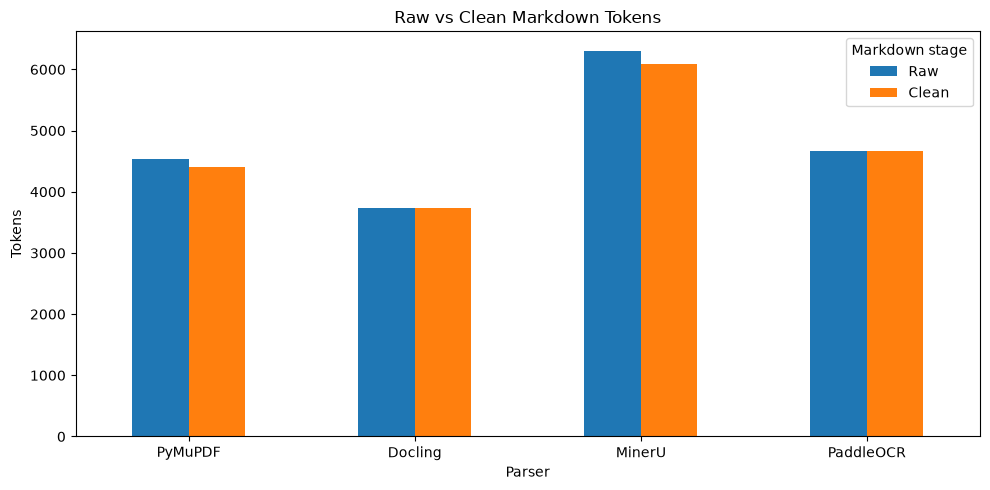

In [53]:
import matplotlib.pyplot as plt


plot_data = (
    df_tokens[
        [
            "raw_tokens",
            "clean_tokens",
        ]
    ]
    .rename(
        columns={
            "raw_tokens": "Raw",
            "clean_tokens": "Clean",
        }
    )
)


ax = plot_data.plot(
    kind="bar",
    figsize=(10, 5),
)

ax.set_title(
    "Raw vs Clean Markdown Tokens"
)

ax.set_xlabel(
    "Parser"
)

ax.set_ylabel(
    "Tokens"
)

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.legend(
    title="Markdown stage"
)

plt.tight_layout()
plt.show()

In [54]:
df_normalization_summary = (
    df_tokens[
        [
            "tokens_removed",
            "token_reduction_percent",
            "removed_records",
            "header_records_removed",
            "footer_records_removed",
            "estimated_header_footer_tokens",
            "estimated_other_removed_tokens",
        ]
    ]
    .copy()
)


df_normalization_summary[
    "token_reduction_percent"
] = (
    df_normalization_summary[
        "token_reduction_percent"
    ]
    .round(2)
)


for column in [
    "removed_records",
    "header_records_removed",
    "footer_records_removed",
]:
    df_normalization_summary[column] = (
        df_normalization_summary[column]
        .apply(
            lambda value:
            "N/A"
            if pd.isna(value)
            else value
        )
    )


df_normalization_summary.columns = [
    "Tokens removed",
    "Reduction %",
    "Removed records",
    "Header records removed",
    "Footer records removed",
    "Estimated header/footer tokens",
    "Estimated other removed tokens",
]


df_normalization_summary

,Tokens removed,Reduction %,Removed records,Header records removed,Footer records removed,Estimated header/footer tokens,Estimated other removed tokens
parser,,,,,,,
PyMuPDF,132,2.91,11,11,0,132,0
Docling,0,0.00,0,0,0,0,0
MinerU,222,3.52,34,11,23,188,0
PaddleOCR,0,0.00,0,0,0,0,0


In [55]:
token_validation_failures = []


for parser, row in df_tokens.iterrows():
    expected_removed = (
        row["raw_tokens"]
        - row["clean_tokens"]
    )

    if (
        expected_removed
        != row["tokens_removed"]
    ):
        token_validation_failures.append(
            {
                "parser": parser,
                "issue":
                    "raw - clean does not match "
                    "tokens_removed",
                "expected":
                    expected_removed,
                "stored":
                    row["tokens_removed"],
            }
        )

    if (
        row["clean_tokens"]
        > row["raw_tokens"]
    ):
        token_validation_failures.append(
            {
                "parser": parser,
                "issue":
                    "clean tokens exceed raw tokens",
            }
        )

    expected_reduction = (
        100.0
        * row["tokens_removed"]
        / row["raw_tokens"]
        if row["raw_tokens"]
        else 0.0
    )

    if abs(
        expected_reduction
        - row["token_reduction_percent"]
    ) > 0.01:
        token_validation_failures.append(
            {
                "parser": parser,
                "issue":
                    "stored reduction percentage "
                    "is inconsistent",
                "expected":
                    round(
                        expected_reduction,
                        3,
                    ),
                "stored":
                    row[
                        "token_reduction_percent"
                    ],
            }
        )


if token_validation_failures:
    raise AssertionError(
        "TOKEN METRICS VALIDATION FAILED:\n"
        + json.dumps(
            token_validation_failures,
            indent=2,
            ensure_ascii=False,
        )
    )


print(
    "TOKEN METRICS VALIDATION: PASS"
)

print(
    "Raw, clean and removed-token "
    "metrics are internally consistent."
)

TOKEN METRICS VALIDATION: PASS
Raw, clean and removed-token metrics are internally consistent.


### Token and normalization findings

The four parsers produce substantially different token footprints from the
same 12-page Controlled12 document.

These differences are already visible in the **raw parser output**, before the
shared normalization stage, which confirms that they originate primarily from
the parsers' different representations of the source document.

#### Final token footprint

After normalization, the parsers produced:

| Parser | Final tokens | Final tokens/page |
|---|---:|---:|
| Docling | 3,730 | 310.83 |
| PyMuPDF | 4,406 | 367.17 |
| PaddleOCR | 4,666 | 388.83 |
| MinerU | 6,085 | 507.08 |

For this controlled document, **Docling produced the smallest final token
footprint**, while **MinerU produced the largest**.

Relative to Docling's final output:

- PyMuPDF produced approximately **18% more tokens**;
- PaddleOCR produced approximately **25% more tokens**;
- MinerU produced approximately **63% more tokens**.

These differences are operationally relevant for downstream LLM context
consumption, embedding cost and storage, but they must not be interpreted as
quality rankings.

A smaller token footprint can result from more compact representation, less
Markdown overhead, suppression of repeated content, or loss of source
information. Ground-truth evaluation is required to distinguish these cases.

#### Effect of normalization

The shared Common Core normalization stage affected the parsers differently.

**PyMuPDF**

- Raw tokens: 4,538
- Final tokens: 4,406
- Tokens removed: 132
- Reduction: 2.91%
- Retention: 97.09%
- Removed records: 11
- All 11 removed records were classified as repeated header records.

**MinerU**

- Raw tokens: 6,307
- Final tokens: 6,085
- Tokens removed: 222
- Reduction: 3.52%
- Retention: 96.48%
- Removed records: 34
- 11 header records and 23 footer records were removed.

**Docling**

- Raw and final tokens remained at 3,730.
- No normalization records were removed.

**PaddleOCR**

- Raw and final tokens remained at 4,666.
- No normalization records were removed.

#### Normalization interpretation

MinerU experienced the largest absolute and relative token reduction:

- 222 tokens removed;
- 3.52% reduction.

PyMuPDF experienced a smaller but still measurable reduction:

- 132 tokens removed;
- 2.91% reduction.

Docling and PaddleOCR showed no token reduction for this document.

This does **not** imply that normalization is ineffective for those parsers.
It indicates that the repeated-edge patterns targeted by the conservative
normalizer were either absent from their Markdown output or represented in a
form that did not satisfy the shared removal rules.

The results also show why raw and final token counts should both be retained:
they separate the parser's native output footprint from the effect introduced
by the shared post-processing layer.

#### Token-efficiency conclusion

For the Controlled12 workload, the final token footprint ranks operationally
from smallest to largest as:

1. **Docling — 3,730**
2. **PyMuPDF — 4,406**
3. **PaddleOCR — 4,666**
4. **MinerU — 6,085**

This ordering describes **output size only**.

It is not a parser-quality ranking.

The token results will later be combined with runtime, CPU and memory metrics
to evaluate operational trade-offs.

## 7. Performance

This section compares the execution time and throughput of the four parsers.

The primary performance metric is:

**`pipeline_seconds`**

It represents the complete measured parser pipeline for the benchmark run and
is therefore used as the main elapsed-time metric in cross-parser comparisons.

Additional timing metrics are retained to explain where time was spent:

- initialization time;
- extraction time;
- normalization time;
- common metrics calculation;
- artifact writing;
- extraction throughput;
- pipeline throughput.

### Interpretation rules

Performance results are specific to the machine and runtime environment used
for the benchmark.

They should therefore be interpreted as comparative measurements for this
Controlled12 execution, not as universal parser speeds.

The benchmark methodology also separates model preparation from measured
execution:

- model downloads are excluded;
- cache population is excluded;
- formal parser runs are measured after the required models are available.

A faster parser is not automatically a better parser.

Runtime must later be considered together with:

- token footprint;
- CPU consumption;
- memory consumption;
- output integrity;
- extraction quality.

For this notebook, `pipeline_seconds` is the primary timing metric.

In [56]:
performance_rows = []

for parser, metrics in metrics_by_parser.items():
    processing = require_path(
        metrics,
        "processing",
    )

    pages = require_path(
        processing,
        "pages_processed",
    )

    initialization_seconds = require_path(
        processing,
        "initialization_seconds",
    )

    extraction_seconds = require_path(
        processing,
        "extraction_seconds",
    )

    pipeline_seconds = require_path(
        processing,
        "pipeline_seconds",
    )

    normalization_seconds = require_path(
        processing,
        "normalization_seconds",
    )

    common_metrics_seconds = require_path(
        processing,
        "common_metrics_seconds",
    )

    artifact_write_seconds = require_path(
        processing,
        "artifact_write_seconds",
    )

    extraction_pages_per_second = require_path(
        processing,
        "extraction_pages_per_second",
    )

    pipeline_pages_per_second = require_path(
        processing,
        "pipeline_pages_per_second",
    )

    common_core_seconds = (
        normalization_seconds
        + common_metrics_seconds
        + artifact_write_seconds
    )

    performance_rows.append(
        {
            "parser": parser,
            "pages": pages,
            "initialization_seconds":
                initialization_seconds,
            "extraction_seconds":
                extraction_seconds,
            "pipeline_seconds":
                pipeline_seconds,
            "normalization_seconds":
                normalization_seconds,
            "common_metrics_seconds":
                common_metrics_seconds,
            "artifact_write_seconds":
                artifact_write_seconds,
            "common_core_seconds":
                common_core_seconds,
            "common_core_percent":
                (
                    100.0
                    * common_core_seconds
                    / pipeline_seconds
                    if pipeline_seconds
                    else None
                ),
            "extraction_pages_per_second":
                extraction_pages_per_second,
            "pipeline_pages_per_second":
                pipeline_pages_per_second,
            "extraction_seconds_per_page":
                (
                    extraction_seconds / pages
                    if pages
                    else None
                ),
            "pipeline_seconds_per_page":
                (
                    pipeline_seconds / pages
                    if pages
                    else None
                ),
        }
    )


df_performance = (
    pd.DataFrame(performance_rows)
    .set_index("parser")
)


fastest_pipeline = (
    df_performance[
        "pipeline_seconds"
    ]
    .min()
)


df_performance[
    "relative_to_fastest"
] = (
    df_performance[
        "pipeline_seconds"
    ]
    / fastest_pipeline
)

In [61]:
df_performance_summary = (
    df_performance[
        [
            "initialization_seconds",
            "extraction_seconds",
            "pipeline_seconds",
            "pipeline_seconds_per_page",
            "extraction_pages_per_second",
            "pipeline_pages_per_second",
            "common_core_seconds",
            "common_core_percent",
            "relative_to_fastest",
        ]
    ]
    .copy()
)


for column in [
    "initialization_seconds",
    "extraction_seconds",
    "pipeline_seconds",
    "pipeline_seconds_per_page",
    "extraction_pages_per_second",
    "pipeline_pages_per_second",
    "common_core_seconds",
    "common_core_percent",
    "relative_to_fastest",
]:
    df_performance_summary[column] = (
        df_performance_summary[column]
        .round(3)
    )


df_performance_summary[
    "initialization_seconds"
] = (
    df_performance_summary[
        "initialization_seconds"
    ]
    .apply(
        lambda value:
        "N/A"
        if pd.isna(value)
        else value
    )
)

df_performance_summary.columns = [
    "Initialization (s)",
    "Extraction (s)",
    "Pipeline (s)",
    "Pipeline s/page",
    "Extraction pages/s",
    "Pipeline pages/s",
    "Common Core (s)",
    "Common Core %",
    "Relative to fastest",
]


df_performance_summary

,Initialization (s),Extraction (s),Pipeline (s),Pipeline s/page,Extraction pages/s,Pipeline pages/s,Common Core (s),Common Core %,Relative to fastest
parser,,,,,,,,,
PyMuPDF,0.001,7.937,8.147,0.679,1.512,1.473,0.208,2.553,1.000
Docling,3.268,27.794,31.312,2.609,0.432,0.383,0.171,0.547,3.843
MinerU,N/A,46.549,46.730,3.894,0.258,0.257,0.177,0.379,5.736
PaddleOCR,11.733,104.358,116.281,9.690,0.115,0.103,0.186,0.160,14.272


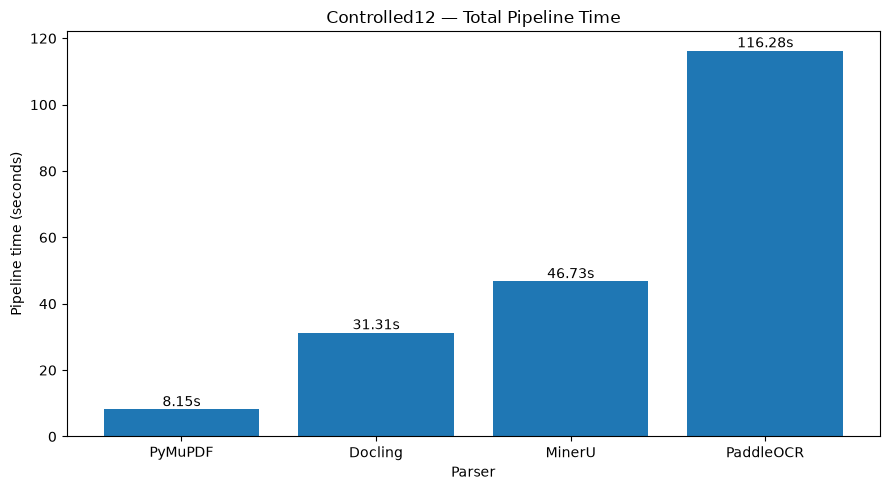

In [58]:
pipeline_plot = (
    df_performance[
        "pipeline_seconds"
    ]
    .sort_values()
)


fig, ax = plt.subplots(
    figsize=(9, 5)
)


bars = ax.bar(
    pipeline_plot.index,
    pipeline_plot.values,
)


ax.set_title(
    "Controlled12 — Total Pipeline Time"
)

ax.set_xlabel(
    "Parser"
)

ax.set_ylabel(
    "Pipeline time (seconds)"
)


for bar, value in zip(
    bars,
    pipeline_plot.values,
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}s",
        ha="center",
        va="bottom",
    )


plt.tight_layout()
plt.show()

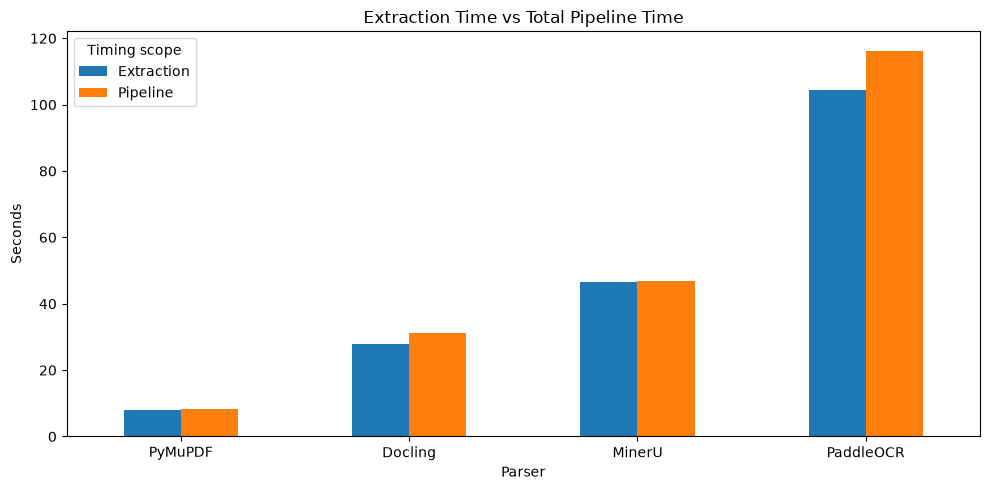

In [59]:
timing_comparison = (
    df_performance[
        [
            "extraction_seconds",
            "pipeline_seconds",
        ]
    ]
    .rename(
        columns={
            "extraction_seconds":
                "Extraction",
            "pipeline_seconds":
                "Pipeline",
        }
    )
)


ax = timing_comparison.plot(
    kind="bar",
    figsize=(10, 5),
)


ax.set_title(
    "Extraction Time vs Total Pipeline Time"
)

ax.set_xlabel(
    "Parser"
)

ax.set_ylabel(
    "Seconds"
)

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.legend(
    title="Timing scope"
)


plt.tight_layout()
plt.show()

In [60]:
performance_validation_failures = []


for parser, row in df_performance.iterrows():
    pages = row[
        "pages"
    ]

    extraction_seconds = row[
        "extraction_seconds"
    ]

    pipeline_seconds = row[
        "pipeline_seconds"
    ]

    stored_extraction_rate = row[
        "extraction_pages_per_second"
    ]

    stored_pipeline_rate = row[
        "pipeline_pages_per_second"
    ]


    if extraction_seconds <= 0:
        performance_validation_failures.append(
            {
                "parser": parser,
                "issue":
                    "extraction_seconds is not positive",
            }
        )


    if pipeline_seconds <= 0:
        performance_validation_failures.append(
            {
                "parser": parser,
                "issue":
                    "pipeline_seconds is not positive",
            }
        )


    if pipeline_seconds < extraction_seconds:
        performance_validation_failures.append(
            {
                "parser": parser,
                "issue":
                    "pipeline_seconds is smaller "
                    "than extraction_seconds",
            }
        )


    calculated_extraction_rate = (
        pages / extraction_seconds
    )

    calculated_pipeline_rate = (
        pages / pipeline_seconds
    )


    if abs(
        calculated_extraction_rate
        - stored_extraction_rate
    ) > 0.001:
        performance_validation_failures.append(
            {
                "parser": parser,
                "issue":
                    "extraction throughput mismatch",
                "calculated":
                    calculated_extraction_rate,
                "stored":
                    stored_extraction_rate,
            }
        )


    if abs(
        calculated_pipeline_rate
        - stored_pipeline_rate
    ) > 0.001:
        performance_validation_failures.append(
            {
                "parser": parser,
                "issue":
                    "pipeline throughput mismatch",
                "calculated":
                    calculated_pipeline_rate,
                "stored":
                    stored_pipeline_rate,
            }
        )


if performance_validation_failures:
    raise AssertionError(
        "PERFORMANCE METRICS VALIDATION FAILED:\n"
        + json.dumps(
            performance_validation_failures,
            indent=2,
            ensure_ascii=False,
        )
    )


print(
    "PERFORMANCE METRICS VALIDATION: PASS"
)

print(
    "Stored timing and throughput metrics "
    "are internally consistent."
)

PERFORMANCE METRICS VALIDATION: PASS
Stored timing and throughput metrics are internally consistent.


### Performance findings

The Controlled12 benchmark shows large execution-time differences between the
four parsers, even though all of them processed the same 12-page source
document and passed the processing-integrity gate.

#### Total pipeline time

The measured total pipeline times were:

| Parser | Pipeline time | Time/page | Relative to fastest |
|---|---:|---:|---:|
| PyMuPDF | 8.147 s | 0.679 s | 1.00× |
| Docling | 31.312 s | 2.609 s | 3.84× |
| MinerU | 46.730 s | 3.894 s | 5.74× |
| PaddleOCR | 116.281 s | 9.690 s | 14.27× |

For this Controlled12 execution, **PyMuPDF was the fastest parser**.

Relative to PyMuPDF:

- Docling required approximately **3.84×** the total pipeline time;
- MinerU required approximately **5.74×** the total pipeline time;
- PaddleOCR required approximately **14.27×** the total pipeline time.

The difference between the fastest and slowest executions is therefore
substantial.

This result describes operational runtime only and must not be interpreted as
an extraction-quality ranking.

#### Extraction time

The extraction phase accounted for most of the measured runtime:

| Parser | Extraction time | Pipeline time |
|---|---:|---:|
| PyMuPDF | 7.937 s | 8.147 s |
| Docling | 27.794 s | 31.312 s |
| MinerU | 46.549 s | 46.730 s |
| PaddleOCR | 104.358 s | 116.281 s |

The parser extraction workloads therefore differ substantially before the
shared Common Core processing is considered.

PyMuPDF completed extraction in less than 8 seconds, while PaddleOCR required
more than 104 seconds for the same 12-page document.

#### Throughput

Pipeline throughput follows the inverse runtime pattern:

| Parser | Pipeline throughput |
|---|---:|
| PyMuPDF | 1.473 pages/s |
| Docling | 0.383 pages/s |
| MinerU | 0.257 pages/s |
| PaddleOCR | 0.103 pages/s |

PyMuPDF processed approximately 1.47 pages per second, whereas PaddleOCR
processed approximately 0.10 pages per second in this benchmark environment.

#### Initialization

Initialization behavior also differs across parsers.

- PyMuPDF reported approximately 0.001 s of initialization.
- Docling reported 3.268 s.
- PaddleOCR reported 11.733 s.
- MinerU does not expose a comparable initialization value in the frozen
  metrics and is therefore reported as **N/A**.

The missing MinerU value must not be interpreted as zero initialization cost.

#### Shared Common Core cost

The shared benchmark operations include:

- normalization;
- common metric calculation;
- artifact writing.

Their combined measured cost was:

| Parser | Common Core time | Share of pipeline |
|---|---:|---:|
| PyMuPDF | 0.208 s | 2.553% |
| Docling | 0.171 s | 0.547% |
| MinerU | 0.177 s | 0.379% |
| PaddleOCR | 0.186 s | 0.160% |

The absolute Common Core cost remained very similar across all four runs,
approximately **0.17–0.21 seconds**.

This is an important comparability result.

The large runtime differences observed between the parsers are not explained
by the shared normalization, metric-calculation or artifact-writing layer.
The Common Core represents only a small fraction of total pipeline time,
particularly for the heavier parsers.

#### Performance ordering

For this Controlled12 workload, the operational runtime ordering from fastest
to slowest is:

1. **PyMuPDF — 8.147 s**
2. **Docling — 31.312 s**
3. **MinerU — 46.730 s**
4. **PaddleOCR — 116.281 s**

This ordering describes **execution speed only**.

It is not a parser-quality ranking.

The parsers perform different OCR and document-understanding workloads, so
runtime must be interpreted together with their OCR strategy, token footprint,
CPU consumption and memory consumption.

The next section therefore examines the computational resources required to
produce these results.

### Performance findings

The Controlled12 benchmark shows large execution-time differences between the
four parsers, even though all of them processed the same 12-page source
document and passed the processing-integrity gate.

#### Total pipeline time

The measured total pipeline times were:

| Parser | Pipeline time | Time/page | Relative to fastest |
|---|---:|---:|---:|
| PyMuPDF | 8.147 s | 0.679 s | 1.00× |
| Docling | 31.312 s | 2.609 s | 3.84× |
| MinerU | 46.730 s | 3.894 s | 5.74× |
| PaddleOCR | 116.281 s | 9.690 s | 14.27× |

For this Controlled12 execution, **PyMuPDF was the fastest parser**.

Relative to PyMuPDF:

- Docling required approximately **3.84×** the total pipeline time;
- MinerU required approximately **5.74×** the total pipeline time;
- PaddleOCR required approximately **14.27×** the total pipeline time.

The difference between the fastest and slowest executions is therefore
substantial.

This result describes operational runtime only and must not be interpreted as
an extraction-quality ranking.

#### Extraction time

The extraction phase accounted for most of the measured runtime:

| Parser | Extraction time | Pipeline time |
|---|---:|---:|
| PyMuPDF | 7.937 s | 8.147 s |
| Docling | 27.794 s | 31.312 s |
| MinerU | 46.549 s | 46.730 s |
| PaddleOCR | 104.358 s | 116.281 s |

The parser extraction workloads therefore differ substantially before the
shared Common Core processing is considered.

PyMuPDF completed extraction in less than 8 seconds, while PaddleOCR required
more than 104 seconds for the same 12-page document.

#### Throughput

Pipeline throughput follows the inverse runtime pattern:

| Parser | Pipeline throughput |
|---|---:|
| PyMuPDF | 1.473 pages/s |
| Docling | 0.383 pages/s |
| MinerU | 0.257 pages/s |
| PaddleOCR | 0.103 pages/s |

PyMuPDF processed approximately 1.47 pages per second, whereas PaddleOCR
processed approximately 0.10 pages per second in this benchmark environment.

#### Initialization

Initialization behavior also differs across parsers.

- PyMuPDF reported approximately 0.001 s of initialization.
- Docling reported 3.268 s.
- PaddleOCR reported 11.733 s.
- MinerU does not expose a comparable initialization value in the frozen
  metrics and is therefore reported as **N/A**.

The missing MinerU value must not be interpreted as zero initialization cost.

#### Shared Common Core cost

The shared benchmark operations include:

- normalization;
- common metric calculation;
- artifact writing.

Their combined measured cost was:

| Parser | Common Core time | Share of pipeline |
|---|---:|---:|
| PyMuPDF | 0.208 s | 2.553% |
| Docling | 0.171 s | 0.547% |
| MinerU | 0.177 s | 0.379% |
| PaddleOCR | 0.186 s | 0.160% |

The absolute Common Core cost remained very similar across all four runs,
approximately **0.17–0.21 seconds**.

This is an important comparability result.

The large runtime differences observed between the parsers are not explained
by the shared normalization, metric-calculation or artifact-writing layer.
The Common Core represents only a small fraction of total pipeline time,
particularly for the heavier parsers.

#### Performance ordering

For this Controlled12 workload, the operational runtime ordering from fastest
to slowest is:

1. **PyMuPDF — 8.147 s**
2. **Docling — 31.312 s**
3. **MinerU — 46.730 s**
4. **PaddleOCR — 116.281 s**

This ordering describes **execution speed only**.

It is not a parser-quality ranking.

The parsers perform different OCR and document-understanding workloads, so
runtime must be interpreted together with their OCR strategy, token footprint,
CPU consumption and memory consumption.

The next section therefore examines the computational resources required to
produce these results.

## 8. CPU, RAM and I/O

This section analyzes the computational resources required by each parser.

These metrics are particularly important for deployment because execution time
alone does not determine infrastructure cost.

Two parsers can complete a document in similar elapsed time while requiring
very different amounts of:

- CPU capacity;
- CPU work;
- memory;
- disk I/O.

The analysis therefore separates four resource dimensions.

### CPU utilization

The primary CPU metrics are:

- average system-capacity CPU utilization;
- peak system-capacity CPU utilization.

These values are normalized against the logical CPU capacity of the benchmark
machine.

They are preferred over raw process CPU percentages because process-tree CPU
usage can exceed 100% when several CPU cores are used concurrently.

### CPU work

`process_cpu_time_seconds` measures cumulative CPU time consumed by the monitored
process tree.

This is different from elapsed time.

For example, a parser can run for 10 wall-clock seconds while consuming many
CPU-seconds through parallel execution.

From this metric the notebook derives:

- CPU-seconds per document;
- CPU-seconds per page;
- CPU core-hours per document;
- effective average CPU cores used.

These derived metrics help characterize computational demand independently of
wall-clock speed.

### Memory

Memory is evaluated through:

- average RSS;
- peak RSS.

Peak RSS is particularly relevant for infrastructure sizing because a worker
must have enough memory to survive the highest observed demand.

Average RSS describes the sustained memory footprint during processing.

### Disk I/O

The benchmark records:

- disk read MB;
- disk write MB.

These values characterize process-tree I/O observed during the measured run.

They do not represent persistent model storage, model-download size or the
complete storage footprint required by a production deployment.

### Cost interpretation

The metrics in this section are **cost inputs**, not direct cloud prices.

Cloud providers generally charge for provisioned resources such as:

- vCPUs;
- RAM;
- VM/container runtime;
- persistent storage;
- network traffic.

Observed CPU and RAM consumption help determine what infrastructure must be
provisioned, but they are not themselves billing metrics.

Production cost will also depend on:

- VM/container size;
- concurrency;
- workload volume;
- autoscaling strategy;
- regional cloud pricing;
- required safety headroom.

For this reason, Notebook V1 first establishes the observed resource demand.
Monetary costing can later map these measurements to a concrete deployment
architecture.

In [62]:
resource_rows = []

for parser, metrics in metrics_by_parser.items():
    resources = require_path(
        metrics,
        "resources",
    )

    processing = require_path(
        metrics,
        "processing",
    )

    pages = require_path(
        processing,
        "pages_processed",
    )

    pipeline_seconds = require_path(
        processing,
        "pipeline_seconds",
    )

    logical_cpus = require_path(
        resources,
        "logical_cpus",
    )

    wall_time_seconds = require_path(
        resources,
        "wall_time_seconds",
    )

    process_cpu_time_seconds = require_path(
        resources,
        "process_cpu_time_seconds",
    )

    average_cpu_capacity_percent = require_path(
        resources,
        "average_cpu_system_capacity_percent",
    )

    peak_cpu_capacity_percent = require_path(
        resources,
        "peak_cpu_system_capacity_percent",
    )

    average_rss_mb = require_path(
        resources,
        "average_rss_mb",
    )

    peak_rss_mb = require_path(
        resources,
        "peak_rss_mb",
    )

    disk_read_mb = require_path(
        resources,
        "disk_read_mb",
    )

    disk_write_mb = require_path(
        resources,
        "disk_write_mb",
    )

    effective_average_cores = (
        process_cpu_time_seconds
        / wall_time_seconds
        if wall_time_seconds
        else None
    )

    average_cores_from_capacity = (
        logical_cpus
        * average_cpu_capacity_percent
        / 100.0
    )

    peak_cores_from_capacity = (
        logical_cpus
        * peak_cpu_capacity_percent
        / 100.0
    )

    cpu_seconds_per_page = (
        process_cpu_time_seconds / pages
        if pages
        else None
    )

    cpu_core_hours_per_document = (
        process_cpu_time_seconds
        / 3600.0
    )

    average_rss_gib = (
        average_rss_mb / 1024.0
    )

    peak_rss_gib = (
        peak_rss_mb / 1024.0
    )

    total_disk_io_mb = (
        disk_read_mb
        + disk_write_mb
    )

    disk_io_mb_per_page = (
        total_disk_io_mb / pages
        if pages
        else None
    )

    observed_ram_gib_seconds = (
        average_rss_gib
        * wall_time_seconds
    )

    resource_rows.append(
        {
            "parser": parser,

            "pages":
                pages,

            "pipeline_seconds":
                pipeline_seconds,

            "logical_cpus":
                logical_cpus,

            "wall_time_seconds":
                wall_time_seconds,

            "process_cpu_time_seconds":
                process_cpu_time_seconds,

            "average_cpu_capacity_percent":
                average_cpu_capacity_percent,

            "peak_cpu_capacity_percent":
                peak_cpu_capacity_percent,

            "effective_average_cores":
                effective_average_cores,

            "average_cores_from_capacity":
                average_cores_from_capacity,

            "peak_cores_from_capacity":
                peak_cores_from_capacity,

            "cpu_seconds_per_page":
                cpu_seconds_per_page,

            "cpu_core_hours_per_document":
                cpu_core_hours_per_document,

            "average_rss_mb":
                average_rss_mb,

            "peak_rss_mb":
                peak_rss_mb,

            "average_rss_gib":
                average_rss_gib,

            "peak_rss_gib":
                peak_rss_gib,

            "disk_read_mb":
                disk_read_mb,

            "disk_write_mb":
                disk_write_mb,

            "total_disk_io_mb":
                total_disk_io_mb,

            "disk_io_mb_per_page":
                disk_io_mb_per_page,

            "observed_ram_gib_seconds":
                observed_ram_gib_seconds,
        }
    )


df_resources = (
    pd.DataFrame(resource_rows)
    .set_index("parser")
)

In [63]:
df_resource_summary = (
    df_resources[
        [
            "pipeline_seconds",
            "average_cpu_capacity_percent",
            "peak_cpu_capacity_percent",
            "process_cpu_time_seconds",
            "cpu_seconds_per_page",
            "effective_average_cores",
            "average_rss_gib",
            "peak_rss_gib",
        ]
    ]
    .copy()
)


for column in df_resource_summary.columns:
    df_resource_summary[column] = (
        df_resource_summary[column]
        .round(3)
    )


df_resource_summary.columns = [
    "Pipeline (s)",
    "Avg CPU capacity %",
    "Peak CPU capacity %",
    "CPU time (s)",
    "CPU s/page",
    "Effective avg cores",
    "Avg RSS (GiB)",
    "Peak RSS (GiB)",
]


df_resource_summary

,Pipeline (s),Avg CPU capacity %,Peak CPU capacity %,CPU time (s),CPU s/page,Effective avg cores,Avg RSS (GiB),Peak RSS (GiB)
parser,,,,,,,,
PyMuPDF,8.147,84.52,98.45,120.41,10.034,14.780,0.441,0.712
Docling,31.312,36.19,81.57,224.39,18.699,7.166,1.832,2.929
MinerU,46.730,40.35,100.00,377.90,31.492,8.087,2.061,3.164
PaddleOCR,116.281,45.43,57.98,1038.51,86.542,8.931,4.443,6.059


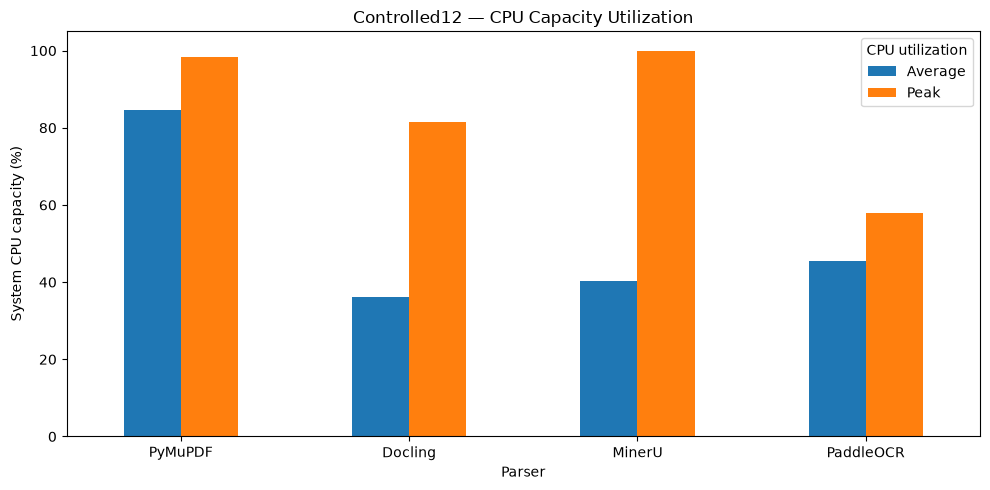

In [64]:
cpu_plot = (
    df_resources[
        [
            "average_cpu_capacity_percent",
            "peak_cpu_capacity_percent",
        ]
    ]
    .rename(
        columns={
            "average_cpu_capacity_percent":
                "Average",
            "peak_cpu_capacity_percent":
                "Peak",
        }
    )
)


ax = cpu_plot.plot(
    kind="bar",
    figsize=(10, 5),
)


ax.set_title(
    "Controlled12 — CPU Capacity Utilization"
)

ax.set_xlabel(
    "Parser"
)

ax.set_ylabel(
    "System CPU capacity (%)"
)

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.legend(
    title="CPU utilization"
)


plt.tight_layout()
plt.show()

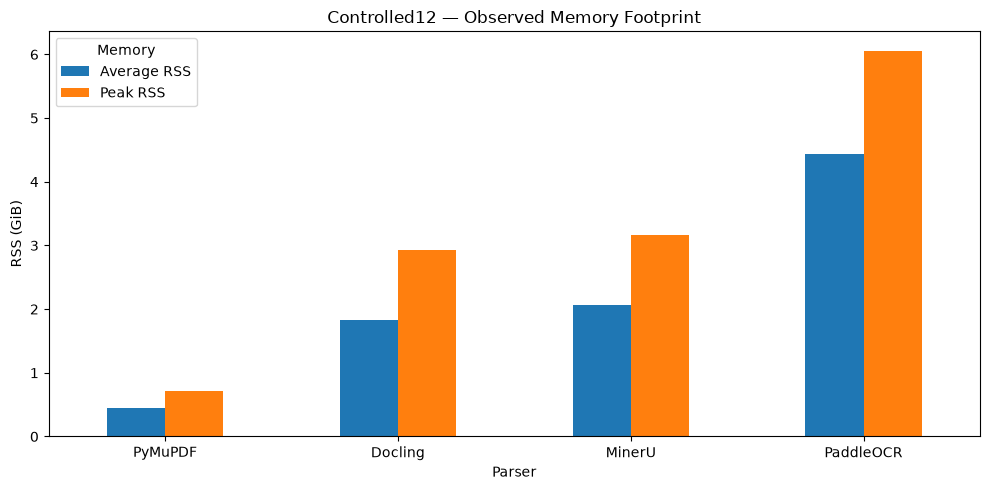

In [65]:
ram_plot = (
    df_resources[
        [
            "average_rss_gib",
            "peak_rss_gib",
        ]
    ]
    .rename(
        columns={
            "average_rss_gib":
                "Average RSS",
            "peak_rss_gib":
                "Peak RSS",
        }
    )
)


ax = ram_plot.plot(
    kind="bar",
    figsize=(10, 5),
)


ax.set_title(
    "Controlled12 — Observed Memory Footprint"
)

ax.set_xlabel(
    "Parser"
)

ax.set_ylabel(
    "RSS (GiB)"
)

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.legend(
    title="Memory"
)


plt.tight_layout()
plt.show()

In [66]:
df_io_summary = (
    df_resources[
        [
            "disk_read_mb",
            "disk_write_mb",
            "total_disk_io_mb",
            "disk_io_mb_per_page",
        ]
    ]
    .copy()
)


for column in df_io_summary.columns:
    df_io_summary[column] = (
        df_io_summary[column]
        .round(3)
    )


df_io_summary.columns = [
    "Disk read (MB)",
    "Disk write (MB)",
    "Total disk I/O (MB)",
    "Disk I/O MB/page",
]


df_io_summary

,Disk read (MB),Disk write (MB),Total disk I/O (MB),Disk I/O MB/page
parser,,,,
PyMuPDF,59.406,0.086,59.492,4.958
Docling,718.824,0.102,718.926,59.910
MinerU,4365.191,16.273,4381.464,365.122
PaddleOCR,2216.645,0.070,2216.715,184.726



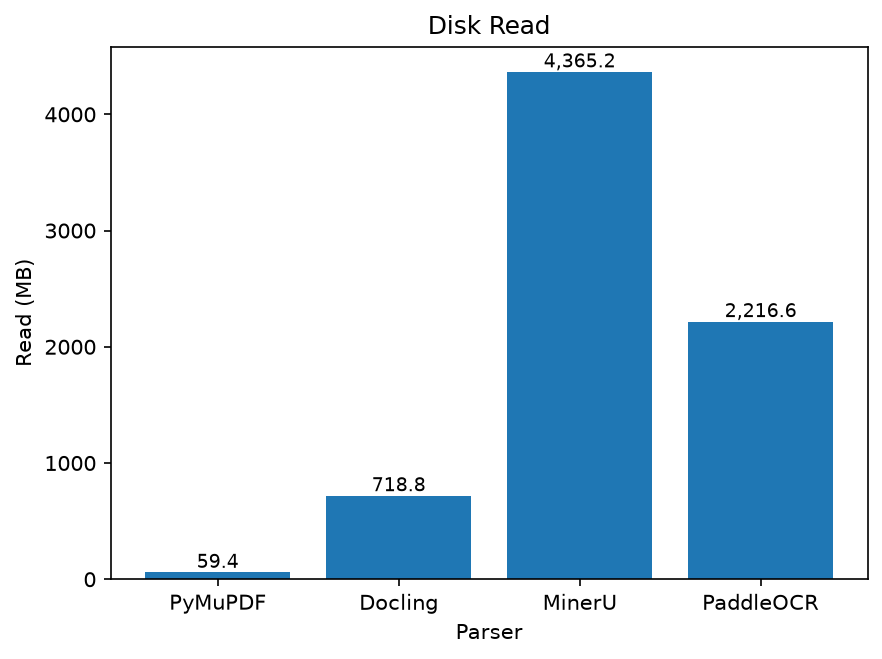
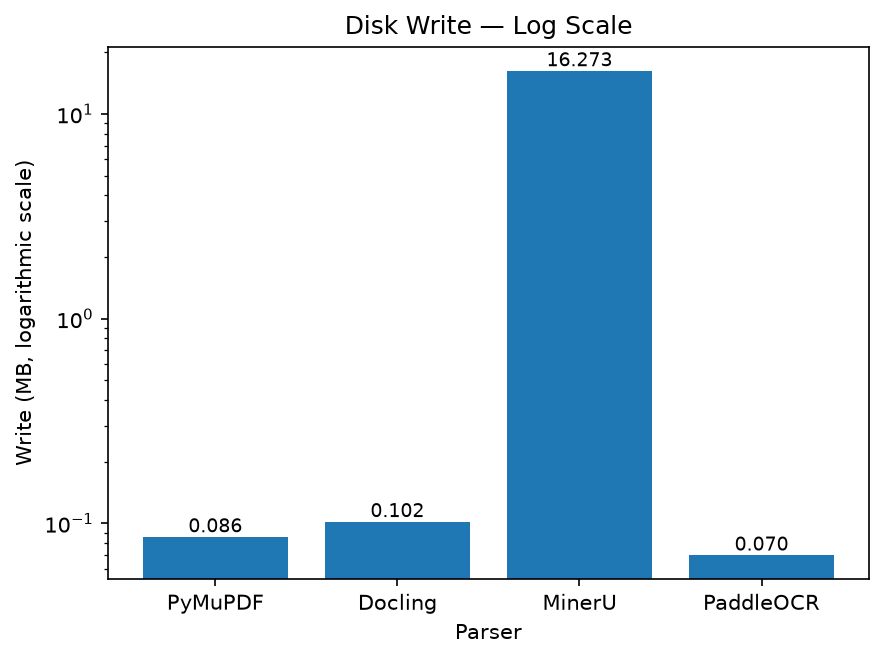

In [69]:
from io import BytesIO
import base64

from IPython.display import HTML, display


def figure_to_data_uri(fig):
    buffer = BytesIO()

    fig.savefig(
        buffer,
        format="png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.close(fig)

    buffer.seek(0)

    encoded = base64.b64encode(
        buffer.read()
    ).decode("ascii")

    return (
        "data:image/png;base64,"
        + encoded
    )


# ------------------------------------------------------------
# READ — separate figure, linear scale
# ------------------------------------------------------------

read_data = (
    df_resources[
        "disk_read_mb"
    ]
)


fig_read, ax_read = plt.subplots(
    figsize=(6, 4.5)
)


read_bars = ax_read.bar(
    read_data.index,
    read_data.values,
)


ax_read.set_title(
    "Disk Read"
)

ax_read.set_xlabel(
    "Parser"
)

ax_read.set_ylabel(
    "Read (MB)"
)

ax_read.tick_params(
    axis="x",
    rotation=0,
)


for bar, value in zip(
    read_bars,
    read_data.values,
):
    ax_read.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )


fig_read.tight_layout()


# ------------------------------------------------------------
# WRITE — separate figure, logarithmic scale
# ------------------------------------------------------------

write_data = (
    df_resources[
        "disk_write_mb"
    ]
)


fig_write, ax_write = plt.subplots(
    figsize=(6, 4.5)
)


write_bars = ax_write.bar(
    write_data.index,
    write_data.values,
)


ax_write.set_title(
    "Disk Write — Log Scale"
)

ax_write.set_xlabel(
    "Parser"
)

ax_write.set_ylabel(
    "Write (MB, logarithmic scale)"
)

ax_write.set_yscale(
    "log"
)

ax_write.tick_params(
    axis="x",
    rotation=0,
)


for bar, value in zip(
    write_bars,
    write_data.values,
):
    ax_write.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )


fig_write.tight_layout()


# ------------------------------------------------------------
# Display the two independent figures side by side
# ------------------------------------------------------------

read_uri = figure_to_data_uri(
    fig_read
)

write_uri = figure_to_data_uri(
    fig_write
)


display(
    HTML(
        f"""
        <div style="
            display:flex;
            gap:20px;
            align-items:flex-start;
            width:100%;
        ">
            <div style="flex:1;">
                <img
                    src="{read_uri}"
                    style="width:100%; height:auto;"
                >
            </div>

            <div style="flex:1;">
                <img
                    src="{write_uri}"
                    style="width:100%; height:auto;"
                >
            </div>
        </div>
        """
    )
)

In [72]:
lowest_cpu_time = (
    df_resources[
        "process_cpu_time_seconds"
    ]
    .min()
)

lowest_peak_ram = (
    df_resources[
        "peak_rss_gib"
    ]
    .min()
)


df_cost_inputs = (
    df_resources[
        [
            "pipeline_seconds",
            "process_cpu_time_seconds",
            "cpu_core_hours_per_document",
            "effective_average_cores",
            "average_rss_gib",
            "peak_rss_gib",
            "total_disk_io_mb",
        ]
    ]
    .copy()
)


df_cost_inputs[
    "cpu_work_relative_to_lowest"
] = (
    df_resources[
        "process_cpu_time_seconds"
    ]
    / lowest_cpu_time
)


df_cost_inputs[
    "peak_ram_relative_to_lowest"
] = (
    df_resources[
        "peak_rss_gib"
    ]
    / lowest_peak_ram
)


for column in df_cost_inputs.columns:
    df_cost_inputs[column] = (
        df_cost_inputs[column]
        .round(4)
    )


df_cost_inputs.columns = [
    "Pipeline (s)",
    "CPU work (core-s)",
    "CPU core-hours/document",
    "Effective avg cores",
    "Avg RSS (GiB)",
    "Peak RSS (GiB)",
    "Total disk I/O (MB)",
    "CPU work vs lowest",
    "Peak RAM vs lowest",
]


df_cost_inputs

,Pipeline (s),CPU work (core-s),CPU core-hours/document,Effective avg cores,Avg RSS (GiB),Peak RSS (GiB),Total disk I/O (MB),CPU work vs lowest,Peak RAM vs lowest
parser,,,,,,,,,
PyMuPDF,8.1474,120.41,0.0334,14.7797,0.4405,0.7119,59.492,1.0000,1.0000
Docling,31.3125,224.39,0.0623,7.1663,1.8324,2.9290,718.926,1.8635,4.1144
MinerU,46.7295,377.90,0.1050,8.0871,2.0607,3.1641,4381.464,3.1384,4.4447
PaddleOCR,116.2813,1038.51,0.2885,8.9310,4.4429,6.0588,2216.715,8.6248,8.5110


In [68]:
resource_validation_failures = []


for parser, row in df_resources.iterrows():
    logical_cpus = row[
        "logical_cpus"
    ]

    avg_cpu = row[
        "average_cpu_capacity_percent"
    ]

    peak_cpu = row[
        "peak_cpu_capacity_percent"
    ]

    cpu_time = row[
        "process_cpu_time_seconds"
    ]

    wall_time = row[
        "wall_time_seconds"
    ]

    effective_cores = row[
        "effective_average_cores"
    ]

    avg_ram = row[
        "average_rss_mb"
    ]

    peak_ram = row[
        "peak_rss_mb"
    ]

    disk_read = row[
        "disk_read_mb"
    ]

    disk_write = row[
        "disk_write_mb"
    ]


    if logical_cpus <= 0:
        resource_validation_failures.append(
            {
                "parser": parser,
                "issue":
                    "logical_cpus is not positive",
            }
        )


    if not (
        0 <= avg_cpu <= 100.5
    ):
        resource_validation_failures.append(
            {
                "parser": parser,
                "issue":
                    "average normalized CPU "
                    "outside expected range",
                "value":
                    avg_cpu,
            }
        )


    if not (
        0 <= peak_cpu <= 100.5
    ):
        resource_validation_failures.append(
            {
                "parser": parser,
                "issue":
                    "peak normalized CPU "
                    "outside expected range",
                "value":
                    peak_cpu,
            }
        )


    if avg_cpu > peak_cpu:
        resource_validation_failures.append(
            {
                "parser": parser,
                "issue":
                    "average CPU exceeds peak CPU",
            }
        )


    if cpu_time < 0:
        resource_validation_failures.append(
            {
                "parser": parser,
                "issue":
                    "negative CPU time",
            }
        )


    if wall_time <= 0:
        resource_validation_failures.append(
            {
                "parser": parser,
                "issue":
                    "non-positive monitor wall time",
            }
        )


    if (
        effective_cores
        > logical_cpus + 0.25
    ):
        resource_validation_failures.append(
            {
                "parser": parser,
                "issue":
                    "effective average cores "
                    "exceed logical CPU capacity",
                "effective_cores":
                    effective_cores,
                "logical_cpus":
                    logical_cpus,
            }
        )


    if avg_ram < 0:
        resource_validation_failures.append(
            {
                "parser": parser,
                "issue":
                    "negative average RSS",
            }
        )


    if peak_ram < avg_ram:
        resource_validation_failures.append(
            {
                "parser": parser,
                "issue":
                    "peak RSS smaller than "
                    "average RSS",
            }
        )


    if (
        disk_read < 0
        or disk_write < 0
    ):
        resource_validation_failures.append(
            {
                "parser": parser,
                "issue":
                    "negative disk I/O",
            }
        )


if resource_validation_failures:
    raise AssertionError(
        "RESOURCE METRICS VALIDATION FAILED:\n"
        + json.dumps(
            resource_validation_failures,
            indent=2,
            ensure_ascii=False,
        )
    )


print(
    "RESOURCE METRICS VALIDATION: PASS"
)

print(
    "CPU, RAM and disk I/O metrics "
    "are internally consistent."
)

RESOURCE METRICS VALIDATION: PASS
CPU, RAM and disk I/O metrics are internally consistent.


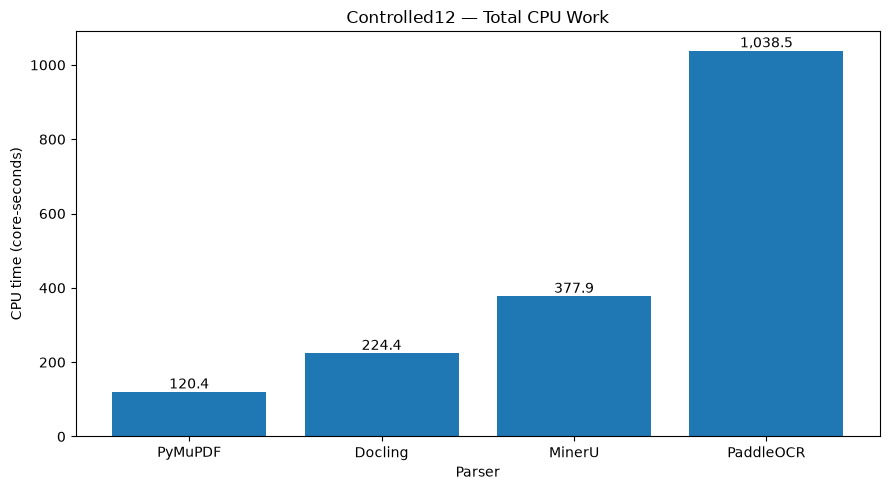

In [70]:
cpu_work = (
    df_resources[
        "process_cpu_time_seconds"
    ]
    .sort_values()
)


fig, ax = plt.subplots(
    figsize=(9, 5)
)


bars = ax.bar(
    cpu_work.index,
    cpu_work.values,
)


ax.set_title(
    "Controlled12 — Total CPU Work"
)

ax.set_xlabel(
    "Parser"
)

ax.set_ylabel(
    "CPU time (core-seconds)"
)


for bar, value in zip(
    bars,
    cpu_work.values,
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.1f}",
        ha="center",
        va="bottom",
    )


plt.tight_layout()
plt.show()

In [71]:
cpu_work_relative = (
    df_resources[
        "process_cpu_time_seconds"
    ]
    / df_resources[
        "process_cpu_time_seconds"
    ].min()
)


df_cpu_work_relative = (
    pd.DataFrame(
        {
            "CPU work (core-s)":
                df_resources[
                    "process_cpu_time_seconds"
                ],

            "CPU work vs lowest":
                cpu_work_relative,
        }
    )
)


df_cpu_work_relative[
    "CPU work (core-s)"
] = (
    df_cpu_work_relative[
        "CPU work (core-s)"
    ]
    .round(2)
)


df_cpu_work_relative[
    "CPU work vs lowest"
] = (
    df_cpu_work_relative[
        "CPU work vs lowest"
    ]
    .round(2)
)


df_cpu_work_relative

,CPU work (core-s),CPU work vs lowest
parser,,
PyMuPDF,120.41,1.00
Docling,224.39,1.86
MinerU,377.90,3.14
PaddleOCR,1038.51,8.62


### Resource, capacity and infrastructure-cost findings

The Controlled12 benchmark reveals substantial differences in computational
demand between the four parsers.

These differences are not captured by pipeline time alone.

For infrastructure planning, at least four dimensions must be considered
together:

1. elapsed execution time;
2. total CPU work;
3. memory footprint;
4. observed disk I/O.

The results therefore describe different **resource profiles**, rather than a
single generic performance ranking.

---

#### Executive resource comparison

| Parser | Pipeline | CPU work | CPU core-hours / document | Effective avg cores | Avg RSS | Peak RSS | Total disk I/O |
|---|---:|---:|---:|---:|---:|---:|---:|
| PyMuPDF | 8.147 s | 120.41 core-s | 0.0334 | 14.78 | 0.44 GiB | 0.71 GiB | 59.49 MB |
| Docling | 31.312 s | 224.39 core-s | 0.0623 | 7.17 | 1.83 GiB | 2.93 GiB | 718.93 MB |
| MinerU | 46.730 s | 377.90 core-s | 0.1050 | 8.09 | 2.06 GiB | 3.16 GiB | 4,381.46 MB |
| PaddleOCR | 116.281 s | 1,038.51 core-s | 0.2885 | 8.93 | 4.44 GiB | 6.06 GiB | 2,216.72 MB |

The four solutions therefore impose materially different infrastructure
requirements even though they processed the same 12-page source document.

---

### CPU utilization versus total CPU work

CPU utilization and CPU work answer different questions.

**CPU capacity utilization** describes how intensely a parser uses the
available machine while running.

**CPU time** describes how much cumulative CPU work was consumed by the
process tree.

This distinction is especially important for PyMuPDF.

#### PyMuPDF

PyMuPDF showed the highest average normalized CPU utilization:

- average CPU capacity: **84.52%**;
- peak CPU capacity: **98.45%**;
- effective average cores: **14.78**.

However, because the job completed in only **8.147 seconds**, total CPU work
was only **120.41 core-seconds**, the lowest value among the four parsers.

Its observed profile is therefore:

**high parallel CPU utilization + short duration + low total CPU work.**

This is operationally different from a parser that maintains moderate CPU
utilization for a much longer period.

PyMuPDF appears capable of exploiting substantial parallel CPU capacity to
reduce latency. A deployment with significantly fewer available CPU cores may
therefore exhibit different latency behavior from the benchmark machine.

---

#### Docling

Docling showed:

- average CPU capacity: **36.19%**;
- effective average cores: **7.17**;
- CPU work: **224.39 core-seconds**;
- pipeline time: **31.312 seconds**.

Compared with PyMuPDF, Docling consumed approximately:

- **1.86×** as much total CPU work;
- **3.84×** as much elapsed pipeline time.

Its CPU utilization is less aggressive, but the longer processing duration
results in greater cumulative CPU consumption.

---

#### MinerU

MinerU showed:

- average CPU capacity: **40.35%**;
- peak CPU capacity: **100%**;
- effective average cores: **8.09**;
- CPU work: **377.90 core-seconds**;
- pipeline time: **46.730 seconds**.

Its total CPU work was approximately **3.14×** the PyMuPDF baseline.

The observed profile combines substantial CPU work with a much larger disk-read
workload, making CPU alone insufficient to describe its infrastructure demand.

---

#### PaddleOCR

PaddleOCR showed the largest cumulative CPU workload:

- average CPU capacity: **45.43%**;
- effective average cores: **8.93**;
- CPU work: **1,038.51 core-seconds**;
- pipeline time: **116.281 seconds**.

Its total CPU work was approximately **8.62×** the PyMuPDF baseline.

This means the large elapsed-time difference is accompanied by a large increase
in actual CPU computation rather than being explained only by lower
parallelism.

For the Controlled12 workload, PaddleOCR is therefore the most
CPU-work-intensive of the four implementations.

---

### CPU work as a cost input

The measured CPU core-hours per document were:

| Parser | CPU core-hours / document |
|---|---:|
| PyMuPDF | 0.0334 |
| Docling | 0.0623 |
| MinerU | 0.1050 |
| PaddleOCR | 0.2885 |

If the same measured workload were repeated 1,000 times with identical
behavior, this would correspond approximately to:

| Parser | Observed CPU core-hours / 1,000 documents |
|---|---:|
| PyMuPDF | 33.4 |
| Docling | 62.3 |
| MinerU | 105.0 |
| PaddleOCR | 288.5 |

These are **computational-work projections**, not cloud invoices.

Cloud infrastructure is normally billed according to provisioned resources
and runtime, so idle or underutilized provisioned CPU capacity can still
generate cost.

Nevertheless, CPU core-hours per document provide a useful normalized measure
for comparing the amount of computational work required by each parser.

---

## Memory footprint

Memory shows an equally important separation between the parsers.

### Average RSS

| Parser | Average RSS |
|---|---:|
| PyMuPDF | 0.44 GiB |
| Docling | 1.83 GiB |
| MinerU | 2.06 GiB |
| PaddleOCR | 4.44 GiB |

Relative to PyMuPDF's average RSS:

- Docling used approximately **4.16×** as much;
- MinerU used approximately **4.68×** as much;
- PaddleOCR used approximately **10.09×** as much.

### Peak RSS

| Parser | Peak RSS | Relative to lowest |
|---|---:|---:|
| PyMuPDF | 0.71 GiB | 1.00× |
| Docling | 2.93 GiB | 4.11× |
| MinerU | 3.16 GiB | 4.44× |
| PaddleOCR | 6.06 GiB | 8.51× |

For worker sizing, **peak RSS is more important than average RSS** because the
worker must survive the maximum observed memory demand.

The benchmark therefore suggests markedly different minimum memory envelopes.

PyMuPDF had by far the smallest observed memory footprint.

Docling and MinerU occupied a middle range, both peaking around 3 GiB.

PaddleOCR showed the highest observed demand, reaching approximately 6.06 GiB
of RSS during the 12-page workload.

These numbers must not be used directly as VM memory recommendations.

A production deployment also needs memory for:

- the operating system;
- container runtime;
- Python/runtime overhead outside the monitored workload;
- concurrency;
- larger or more complex documents;
- transient allocations;
- safety headroom.

Peak benchmark RSS should therefore be treated as a **lower-bound sizing
signal**, not as the final provisioned RAM value.

---

## Disk I/O

The observed disk I/O differed by orders of magnitude.

| Parser | Read | Write | Total I/O | I/O per page |
|---|---:|---:|---:|---:|
| PyMuPDF | 59.41 MB | 0.086 MB | 59.49 MB | 4.96 MB/page |
| Docling | 718.82 MB | 0.102 MB | 718.93 MB | 59.91 MB/page |
| MinerU | 4,365.19 MB | 16.273 MB | 4,381.46 MB | 365.12 MB/page |
| PaddleOCR | 2,216.65 MB | 0.070 MB | 2,216.72 MB | 184.73 MB/page |

Relative to PyMuPDF's total observed disk I/O:

- Docling generated approximately **12.1×** as much;
- PaddleOCR approximately **37.3×** as much;
- MinerU approximately **73.6×** as much.

MinerU showed the largest observed I/O footprint by a large margin.

The workload was overwhelmingly read-oriented for all four parsers, although
MinerU also recorded noticeably more writes than the alternatives.

The resource monitor does not identify which individual files produced these
reads.

The I/O values therefore must **not** be interpreted directly as model size or
model-loading volume.

They indicate only that the monitored process tree performed this amount of
disk I/O during the measured execution.

This distinction is important because model cache size, Docker image size,
persistent storage and runtime disk traffic are separate infrastructure
considerations.

---

## Infrastructure implications by parser

### PyMuPDF — CPU-intensive burst, low resource footprint

Observed characteristics:

- fastest pipeline;
- highest average CPU-capacity utilization;
- highest effective average core usage;
- lowest cumulative CPU work;
- lowest average RAM;
- lowest peak RAM;
- lowest disk I/O.

This profile favors workloads where low latency is important and sufficient CPU
parallelism is available.

Its low memory and I/O requirements are also attractive for worker density.

However, because the benchmark shows strong CPU parallelism, performance on a
smaller-vCPU machine should not be assumed to remain at the observed
8.147-second latency.

---

### Docling — moderate compute and memory profile

Observed characteristics:

- substantially slower than PyMuPDF;
- lower instantaneous CPU pressure;
- approximately 1.86× PyMuPDF's CPU work;
- approximately 4.11× PyMuPDF's peak memory;
- approximately 12.1× PyMuPDF's observed disk I/O.

Docling occupies a middle operational tier.

Its resource profile is significantly heavier than PyMuPDF but materially
lighter than PaddleOCR in CPU work and memory.

---

### MinerU — I/O-heavy and compute-intensive

Observed characteristics:

- approximately 3.14× PyMuPDF's CPU work;
- approximately 4.44× PyMuPDF's peak RAM;
- approximately 73.6× PyMuPDF's disk I/O;
- the highest disk I/O of all four parsers.

The dominant operational characteristic is the very large observed read
volume.

This may become important when considering:

- worker cold starts;
- ephemeral containers;
- storage throughput;
- local model caches;
- concurrent workers sharing storage.

Additional instrumentation would be required to determine the exact source of
the observed reads before attributing them to models or other parser assets.

---

### PaddleOCR — highest overall resource demand

Observed characteristics:

- longest pipeline time;
- highest cumulative CPU work;
- highest average RAM;
- highest peak RAM;
- second-highest disk I/O.

Relative to PyMuPDF, PaddleOCR required approximately:

- **14.27×** the pipeline time;
- **8.62×** the CPU work;
- **8.51×** the peak RAM;
- **37.3×** the observed disk I/O.

For the Controlled12 workload, PaddleOCR therefore represents the largest
combined CPU-and-memory infrastructure requirement among the four parsers.

This does not imply poor efficiency without considering the work performed by
the pipeline.

Its benchmark profile includes a structured PPStructureV3 workflow with OCR,
table recognition, formula recognition, document orientation, text-line
orientation and region detection.

The additional computational cost must ultimately be evaluated against the
quality and structural information produced.

---

## Capacity-planning implications

The measurements suggest that infrastructure design should consider more than
one worker-size strategy.

A single VM specification may not be equally efficient for all parsers.

For example:

- PyMuPDF may benefit from a CPU-rich but relatively low-memory worker;
- Docling and MinerU require a larger memory envelope;
- PaddleOCR requires substantially more RAM and CPU work;
- MinerU may require particular attention to storage throughput.

Concurrency multiplies memory pressure.

If one worker reaches approximately 6 GiB RSS, four concurrent workers cannot
be assumed to fit safely inside a 24 GiB machine because the system still
requires room for runtime overhead and workload variability.

Similarly, effective average CPU usage cannot simply be multiplied by worker
count without considering CPU contention.

The current measurements therefore provide **capacity inputs**, but a final
deployment architecture requires explicit concurrency testing.

---

## What these results do not yet measure

The current resource benchmark does not yet establish:

- cloud VM price;
- container service price;
- storage price;
- network cost;
- cold-start frequency;
- model-cache persistence behavior;
- maximum safe concurrency;
- scaling with document page count;
- scaling with image/table complexity;
- long-running worker reuse;
- production queue utilization.

These should not be inferred from the Controlled12 resource measurements.

---

## Resource-cost conclusion

For the Controlled12 workload, the observed infrastructure demand from
lightest to heaviest cannot be represented by one universal ranking because
the parsers stress different resources.

However, several clear operational conclusions emerge:

- **PyMuPDF** has the smallest CPU-work, RAM and I/O footprint, while using the
  available CPU aggressively to achieve low latency.
- **Docling** occupies a moderate resource tier with higher CPU work, RAM and
  I/O than PyMuPDF.
- **MinerU** has a substantial CPU and memory footprint and by far the largest
  observed disk I/O.
- **PaddleOCR** has the highest cumulative CPU work and memory footprint and
  the longest execution time.

From a pure infrastructure-demand perspective, PyMuPDF currently has the
lightest observed resource profile for Controlled12.

This is **not yet a final parser recommendation**.

The higher resource cost of the other parsers may be justified if they preserve
more useful structure, recover more information, or produce better extraction
quality.

The next sections therefore become critical:

- **Section 9** evaluates the structure and noise of the generated Markdown;
- **Section 10** examines parser behavior at page level and identifies where
  the outputs actually diverge.

Only after resource demand is considered together with output behavior can the
benchmark support a defensible implementation decision.

## 9. Markdown structure and noise

This section evaluates the structure and surface-level textual characteristics
of the Markdown produced by each parser.

Unlike parser-native object counts, this analysis operates primarily on the
**common Markdown representation** produced by every benchmark job.

This distinction is important because parser-native concepts are not always
semantically equivalent across frameworks.

For example, an internal `table`, `picture`, `text block` or `section`
identified by one parser is not necessarily defined in the same way by another
parser.

The common Markdown analysis therefore focuses on what is ultimately available
to downstream consumers.

Two complementary dimensions are evaluated:

1. **Markdown structure**
   - headings;
   - lists;
   - tables;
   - images / image references;
   - code blocks;
   - other common structural indicators actually exposed by the benchmark.

2. **Textual noise**
   - whitespace;
   - empty lines and pages;
   - non-alphanumeric content;
   - replacement/control characters;
   - duplicated or repeated lines;
   - short lines;
   - line-ending hyphenation;
   - other common noise indicators actually exposed by the benchmark.

### Raw versus clean

Both dimensions are evaluated before and after the shared Common Core
normalization stage:

```text
Parser output
     ↓
Raw Markdown
     ↓
Common Core normalization
     ↓
Final Markdown
```

This allows the notebook to distinguish:

- structural differences introduced by the parser;
- changes introduced by normalization.

**Interpretation rules**

A larger structural count is **not automatically better.**

For example:

- more headings can indicate better hierarchy preservation or over-segmentation;
- more tables can indicate better table preservation or false table detection;
- more lists can represent preserved list structure or excessive fragmentation.

Likewise, a lower noise metric is not by itself proof of higher extraction
quality.

These metrics are diagnostic signals.

Final quality requires page-level inspection and, eventually, an external
ground-truth reference.

In [73]:
### Inspect the exact common structure/noise schema

def describe_metric_object(
    value,
    prefix="",
):
    """
    Return leaf metric paths and their stored value types.

    Inspection only.
    """
    rows = []

    if isinstance(value, dict):
        for key, child in value.items():
            path = (
                f"{prefix}.{key}"
                if prefix
                else key
            )

            rows.extend(
                describe_metric_object(
                    child,
                    path,
                )
            )

    else:
        rows.append(
            {
                "metric": prefix,
                "type": type(value).__name__,
                "value": value,
            }
        )

    return rows


schema_sections = {
    "Markdown structure — RAW":
        (
            "content_elements",
            "raw_markdown",
        ),

    "Markdown structure — CLEAN":
        (
            "content_elements",
            "clean_markdown",
        ),

    "Noise — RAW":
        (
            "heuristics",
            "raw",
        ),

    "Noise — CLEAN":
        (
            "heuristics",
            "cleaned",
        ),
}


for section_name, metric_path in schema_sections.items():
    print()
    print("=" * 88)
    print(section_name)
    print("=" * 88)

    paths_by_parser = {}

    for parser, metrics in metrics_by_parser.items():
        metric_object = require_path(
            metrics,
            *metric_path,
        )

        rows = describe_metric_object(
            metric_object
        )

        paths_by_parser[parser] = {
            row["metric"]
            for row in rows
        }

    common_paths = set.intersection(
        *paths_by_parser.values()
    )

    all_paths = set.union(
        *paths_by_parser.values()
    )

    print(
        f"Common leaf metrics: "
        f"{len(common_paths)}"
    )

    print(
        f"All observed leaf metrics: "
        f"{len(all_paths)}"
    )

    print()
    print("COMMON METRICS")
    print("-" * 88)

    for path in sorted(
        common_paths
    ):
        print(path)

    differences = {
        parser:
            sorted(
                all_paths
                - parser_paths
            )
        for parser, parser_paths
        in paths_by_parser.items()
        if (
            all_paths
            - parser_paths
        )
    }

    if differences:
        print()
        print(
            "FIELDS NOT EXPOSED "
            "BY EVERY PARSER"
        )
        print("-" * 88)

        for parser, missing_paths in differences.items():
            print(
                f"{parser}: "
                f"{missing_paths}"
            )

    else:
        print()
        print(
            "Schema agreement: "
            "all four parsers expose "
            "the same leaf metrics."
        )


print()
print("=" * 88)
print("VALUES — COMMON METRICS")
print("=" * 88)


for section_name, metric_path in schema_sections.items():
    print()
    print(section_name)
    print("-" * 88)

    flattened = {}

    for parser, metrics in metrics_by_parser.items():
        metric_object = require_path(
            metrics,
            *metric_path,
        )

        rows = describe_metric_object(
            metric_object
        )

        flattened[parser] = {
            row["metric"]:
                row["value"]
            for row in rows
        }

    common_paths = set.intersection(
        *[
            set(values)
            for values
            in flattened.values()
        ]
    )

    comparison_rows = []

    for path in sorted(
        common_paths
    ):
        row = {
            "metric": path,
        }

        for parser in metrics_by_parser:
            row[parser] = (
                flattened[
                    parser
                ][
                    path
                ]
            )

        comparison_rows.append(
            row
        )

    display(
        pd.DataFrame(
            comparison_rows
        )
        .set_index(
            "metric"
        )
    )


Markdown structure — RAW
Common leaf metrics: 6
All observed leaf metrics: 6

COMMON METRICS
----------------------------------------------------------------------------------------
code_blocks
headings
image_placeholders
image_references
list_items
tables

Schema agreement: all four parsers expose the same leaf metrics.

Markdown structure — CLEAN
Common leaf metrics: 6
All observed leaf metrics: 6

COMMON METRICS
----------------------------------------------------------------------------------------
code_blocks
headings
image_placeholders
image_references
list_items
tables

Schema agreement: all four parsers expose the same leaf metrics.

Noise — RAW
Common leaf metrics: 15
All observed leaf metrics: 15

COMMON METRICS
----------------------------------------------------------------------------------------
control_character_ratio
duplicate_line_ratio
empty_lines
empty_pages
line_end_hyphenation_count
non_alphanumeric_ratio
non_empty_lines
repeated_line_ratio
repeated_unique_lines
r

,PyMuPDF,Docling,MinerU,PaddleOCR
metric,,,,
code_blocks,0,1,1,0
headings,9,13,0,7
image_placeholders,0,4,0,0
image_references,0,0,0,0
list_items,18,19,16,12
tables,8,8,0,0



Markdown structure — CLEAN
----------------------------------------------------------------------------------------


,PyMuPDF,Docling,MinerU,PaddleOCR
metric,,,,
code_blocks,0,1,1,0
headings,9,13,0,7
image_placeholders,0,4,0,0
image_references,0,0,0,0
list_items,18,19,16,12
tables,8,8,0,0



Noise — RAW
----------------------------------------------------------------------------------------


,PyMuPDF,Docling,MinerU,PaddleOCR
metric,,,,
control_character_ratio,0.000000,0.000000,0.000000,0.000000
duplicate_line_ratio,0.104478,0.074074,0.250000,0.030303
empty_lines,103.000000,49.000000,96.000000,102.000000
empty_pages,0.000000,1.000000,0.000000,0.000000
line_end_hyphenation_count,0.000000,0.000000,0.000000,0.000000
non_alphanumeric_ratio,0.152764,0.112972,0.141907,0.161239
non_empty_lines,134.000000,108.000000,116.000000,66.000000
repeated_line_ratio,0.082090,0.000000,0.189655,0.000000
repeated_unique_lines,1.000000,0.000000,2.000000,0.000000



Noise — CLEAN
----------------------------------------------------------------------------------------


,PyMuPDF,Docling,MinerU,PaddleOCR
metric,,,,
control_character_ratio,0.000000,0.000000,0.000000,0.000000
duplicate_line_ratio,0.032520,0.074074,0.109756,0.030303
empty_lines,92.000000,49.000000,62.000000,99.000000
empty_pages,0.000000,1.000000,1.000000,0.000000
line_end_hyphenation_count,0.000000,0.000000,0.000000,0.000000
non_alphanumeric_ratio,0.156217,0.112972,0.146500,0.161272
non_empty_lines,123.000000,108.000000,82.000000,66.000000
repeated_line_ratio,0.000000,0.000000,0.000000,0.000000
repeated_unique_lines,0.000000,0.000000,0.000000,0.000000


In [74]:
STRUCTURE_KEYS = [
    "code_blocks",
    "headings",
    "image_placeholders",
    "image_references",
    "list_items",
    "tables",
]


NOISE_KEYS = [
    "control_character_ratio",
    "duplicate_line_ratio",
    "empty_lines",
    "empty_pages",
    "line_end_hyphenation_count",
    "non_alphanumeric_ratio",
    "non_empty_lines",
    "repeated_line_ratio",
    "repeated_unique_lines",
    "replacement_character_ratio",
    "short_line_character_threshold",
    "short_line_ratio",
    "total_characters",
    "total_lines",
    "whitespace_ratio",
]


def collect_common_metrics(
    *path,
    keys,
):
    rows = {}

    for parser, metrics in metrics_by_parser.items():
        metric_object = require_path(
            metrics,
            *path,
        )

        rows[parser] = {
            key: require_path(
                metric_object,
                key,
            )
            for key in keys
        }

    return pd.DataFrame.from_dict(
        rows,
        orient="index",
    )


df_structure_raw = collect_common_metrics(
    "content_elements",
    "raw_markdown",
    keys=STRUCTURE_KEYS,
)


df_structure_clean = collect_common_metrics(
    "content_elements",
    "clean_markdown",
    keys=STRUCTURE_KEYS,
)


df_noise_raw = collect_common_metrics(
    "heuristics",
    "raw",
    keys=NOISE_KEYS,
)


df_noise_clean = collect_common_metrics(
    "heuristics",
    "cleaned",
    keys=NOISE_KEYS,
)

In [75]:
df_structure_summary = (
    df_structure_clean[
        [
            "headings",
            "list_items",
            "tables",
            "image_placeholders",
            "image_references",
            "code_blocks",
        ]
    ]
    .copy()
)


df_structure_summary.columns = [
    "Headings",
    "List items",
    "Markdown tables",
    "Image placeholders",
    "Image references",
    "Code blocks",
]


df_structure_summary

,Headings,List items,Markdown tables,Image placeholders,Image references,Code blocks
PyMuPDF,9,18,8,0,0,0
Docling,13,19,8,4,0,1
MinerU,0,16,0,0,0,1
PaddleOCR,7,12,0,0,0,0


In [77]:
df_structure_delta = (
    df_structure_clean
    - df_structure_raw
)


structure_changed = (
    df_structure_delta
    .ne(0)
    .any()
    .any()
)


if structure_changed:
    print(
        "COMMON MARKDOWN STRUCTURE "
        "CHANGED DURING NORMALIZATION"
    )

    display(
        df_structure_delta
    )

else:
    print(
        "COMMON MARKDOWN STRUCTURE DELTA: 0"
    )

    print(
        "All six structural counters remained "
        "unchanged after normalization."
    )

COMMON MARKDOWN STRUCTURE DELTA: 0
All six structural counters remained unchanged after normalization.


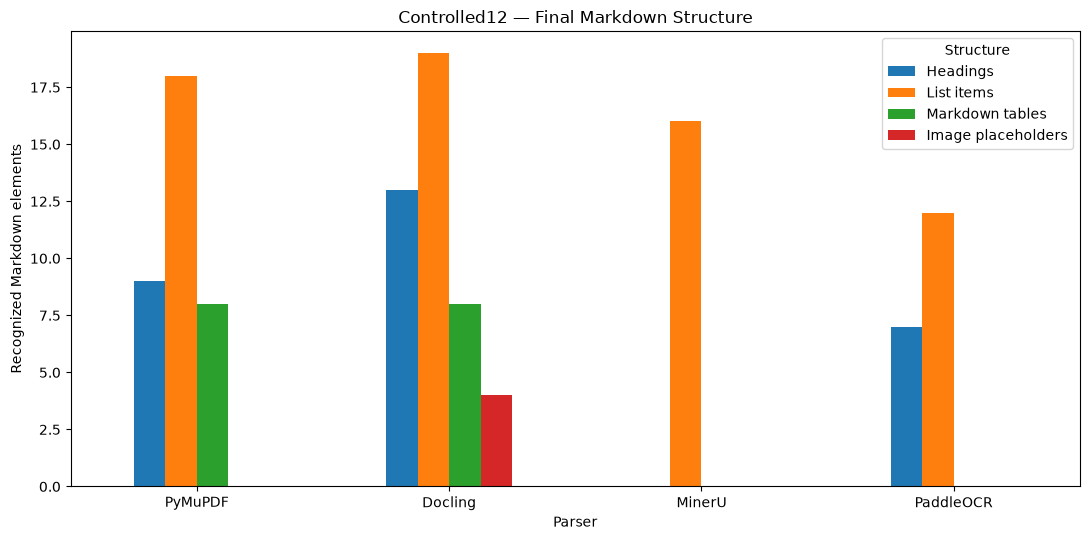

In [78]:
structure_plot = (
    df_structure_clean[
        [
            "headings",
            "list_items",
            "tables",
            "image_placeholders",
        ]
    ]
    .rename(
        columns={
            "headings":
                "Headings",
            "list_items":
                "List items",
            "tables":
                "Markdown tables",
            "image_placeholders":
                "Image placeholders",
        }
    )
)


ax = structure_plot.plot(
    kind="bar",
    figsize=(11, 5.5),
)


ax.set_title(
    "Controlled12 — Final Markdown Structure"
)

ax.set_xlabel(
    "Parser"
)

ax.set_ylabel(
    "Recognized Markdown elements"
)

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.legend(
    title="Structure"
)


plt.tight_layout()
plt.show()

In [79]:
df_noise_summary = pd.DataFrame(
    index=df_noise_clean.index
)


df_noise_summary[
    "Duplicate lines %"
] = (
    df_noise_clean[
        "duplicate_line_ratio"
    ]
    * 100
)


df_noise_summary[
    "Repeated lines %"
] = (
    df_noise_clean[
        "repeated_line_ratio"
    ]
    * 100
)


df_noise_summary[
    "Short lines %"
] = (
    df_noise_clean[
        "short_line_ratio"
    ]
    * 100
)


df_noise_summary[
    "Whitespace %"
] = (
    df_noise_clean[
        "whitespace_ratio"
    ]
    * 100
)


df_noise_summary[
    "Non-alphanumeric %"
] = (
    df_noise_clean[
        "non_alphanumeric_ratio"
    ]
    * 100
)


df_noise_summary[
    "Empty lines"
] = (
    df_noise_clean[
        "empty_lines"
    ]
)


df_noise_summary[
    "Empty pages"
] = (
    df_noise_clean[
        "empty_pages"
    ]
)


df_noise_summary[
    "Total characters"
] = (
    df_noise_clean[
        "total_characters"
    ]
)


df_noise_summary[
    "Total lines"
] = (
    df_noise_clean[
        "total_lines"
    ]
)


percentage_columns = [
    "Duplicate lines %",
    "Repeated lines %",
    "Short lines %",
    "Whitespace %",
    "Non-alphanumeric %",
]


df_noise_summary[
    percentage_columns
] = (
    df_noise_summary[
        percentage_columns
    ]
    .round(2)
)


df_noise_summary

,Duplicate lines %,Repeated lines %,Short lines %,Whitespace %,Non-alphanumeric %,Empty lines,Empty pages,Total characters,Total lines
PyMuPDF,3.25,0.0,5.69,13.38,15.62,92,0,13142,215
Docling,7.41,0.0,8.33,25.13,11.30,49,1,13552,157
MinerU,10.98,0.0,21.95,12.02,14.65,62,1,19215,144
PaddleOCR,3.03,0.0,3.03,10.81,16.13,99,0,14398,165


In [80]:
normalization_noise_rows = []


for parser in df_noise_raw.index:
    raw = df_noise_raw.loc[
        parser
    ]

    clean = df_noise_clean.loc[
        parser
    ]

    normalization_noise_rows.append(
        {
            "parser": parser,

            "Duplicate lines % "
            "(raw → final)":
                (
                    f"{raw['duplicate_line_ratio'] * 100:.2f}"
                    " → "
                    f"{clean['duplicate_line_ratio'] * 100:.2f}"
                ),

            "Repeated lines % "
            "(raw → final)":
                (
                    f"{raw['repeated_line_ratio'] * 100:.2f}"
                    " → "
                    f"{clean['repeated_line_ratio'] * 100:.2f}"
                ),

            "Short lines % "
            "(raw → final)":
                (
                    f"{raw['short_line_ratio'] * 100:.2f}"
                    " → "
                    f"{clean['short_line_ratio'] * 100:.2f}"
                ),

            "Characters removed":
                int(
                    raw["total_characters"]
                    - clean["total_characters"]
                ),

            "Lines removed":
                int(
                    raw["total_lines"]
                    - clean["total_lines"]
                ),

            "Empty lines removed":
                int(
                    raw["empty_lines"]
                    - clean["empty_lines"]
                ),

            "Empty pages Δ":
                int(
                    clean["empty_pages"]
                    - raw["empty_pages"]
                ),
        }
    )


df_noise_normalization = (
    pd.DataFrame(
        normalization_noise_rows
    )
    .set_index(
        "parser"
    )
)


df_noise_normalization

,Duplicate lines % (raw → final),Repeated lines % (raw → final),Short lines % (raw → final),Characters removed,Lines removed,Empty lines removed,Empty pages Δ
parser,,,,,,,
PyMuPDF,10.45 → 3.25,8.21 → 0.00,5.22 → 5.69,297,22,11,0
Docling,7.41 → 7.41,0.00 → 0.00,8.33 → 8.33,0,0,0,0
MinerU,25.00 → 10.98,18.97 → 0.00,25.86 → 21.95,622,68,34,1
PaddleOCR,3.03 → 3.03,0.00 → 0.00,3.03 → 3.03,3,3,3,0


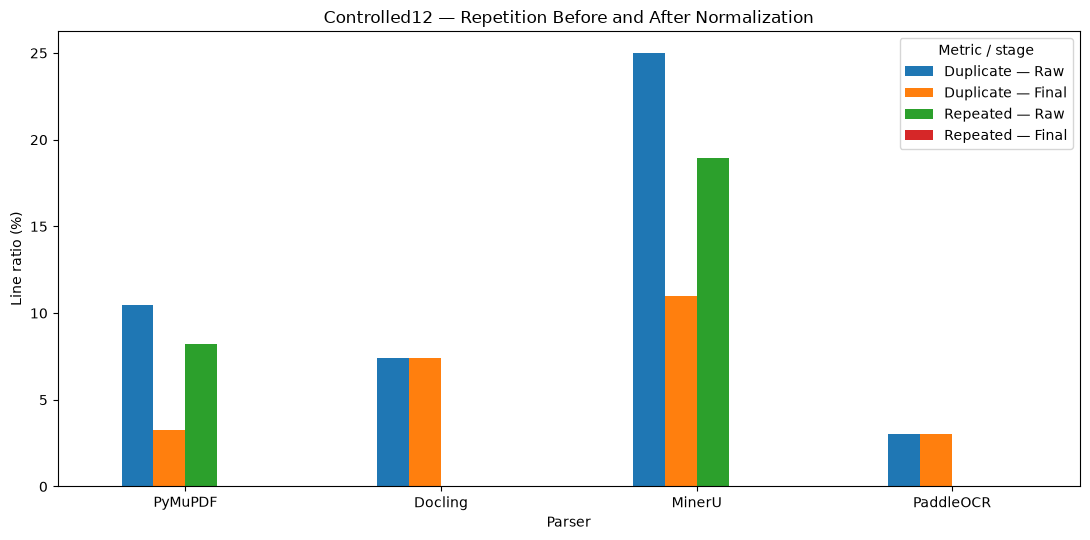

In [81]:
repetition_plot = pd.DataFrame(
    {
        "Duplicate — Raw":
            (
                df_noise_raw[
                    "duplicate_line_ratio"
                ]
                * 100
            ),

        "Duplicate — Final":
            (
                df_noise_clean[
                    "duplicate_line_ratio"
                ]
                * 100
            ),

        "Repeated — Raw":
            (
                df_noise_raw[
                    "repeated_line_ratio"
                ]
                * 100
            ),

        "Repeated — Final":
            (
                df_noise_clean[
                    "repeated_line_ratio"
                ]
                * 100
            ),
    }
)


ax = repetition_plot.plot(
    kind="bar",
    figsize=(11, 5.5),
)


ax.set_title(
    "Controlled12 — Repetition Before and After Normalization"
)

ax.set_xlabel(
    "Parser"
)

ax.set_ylabel(
    "Line ratio (%)"
)

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.legend(
    title="Metric / stage"
)


plt.tight_layout()
plt.show()

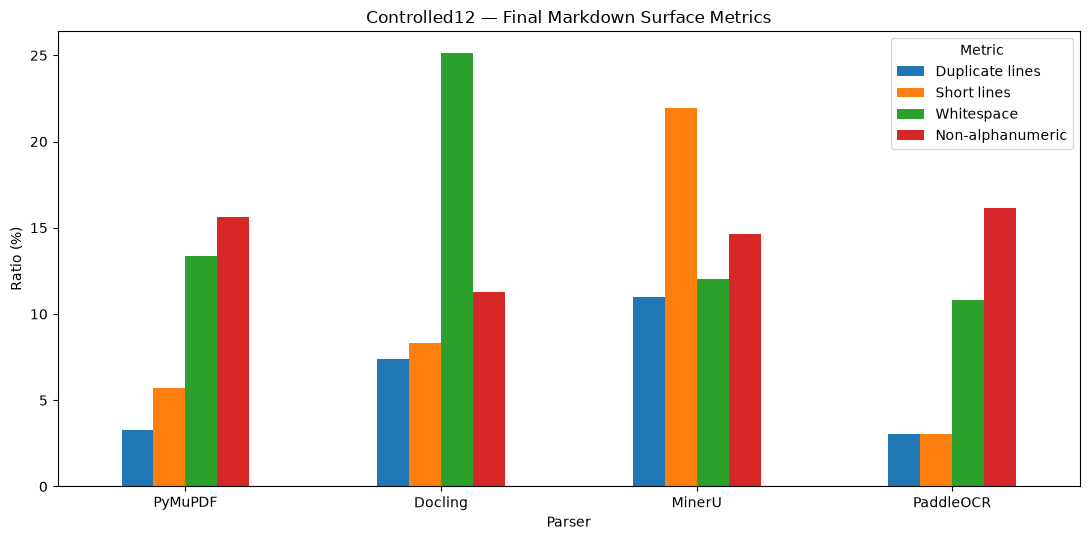

In [82]:
final_noise_plot = pd.DataFrame(
    {
        "Duplicate lines":
            (
                df_noise_clean[
                    "duplicate_line_ratio"
                ]
                * 100
            ),

        "Short lines":
            (
                df_noise_clean[
                    "short_line_ratio"
                ]
                * 100
            ),

        "Whitespace":
            (
                df_noise_clean[
                    "whitespace_ratio"
                ]
                * 100
            ),

        "Non-alphanumeric":
            (
                df_noise_clean[
                    "non_alphanumeric_ratio"
                ]
                * 100
            ),
    }
)


ax = final_noise_plot.plot(
    kind="bar",
    figsize=(11, 5.5),
)


ax.set_title(
    "Controlled12 — Final Markdown Surface Metrics"
)

ax.set_xlabel(
    "Parser"
)

ax.set_ylabel(
    "Ratio (%)"
)

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.legend(
    title="Metric"
)


plt.tight_layout()
plt.show()

In [83]:
structure_noise_failures = []


RATIO_KEYS = [
    "control_character_ratio",
    "duplicate_line_ratio",
    "non_alphanumeric_ratio",
    "repeated_line_ratio",
    "replacement_character_ratio",
    "short_line_ratio",
    "whitespace_ratio",
]


COUNT_KEYS = [
    "empty_lines",
    "empty_pages",
    "line_end_hyphenation_count",
    "non_empty_lines",
    "repeated_unique_lines",
    "total_characters",
    "total_lines",
]


observed_short_line_thresholds = set()


for parser in metrics_by_parser:
    # --------------------------------------------------------
    # Structure
    # --------------------------------------------------------

    for stage_name, frame in [
        (
            "raw",
            df_structure_raw,
        ),
        (
            "clean",
            df_structure_clean,
        ),
    ]:
        for metric in STRUCTURE_KEYS:
            value = frame.loc[
                parser,
                metric,
            ]

            if (
                pd.isna(value)
                or value < 0
            ):
                structure_noise_failures.append(
                    {
                        "parser": parser,
                        "stage": stage_name,
                        "metric": metric,
                        "issue":
                            "invalid structural count",
                        "value": value,
                    }
                )

    # --------------------------------------------------------
    # Noise
    # --------------------------------------------------------

    for stage_name, frame in [
        (
            "raw",
            df_noise_raw,
        ),
        (
            "clean",
            df_noise_clean,
        ),
    ]:
        row = frame.loc[
            parser
        ]

        for metric in RATIO_KEYS:
            value = row[
                metric
            ]

            if (
                pd.isna(value)
                or not (
                    0.0
                    <= value
                    <= 1.0
                )
            ):
                structure_noise_failures.append(
                    {
                        "parser": parser,
                        "stage": stage_name,
                        "metric": metric,
                        "issue":
                            "ratio outside [0, 1]",
                        "value": value,
                    }
                )

        for metric in COUNT_KEYS:
            value = row[
                metric
            ]

            if (
                pd.isna(value)
                or value < 0
            ):
                structure_noise_failures.append(
                    {
                        "parser": parser,
                        "stage": stage_name,
                        "metric": metric,
                        "issue":
                            "negative or missing count",
                        "value": value,
                    }
                )

        expected_total_lines = (
            row["empty_lines"]
            + row["non_empty_lines"]
        )

        if (
            row["total_lines"]
            != expected_total_lines
        ):
            structure_noise_failures.append(
                {
                    "parser": parser,
                    "stage": stage_name,
                    "issue":
                        "total_lines does not equal "
                        "empty_lines + non_empty_lines",
                    "stored":
                        row["total_lines"],
                    "calculated":
                        expected_total_lines,
                }
            )

        pages_processed = require_path(
            metrics_by_parser[
                parser
            ],
            "processing",
            "pages_processed",
        )

        if (
            row["empty_pages"]
            > pages_processed
        ):
            structure_noise_failures.append(
                {
                    "parser": parser,
                    "stage": stage_name,
                    "issue":
                        "empty_pages exceeds "
                        "pages_processed",
                }
            )

        observed_short_line_thresholds.add(
            row[
                "short_line_character_threshold"
            ]
        )


if len(
    observed_short_line_thresholds
) != 1:
    structure_noise_failures.append(
        {
            "issue":
                "short-line threshold differs "
                "between benchmark results",
            "values":
                sorted(
                    observed_short_line_thresholds
                ),
        }
    )


if structure_noise_failures:
    raise AssertionError(
        "STRUCTURE / NOISE VALIDATION FAILED:\n"
        + json.dumps(
            structure_noise_failures,
            indent=2,
            ensure_ascii=False,
        )
    )


print(
    "STRUCTURE / NOISE VALIDATION: PASS"
)

print(
    "Common Markdown structure and noise "
    "metrics are internally consistent."
)

STRUCTURE / NOISE VALIDATION: PASS
Common Markdown structure and noise metrics are internally consistent.


### Markdown structure and noise findings

The common Markdown representation exposes the same structural and noise
metric schema for all four parsers.

This is an important comparability result: the analysis below does not depend
on parser-specific object definitions.

---

## Common Markdown structure

The final Markdown structure was:

| Parser | Headings | List items | Markdown tables | Image placeholders | Image references | Code blocks |
|---|---:|---:|---:|---:|---:|---:|
| PyMuPDF | 9 | 18 | 8 | 0 | 0 | 0 |
| Docling | 13 | 19 | 8 | 4 | 0 | 1 |
| MinerU | 0 | 16 | 0 | 0 | 0 | 1 |
| PaddleOCR | 7 | 12 | 0 | 0 | 0 | 0 |

The structural counts are identical in raw and final Markdown for all four
parsers.

Therefore, the shared normalization stage did not change any of the six
common structural counters for Controlled12.

This does not prove that every structural element is semantically correct.
It only shows that normalization did not alter the structures recognized by
the common Markdown analyzer.

---

### Headings

Heading representation differs substantially.

- **Docling:** 13 recognized Markdown headings.
- **PyMuPDF:** 9.
- **PaddleOCR:** 7.
- **MinerU:** 0.

The MinerU result does not mean that the parser necessarily failed to detect
document sections internally.

It means that **no headings were recognized in its final common Markdown
representation** by the shared analyzer.

Likewise, the larger Docling count is not automatically evidence of better
hierarchy preservation.

More headings can represent either more faithful structure or
over-segmentation.

Page-level inspection is required to distinguish these cases.

---

### Lists

List-item counts were more closely grouped:

- Docling: 19;
- PyMuPDF: 18;
- MinerU: 16;
- PaddleOCR: 12.

Again, these are representation metrics rather than correctness scores.

The important observation is that all four outputs preserve at least some
Markdown list structure, but with different levels of segmentation.

---

### Markdown tables

The strongest structural difference is table serialization.

The common Markdown analyzer recognized:

- **8 tables in PyMuPDF;**
- **8 tables in Docling;**
- **0 tables in MinerU;**
- **0 tables in PaddleOCR.**

This result refers specifically to **recognizable table structure in the common
Markdown output**.

It must not be interpreted as proof that MinerU or PaddleOCR failed to detect
tables during parsing.

A parser can recognize a table internally but serialize its content into a form
that is not counted as a Markdown table by the common analyzer.

This distinction is critical for downstream use.

If the final artifact is intended for chunking, retrieval or direct LLM
consumption, preserving an internally detected table is not sufficient by
itself: the useful structure must also survive into the downstream
representation.

The table-heavy pages will therefore receive special attention in the
page-level analysis.

---

### Images and code blocks

Docling produced four image placeholders, while no parser produced common
Markdown image references.

The presence of placeholders should be treated as a representation
characteristic rather than evidence of visual-content quality.

Docling and MinerU each produced one recognized code block.

These isolated structural differences require page-level inspection before
being classified as useful structure or formatting artifacts.

---

## Final Markdown noise profile

After normalization, repeated-line noise was completely eliminated for all four
parsers.

However, other surface characteristics still differ substantially.

### Duplicate lines

Final duplicate-line ratios were:

| Parser | Duplicate lines |
|---|---:|
| PaddleOCR | 3.03% |
| PyMuPDF | 3.25% |
| Docling | 7.41% |
| MinerU | 10.98% |

MinerU retains the highest duplicate-line ratio after normalization.

Before normalization, however, MinerU was at **25.00%**, so the Common Core
removed a substantial amount of repetition.

PyMuPDF also dropped from **10.45% to 3.25%**.

Docling and PaddleOCR were effectively unchanged on this metric.

A duplicate-line ratio is a diagnostic signal, not automatically unwanted
content. Repeated legitimate table rows, labels or structural markers can also
contribute to duplication.

---

### Repeated lines

The normalization effect is particularly clear for repeated-line patterns.

PyMuPDF changed from:

**8.21% → 0%**

MinerU changed from:

**18.97% → 0%**

Docling and PaddleOCR were already at 0%.

This indicates that the shared normalizer successfully removed the repeated
cross-page line patterns it was designed to target in PyMuPDF and MinerU.

---

### Short lines

Final short-line ratios were:

| Parser | Short lines |
|---|---:|
| PaddleOCR | 3.03% |
| PyMuPDF | 5.69% |
| Docling | 8.33% |
| MinerU | 21.95% |

MinerU therefore has a substantially larger proportion of short lines in the
final representation.

This can indicate greater textual fragmentation, but the metric is not
sufficient to classify the output as worse.

Short lines can also be legitimate:

- headings;
- labels;
- table cells;
- list items;
- short paragraphs.

The page-level analysis will determine where these short lines originate.

---

### Whitespace

Final whitespace ratios were:

| Parser | Whitespace |
|---|---:|
| PaddleOCR | 10.81% |
| MinerU | 12.02% |
| PyMuPDF | 13.38% |
| Docling | 25.13% |

Docling has a markedly larger whitespace ratio than the other three outputs.

This should not immediately be classified as noise.

Markdown tables, layout choices and structural formatting can legitimately
increase whitespace consumption.

The result is therefore a useful representation characteristic rather than an
error metric.

---

### Non-alphanumeric content

Final non-alphanumeric ratios ranged from approximately 11% to 16%:

- Docling: 11.30%;
- MinerU: 14.65%;
- PyMuPDF: 15.62%;
- PaddleOCR: 16.13%.

These values include both potential extraction artifacts and legitimate
content such as punctuation, Markdown syntax, mathematical notation, table
delimiters and special characters.

For this reason, lower is not automatically better.

---

## Effect of Common Core normalization

Normalization had very different effects across the four parser outputs.

### PyMuPDF

The normalizer removed:

- 297 characters;
- 22 total lines;
- 11 empty lines.

Duplicate-line ratio decreased from **10.45% to 3.25%**, and repeated-line
ratio decreased from **8.21% to 0%**.

The common structural counters remained unchanged.

This indicates that a measurable amount of repetitive textual material was
removed without changing the recognized Markdown structure counts.

---

### Docling

The measured common noise metrics were unchanged by normalization.

Raw and final Markdown both contain:

- the same number of characters;
- the same number of lines;
- the same structural counts;
- the same noise ratios.

This is consistent with the earlier token analysis, where Docling also showed
no token reduction from the shared normalizer.

---

### MinerU

MinerU experienced the largest visible transformation.

The normalizer removed:

- 622 characters;
- 68 total lines;
- 34 empty lines.

Duplicate-line ratio decreased from:

**25.00% → 10.98%**

and repeated-line ratio decreased from:

**18.97% → 0%**.

Short-line ratio also decreased from:

**25.86% → 21.95%**.

However, the number of empty pages changed from:

**0 raw → 1 final**.

This is an important diagnostic finding.

The normalization step removed all remaining alphanumeric content from one
page, producing an empty final page according to the common empty-page
definition.

This is not automatically an error because the removed page may have contained
only repeated edge content.

The affected page must nevertheless be inspected in Section 10 to verify
exactly what was removed.

---

### PaddleOCR

PaddleOCR was almost unchanged by Common Core normalization.

Only:

- 3 characters;
- 3 lines;
- 3 empty lines

were removed.

Its token count remained unchanged, and its principal noise ratios also
remained effectively unchanged.

The raw PaddleOCR representation therefore contained very little of the
repeated cross-page material targeted by the normalizer.

---

## Encoding-safety signals

Three common metrics show no detected problems in any parser:

- control-character ratio: **0%**;
- replacement-character ratio: **0%**;
- line-ending hyphenation count: **0**.

These are useful negative findings.

No parser showed evidence, under these heuristics, of replacement-character
corruption, control-character contamination or line-ending hyphenation
artifacts in Controlled12.

---

## Structure and noise conclusion

The four parsers produce meaningfully different downstream Markdown
representations even when processing exactly the same source document.

Several distinctions are already clear:

**PyMuPDF** preserves substantial common Markdown structure, including eight
recognized tables, while the shared normalizer substantially reduces repeated
content.

**Docling** produces the largest number of recognized headings and list items,
preserves eight recognized Markdown tables and introduces four image
placeholders, but also has the highest whitespace ratio.

**MinerU** produces the largest textual output and the strongest raw repetition
signals. Common normalization removes a substantial amount of that repetition,
but the final Markdown still has the highest duplicate-line and short-line
ratios. No headings or Markdown tables are recognized by the common analyzer.

**PaddleOCR** produces relatively low repetition and short-line ratios and
requires almost no Common Core cleanup, but the common Markdown analyzer
recognizes no table structures despite the table-oriented nature of parts of
the source workload.

None of these observations constitutes a quality ranking.

They identify **where the representations differ**.

The next step is therefore the most important qualitative analysis in Notebook
V1:

**Section 10 will move from document-level aggregates to individual pages.**

There we can determine whether the structural differences observed here
correspond to:

- genuine extraction failures;
- different but valid serializations;
- OCR errors;
- table reconstruction differences;
- rotation handling;
- formula handling;
- header/footer behavior;
- or simple formatting choices.

That page-level evidence is required before the computational-cost results from
Section 8 can be weighed against the actual value delivered by each parser.

## 10. Per-page analysis

Document-level metrics are useful for measuring overall cost, output size and
surface characteristics, but they can hide localized extraction failures.

This section therefore moves from aggregate document metrics to the individual
12 pages of the Controlled12 workload.

The objective is to identify **where the parsers actually diverge** and then
inspect those pages in detail.

### Why page-level analysis matters

Two parsers can produce similar document-level token counts while behaving very
differently on individual pages.

Likewise, a parser can successfully process all 12 pages while still producing:

- an empty page;
- a malformed table;
- incorrect OCR;
- lost heading hierarchy;
- fragmented text;
- incorrect formula serialization;
- rotation-related errors.

For this reason, processing success is not equivalent to extraction quality.

### Controlled12 page groups

The document intentionally contains different types of content:

- introductory text and repeated page-edge content;
- normal tables;
- financial tables;
- difficult narrow tables;
- prose;
- formatting and special-character stress tests;
- mathematical/formula content;
- visual table content;
- physically rotated visual content.

The page-level analysis will compare how each parser represents these cases.

### Comparison strategy

The analysis is performed in three stages.

#### Stage 1 — objective divergence detection

Common measurements are calculated from every page output, such as:

- raw and final character counts;
- raw and final line counts;
- empty-page status;
- structural element counts when they are directly comparable;
- normalization impact.

These measurements help identify pages where parser outputs differ most.

#### Stage 2 — parser-specific diagnostics

Parser-native metadata is then used only to explain behavior, for example:

- OCR activity;
- detected tables;
- formulas;
- document orientation;
- parser-native object counts.

Parser-native metrics are diagnostic and are **not treated as ground truth**.

#### Stage 3 — qualitative inspection

The most divergent or intentionally difficult pages are inspected directly.

This is required to distinguish:

- genuine extraction failures;
- different but valid Markdown representations;
- OCR errors;
- table reconstruction differences;
- rotation handling differences;
- formula serialization differences;
- normalization effects.

### Interpretation rule

Page-level output differences are evidence of different parser behavior.

They become evidence of **better or worse quality only when the source page and
the extracted result can be compared directly**.

In [84]:
# ------------------------------------------------------------
# 1. Top-level document.jsonl schema
# ------------------------------------------------------------

record_keys_by_parser = {
    parser: set(
        page_records[0].keys()
    )
    for parser, page_records
    in pages_by_parser.items()
}


common_record_keys = set.intersection(
    *record_keys_by_parser.values()
)

all_record_keys = set.union(
    *record_keys_by_parser.values()
)


print("=" * 88)
print("DOCUMENT.JSONL — PAGE RECORD SCHEMA")
print("=" * 88)

print()
print("COMMON TOP-LEVEL FIELDS")
print("-" * 88)

for key in sorted(
    common_record_keys
):
    print(key)


print()
print("ALL OBSERVED TOP-LEVEL FIELDS")
print("-" * 88)

for key in sorted(
    all_record_keys
):
    print(key)


# ------------------------------------------------------------
# 2. parser_elements schema
# ------------------------------------------------------------

elements_keys_by_parser = {}


for parser, page_records in pages_by_parser.items():
    observed_keys = set()

    for record in page_records:
        elements = record.get(
            "parser_elements"
        )

        if isinstance(
            elements,
            dict,
        ):
            observed_keys.update(
                elements.keys()
            )

    elements_keys_by_parser[
        parser
    ] = observed_keys


common_element_keys = set.intersection(
    *elements_keys_by_parser.values()
)

all_element_keys = set.union(
    *elements_keys_by_parser.values()
)


print()
print("=" * 88)
print("PARSER_ELEMENTS SCHEMA")
print("=" * 88)

print()
print("COMMON PARSER_ELEMENTS FIELDS")
print("-" * 88)

for key in sorted(
    common_element_keys
):
    print(key)


print()
print("PARSER-SPECIFIC ELEMENT FIELDS")
print("-" * 88)

for parser, keys in elements_keys_by_parser.items():
    specific = sorted(
        keys
        - common_element_keys
    )

    print()
    print(parser)
    print(
        specific
        if specific
        else "None"
    )


# ------------------------------------------------------------
# 3. parser_native schema
# ------------------------------------------------------------

native_keys_by_parser = {}


for parser, page_records in pages_by_parser.items():
    observed_keys = set()

    for record in page_records:
        native = record.get(
            "parser_native"
        )

        if isinstance(
            native,
            dict,
        ):
            observed_keys.update(
                native.keys()
            )

    native_keys_by_parser[
        parser
    ] = observed_keys


print()
print("=" * 88)
print("PARSER_NATIVE — TOP-LEVEL FIELDS")
print("=" * 88)


for parser, keys in native_keys_by_parser.items():
    print()
    print(parser)
    print("-" * 88)

    for key in sorted(
        keys
    ):
        print(key)

DOCUMENT.JSONL — PAGE RECORD SCHEMA

COMMON TOP-LEVEL FIELDS
----------------------------------------------------------------------------------------
clean_markdown
document_id
page_number
parser
parser_elements
parser_native
profile
raw_markdown
source_file

ALL OBSERVED TOP-LEVEL FIELDS
----------------------------------------------------------------------------------------
clean_markdown
document_id
page_number
parser
parser_elements
parser_native
profile
raw_markdown
source_file

PARSER_ELEMENTS SCHEMA

COMMON PARSER_ELEMENTS FIELDS
----------------------------------------------------------------------------------------

PARSER-SPECIFIC ELEMENT FIELDS
----------------------------------------------------------------------------------------

PyMuPDF
['box_class_counts', 'captions_detected', 'footnotes_detected', 'formulas_detected', 'headings_detected', 'images_detected', 'layout_boxes', 'lists_detected', 'page_footers_detected', 'page_headers_detected', 'page_number', 'tables_detect

In [85]:
page_summary_rows = []


for parser, page_records in pages_by_parser.items():
    for record in page_records:
        raw_text = (
            record.get(
                "raw_markdown"
            )
            or ""
        )

        clean_text = (
            record.get(
                "clean_markdown"
            )
            or ""
        )

        page_summary_rows.append(
            {
                "parser":
                    parser,

                "page":
                    record[
                        "page_number"
                    ],

                "raw_characters":
                    len(
                        raw_text
                    ),

                "final_characters":
                    len(
                        clean_text
                    ),

                "characters_removed":
                    (
                        len(raw_text)
                        - len(clean_text)
                    ),

                "raw_lines":
                    len(
                        raw_text.splitlines()
                    ),

                "final_lines":
                    len(
                        clean_text.splitlines()
                    ),

                "final_empty":
                    markdown_is_empty(
                        clean_text
                    ),
            }
        )


df_pages = (
    pd.DataFrame(
        page_summary_rows
    )
    .set_index(
        [
            "page",
            "parser",
        ]
    )
    .sort_index()
)


df_pages

raw_characters  final_characters  characters_removed  \
page parser                                                            
1    Docling                84                84                   0   
     MinerU                138               135                   3   
     PaddleOCR              86                85                   1   
     PyMuPDF               142               139                   3   
2    Docling              1017              1017                   0   
     MinerU               1875              1819                  56   
     PaddleOCR            1062              1061                   1   
     PyMuPDF               837               807                  30   
3    Docling               719               719                   0   
     MinerU               1408              1352                  56   
     PaddleOCR             800               798                   2   
     PyMuPDF               510               480                  30   
4    Docling              1102              1102                   0   
     MinerU               2060              2004                  56   
     PaddleOCR            1117              1115                   2   
     PyMuPDF              1020               990                  30   
5    Docling              2983              2983                   0   
     MinerU               2918              2862                  56   
     PaddleOCR            2863              2863                   0   
     PyMuPDF              2927              2897                  30   
6    Docling              2896              2896                   0   
     MinerU               2792              2736                  56   
     PaddleOCR            2738              2737                   1   
     PyMuPDF              2822              2792                  30   
7    Docling              2104              2104                   0   
     MinerU               3376              3320                  56   
     PaddleOCR            2323              2322                   1   
     PyMuPDF              2385              2355                  30   
8    Docling               717               717                   0   
     MinerU               1050               994                  56   
     PaddleOCR            1145              1144                   1   
     PyMuPDF               763               733                  30   
9    Docling               614               614                   0   
     MinerU               1448              1392                  56   
     PaddleOCR             763               762                   1   
     PyMuPDF               457               427                  30   
10   Docling               632               632                   0   
     MinerU               1347              1290                  57   
     PaddleOCR             763               762                   1   
     PyMuPDF               770               739                  31   
11   Docling               663               663                   0   
     MinerU               1347              1290                  57   
     PaddleOCR             703               702                   1   
     PyMuPDF               763               732                  31   
12   Docling                 0                 0                   0   
     MinerU                 55                 0                  55   
     PaddleOCR              25                24                   1   
     PyMuPDF                58                28                  30   

                raw_lines  final_lines  final_empty  
page parser                                          
1    Docling            1            1        False  
     MinerU             7            5        False  
     PaddleOCR          1            1        False  
     PyMuPDF            6            5        False  
2    Docling           16           16        False  
     MinerU            28           2

In [86]:
df_page_characters = (
    df_pages[
        "final_characters"
    ]
    .unstack(
        "parser"
    )
)


df_page_characters

parser,Docling,MinerU,PaddleOCR,PyMuPDF
page,,,,
1,84,135,85,139
2,1017,1819,1061,807
3,719,1352,798,480
4,1102,2004,1115,990
5,2983,2862,2863,2897
6,2896,2736,2737,2792
7,2104,3320,2322,2355
8,717,994,1144,733
9,614,1392,762,427


In [87]:
df_page_empty = (
    df_pages[
        "final_empty"
    ]
    .unstack(
        "parser"
    )
)


df_page_empty

parser,Docling,MinerU,PaddleOCR,PyMuPDF
page,,,,
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
5,False,False,False,False
6,False,False,False,False
7,False,False,False,False
8,False,False,False,False
9,False,False,False,False


In [88]:
from difflib import SequenceMatcher
from itertools import combinations
import re


def normalize_for_similarity(text):
    """
    Normalize only whitespace for diagnostic
    text-similarity comparison.

    This does not modify benchmark artifacts.
    """
    text = text or ""

    return re.sub(
        r"\s+",
        " ",
        text,
    ).strip()


page_texts = {}


for parser, page_records in pages_by_parser.items():
    page_texts[parser] = {
        record["page_number"]:
            record.get(
                "clean_markdown",
                "",
            )
            or ""
        for record in page_records
    }


divergence_rows = []


for page_number in range(1, 13):
    texts = {
        parser:
            normalize_for_similarity(
                page_texts[
                    parser
                ][
                    page_number
                ]
            )
        for parser
        in page_texts
    }

    character_counts = [
        len(text)
        for text in texts.values()
    ]

    pairwise_similarities = []

    for parser_a, parser_b in combinations(
        texts,
        2,
    ):
        similarity = SequenceMatcher(
            None,
            texts[parser_a],
            texts[parser_b],
            autojunk=False,
        ).ratio()

        pairwise_similarities.append(
            similarity
        )

    average_similarity = (
        sum(pairwise_similarities)
        / len(pairwise_similarities)
    )

    divergence_rows.append(
        {
            "page":
                page_number,

            "min_characters":
                min(character_counts),

            "max_characters":
                max(character_counts),

            "character_spread":
                (
                    max(character_counts)
                    - min(character_counts)
                ),

            "average_pairwise_similarity":
                average_similarity,

            "textual_divergence":
                1.0
                - average_similarity,

            "empty_outputs":
                sum(
                    markdown_is_empty(
                        text
                    )
                    for text
                    in texts.values()
                ),
        }
    )


df_page_divergence = (
    pd.DataFrame(
        divergence_rows
    )
    .set_index(
        "page"
    )
)


df_page_divergence[
    "average_pairwise_similarity"
] = (
    df_page_divergence[
        "average_pairwise_similarity"
    ]
    .round(3)
)


df_page_divergence[
    "textual_divergence"
] = (
    df_page_divergence[
        "textual_divergence"
    ]
    .round(3)
)


df_page_divergence = (
    df_page_divergence
    .sort_values(
        "textual_divergence",
        ascending=False,
    )
)


df_page_divergence

,min_characters,max_characters,character_spread,average_pairwise_similarity,textual_divergence,empty_outputs
page,,,,,,
12,0,28,28,0.179,0.821,2
10,438,1290,852,0.184,0.816,0
11,455,1290,835,0.192,0.808,0
8,655,1128,473,0.447,0.553,0
4,894,2004,1110,0.465,0.535,0
9,422,1391,969,0.469,0.531,0
3,477,1352,875,0.529,0.471,0
2,777,1787,1010,0.546,0.454,0
1,83,135,52,0.793,0.207,0


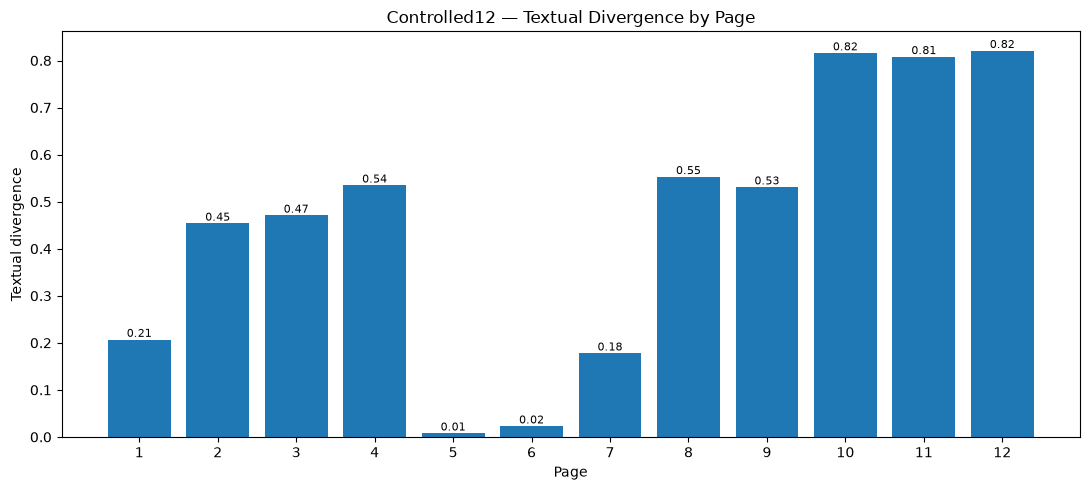

In [89]:
page_divergence_plot = (
    df_page_divergence[
        "textual_divergence"
    ]
    .sort_index()
)


fig, ax = plt.subplots(
    figsize=(11, 5)
)


bars = ax.bar(
    page_divergence_plot.index.astype(str),
    page_divergence_plot.values,
)


ax.set_title(
    "Controlled12 — Textual Divergence by Page"
)

ax.set_xlabel(
    "Page"
)

ax.set_ylabel(
    "Textual divergence"
)


for bar, value in zip(
    bars,
    page_divergence_plot.values,
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )


plt.tight_layout()
plt.show()

In [90]:
import html

from IPython.display import HTML, display


def show_page_comparison(
    page_number,
    stage="clean",
):
    """
    Display one source page across all four parsers.

    stage:
        "clean" -> final normalized Markdown
        "raw"   -> original parser Markdown
    """

    if page_number not in range(1, 13):
        raise ValueError(
            "page_number must be between 1 and 12"
        )

    if stage not in {
        "raw",
        "clean",
    }:
        raise ValueError(
            "stage must be 'raw' or 'clean'"
        )

    markdown_field = (
        "clean_markdown"
        if stage == "clean"
        else "raw_markdown"
    )

    parser_order = [
        "PyMuPDF",
        "Docling",
        "MinerU",
        "PaddleOCR",
    ]

    cards = []

    for parser in parser_order:
        records = pages_by_parser[
            parser
        ]

        record = next(
            item
            for item in records
            if item["page_number"]
            == page_number
        )

        text = (
            record.get(
                markdown_field,
                "",
            )
            or ""
        )

        escaped_text = html.escape(
            text
        )

        characters = len(
            text
        )

        lines = len(
            text.splitlines()
        )

        is_empty = markdown_is_empty(
            text
        )

        status = (
            "EMPTY"
            if is_empty
            else "CONTENT"
        )

        cards.append(
            f"""
            <div style="
                border:1px solid #bbb;
                border-radius:8px;
                padding:12px;
                min-width:0;
            ">
                <div style="
                    font-weight:700;
                    font-size:16px;
                    margin-bottom:4px;
                ">
                    {html.escape(parser)}
                </div>

                <div style="
                    font-size:12px;
                    margin-bottom:10px;
                ">
                    {characters:,} characters
                    &nbsp;|&nbsp;
                    {lines} lines
                    &nbsp;|&nbsp;
                    {status}
                </div>

                <pre style="
                    white-space:pre-wrap;
                    overflow-wrap:anywhere;
                    height:360px;
                    overflow-y:auto;
                    margin:0;
                    padding:10px;
                    border:1px solid #ddd;
                    border-radius:5px;
                    font-size:12px;
                    line-height:1.4;
                ">{escaped_text}</pre>
            </div>
            """
        )

    display(
        HTML(
            f"""
            <div style="
                margin-bottom:14px;
            ">
                <h3 style="margin-bottom:3px;">
                    Page {page_number}
                </h3>

                <div style="
                    font-size:13px;
                    margin-bottom:12px;
                ">
                    Stage: <strong>{stage}</strong>
                </div>
            </div>

            <div style="
                display:grid;
                grid-template-columns:
                    repeat(2, minmax(0, 1fr));
                gap:14px;
                width:100%;
            ">
                {''.join(cards)}
            </div>
            """
        )
    )

In [94]:
PAGE_TO_INSPECT = 10

show_page_comparison(
    PAGE_TO_INSPECT,
    stage="clean",
)

### Critical-page selection

Textual divergence is used as a triage mechanism rather than as a quality
metric.

The highest-divergence pages are:

1. page 12;
2. page 10;
3. page 11;
4. page 8;
5. page 4;
6. page 9;
7. page 3;
8. page 2.

Pages 5 and 6 show very high textual agreement between parsers, while page 7
also shows relatively low aggregate divergence.

However, page selection for qualitative analysis must not depend only on
textual similarity.

A page can be important because:

- its outputs differ strongly across parsers;
- it contains a deliberately difficult benchmark feature;
- it exercises OCR;
- it contains tables or formulas;
- it contains physically rotated visual content;
- normalization materially changes its output.

The deep-dive set therefore combines **observed divergence** with the known
Controlled12 workload design.

### Priority groups

**Table representation**

- Page 2 — standard table and special characters.
- Page 3 — financial table.
- Page 4 — difficult narrow table.
- Pages 9–11 — visual table content.

**Formatting / mathematical content**

- Page 7 — formatting and structured-text stress.
- Page 8 — mathematical/formula-related content.

**OCR / visual processing**

- Page 9 — upright visual content.
- Page 10 — physically rotated visual content.
- Page 11 — physically rotated visual content in the opposite direction.

**Normalization / empty-output behavior**

- Page 12 — repeated edge content and divergent final empty-page behavior.

Pages 5 and 6 remain useful as relatively stable prose reference pages.

### Important limitation of textual divergence

Text similarity measures representation difference, not correctness.

A high divergence score can result from:

- different Markdown syntax;
- different table serialization;
- different whitespace;
- different ordering;
- duplicated content;
- OCR differences;
- actual content loss.

A low divergence score can also occur when multiple parsers make the same
mistake.

The ranking is therefore used to decide **where to inspect**, never to decide
which parser is better.

In [95]:
parser_similarity_rows = []


for page_number in range(1, 13):
    texts = {
        parser:
            normalize_for_similarity(
                page_texts[
                    parser
                ][
                    page_number
                ]
            )
        for parser
        in page_texts
    }

    for parser in texts:
        other_parsers = [
            other
            for other in texts
            if other != parser
        ]

        similarities = []

        for other in other_parsers:
            similarity = SequenceMatcher(
                None,
                texts[parser],
                texts[other],
                autojunk=False,
            ).ratio()

            similarities.append(
                similarity
            )

        parser_similarity_rows.append(
            {
                "page":
                    page_number,

                "parser":
                    parser,

                "mean_similarity_to_others":
                    sum(similarities)
                    / len(similarities),
            }
        )


df_parser_page_similarity = (
    pd.DataFrame(
        parser_similarity_rows
    )
)


df_similarity_matrix = (
    df_parser_page_similarity
    .pivot(
        index="page",
        columns="parser",
        values="mean_similarity_to_others",
    )
    .round(3)
)


df_similarity_matrix

parser,Docling,MinerU,PaddleOCR,PyMuPDF
page,,,,
1,0.826,0.762,0.822,0.763
2,0.593,0.433,0.565,0.600
3,0.558,0.473,0.538,0.549
4,0.487,0.420,0.511,0.443
5,0.994,0.994,0.987,0.991
6,0.968,0.984,0.978,0.980
7,0.835,0.749,0.848,0.855
8,0.503,0.294,0.460,0.534
9,0.496,0.403,0.485,0.489


In [103]:
def lowest_similarity_parsers(
    row,
    tolerance=1e-9,
):
    minimum = row.min()

    parsers = [
        parser
        for parser, value
        in row.items()
        if abs(
            value - minimum
        ) <= tolerance
    ]

    return ", ".join(
        parsers
    )


df_page_outliers = pd.DataFrame(
    {
        "Most divergent parser(s)":
            df_similarity_matrix.apply(
                lowest_similarity_parsers,
                axis=1,
            ),

        "Lowest similarity":
            df_similarity_matrix.min(
                axis=1
            ),

        "Page divergence":
            df_page_divergence[
                "textual_divergence"
            ],
    }
)


df_page_outliers[
    "Lowest similarity"
] = (
    df_page_outliers[
        "Lowest similarity"
    ]
    .round(3)
)


df_page_outliers = (
    df_page_outliers
    .sort_values(
        "Page divergence",
        ascending=False,
    )
)


df_page_outliers

,Most divergent parser(s),Lowest similarity,Page divergence
page,,,
12,"PaddleOCR, PyMuPDF",0.026,0.821
10,PyMuPDF,0.094,0.816
11,Docling,0.126,0.808
8,MinerU,0.294,0.553
4,MinerU,0.420,0.535
9,MinerU,0.403,0.531
3,MinerU,0.473,0.471
2,MinerU,0.433,0.454
1,MinerU,0.762,0.207


### Parser-native page diagnostics

The page-level `parser_elements` schema is intentionally parser-specific.

No `parser_elements` field is shared by all four adapters.

This means parser-native structural counts cannot be treated as a directly
comparable quality metric.

For example, table information is represented differently:

- PyMuPDF exposes `tables_detected`;
- Docling exposes `tables_detected`;
- MinerU exposes parser-native type counts;
- PaddleOCR exposes structured table results and a native table count.

Likewise, formula and visual metadata follow different parser-specific
representations.

The following diagnostics therefore answer:

> "What did each parser report internally for this page?"

They do **not** answer:

> "How many true tables or formulas exist on this page?"

The source document remains the reference for qualitative inspection.

In [97]:
page_record_lookup = {
    parser: {
        record["page_number"]:
            record
        for record
        in page_records
    }
    for parser, page_records
    in pages_by_parser.items()
}


def native_table_count(
    parser,
    record,
):
    elements = record[
        "parser_elements"
    ]

    native = record[
        "parser_native"
    ]

    if parser == "PyMuPDF":
        return elements.get(
            "tables_detected"
        )

    if parser == "Docling":
        return elements.get(
            "tables_detected"
        )

    if parser == "MinerU":
        type_counts = (
            elements.get(
                "type_counts"
            )
            or {}
        )

        return type_counts.get(
            "table"
        )

    if parser == "PaddleOCR":
        return native.get(
            "table_count"
        )

    return None


def native_formula_count(
    parser,
    record,
):
    elements = record[
        "parser_elements"
    ]

    native = record[
        "parser_native"
    ]

    if parser == "PyMuPDF":
        return elements.get(
            "formulas_detected"
        )

    if parser == "Docling":
        return elements.get(
            "formulas_detected"
        )

    if parser == "MinerU":
        type_counts = (
            elements.get(
                "type_counts"
            )
            or {}
        )

        return type_counts.get(
            "equation"
        )

    if parser == "PaddleOCR":
        return native.get(
            "formula_count"
        )

    return None

In [98]:
native_table_rows = []


for page_number in range(1, 13):
    row = {
        "page":
            page_number,
    }

    for parser in [
        "PyMuPDF",
        "Docling",
        "MinerU",
        "PaddleOCR",
    ]:
        record = (
            page_record_lookup[
                parser
            ][
                page_number
            ]
        )

        row[parser] = (
            native_table_count(
                parser,
                record,
            )
        )

    native_table_rows.append(
        row
    )


df_native_tables = (
    pd.DataFrame(
        native_table_rows
    )
    .set_index(
        "page"
    )
)


df_native_tables

,PyMuPDF,Docling,MinerU,PaddleOCR
page,,,,
1,0,0,NaN,0
2,1,1,1.0,1
3,1,1,1.0,1
4,1,1,1.0,1
5,0,0,NaN,0
6,0,0,NaN,0
7,1,1,1.0,1
8,1,1,1.0,1
9,1,1,1.0,1


## 11. Operational trade-offs

Tokens versus runtime and resource constraints without claiming a quality winner.

**Implementation status:** planned for the next validated step.

In [99]:
native_formula_rows = []


for page_number in range(1, 13):
    row = {
        "page":
            page_number,
    }

    for parser in [
        "PyMuPDF",
        "Docling",
        "MinerU",
        "PaddleOCR",
    ]:
        record = (
            page_record_lookup[
                parser
            ][
                page_number
            ]
        )

        row[parser] = (
            native_formula_count(
                parser,
                record,
            )
        )

    native_formula_rows.append(
        row
    )


df_native_formulas = (
    pd.DataFrame(
        native_formula_rows
    )
    .set_index(
        "page"
    )
)


df_native_formulas

,PyMuPDF,Docling,MinerU,PaddleOCR
page,,,,
1,0,0,NaN,0
2,0,0,NaN,0
3,0,0,NaN,0
4,0,0,NaN,0
5,0,0,NaN,0
6,0,0,NaN,0
7,0,0,NaN,0
8,1,0,4.0,5
9,0,0,NaN,0


In [100]:
ocr_tracking_rows = []


for page_number in range(1, 13):
    row = {
        "page":
            page_number,
    }

    for parser, metrics in metrics_by_parser.items():
        ocr = require_path(
            metrics,
            "processing",
            "ocr",
        )

        requested_pages = (
            optional_path(
                ocr,
                "requested_page_numbers",
            )
        )

        if isinstance(
            requested_pages,
            list,
        ):
            row[parser] = (
                page_number
                in requested_pages
            )

        else:
            row[parser] = (
                "N/A"
            )

    ocr_tracking_rows.append(
        row
    )


df_ocr_page_tracking = (
    pd.DataFrame(
        ocr_tracking_rows
    )
    .set_index(
        "page"
    )
)


df_ocr_page_tracking

,PyMuPDF,Docling,MinerU,PaddleOCR
page,,,,
1,False,N/A,N/A,True
2,False,N/A,N/A,True
3,False,N/A,N/A,True
4,False,N/A,N/A,True
5,False,N/A,N/A,True
6,False,N/A,N/A,True
7,False,N/A,N/A,True
8,False,N/A,N/A,True
9,True,N/A,N/A,True


In [101]:
paddle_orientation_rows = []


for page_number in range(1, 13):
    record = (
        page_record_lookup[
            "PaddleOCR"
        ][
            page_number
        ]
    )

    native = record[
        "parser_native"
    ]

    paddle_orientation_rows.append(
        {
            "page":
                page_number,

            "document_angle":
                native.get(
                    "document_angle"
                ),

            "ocr_text_count":
                native.get(
                    "ocr_text_count"
                ),

            "table_count":
                native.get(
                    "table_count"
                ),

            "formula_count":
                native.get(
                    "formula_count"
                ),

            "parsing_block_count":
                native.get(
                    "parsing_block_count"
                ),

            "textline_orientation_counts":
                native.get(
                    "textline_orientation_counts"
                ),
        }
    )


df_paddle_orientation = (
    pd.DataFrame(
        paddle_orientation_rows
    )
    .set_index(
        "page"
    )
)


df_paddle_orientation

,document_angle,ocr_text_count,table_count,formula_count,parsing_block_count,textline_orientation_counts
page,,,,,,
1,0,6,0,0,4,{'0': 5}
2,0,59,1,0,8,{'0': 59}
3,0,40,1,0,4,{'0': 39}
4,0,134,1,0,4,{'0': 133}
5,0,42,0,0,9,{'0': 41}
6,0,41,0,0,9,{'0': 40}
7,0,47,1,0,27,{'0': 46}
8,0,37,1,5,16,{'0': 31}
9,0,45,1,0,5,{'0': 44}


In [102]:
df_paddle_orientation.loc[
    [
        9,
        10,
        11,
    ]
]

,document_angle,ocr_text_count,table_count,formula_count,parsing_block_count,textline_orientation_counts
page,,,,,,
9,0,45,1,0,5,{'0': 44}
10,270,44,1,0,4,{'0': 44}
11,90,44,1,0,4,"{'0': 36, '1': 8}"


In [116]:
def format_diagnostic_value(
    value,
    digits=None,
):
    if value is None:
        return "N/A"

    if (
        not isinstance(
            value,
            (list, dict, str),
        )
        and pd.isna(value)
    ):
        return "N/A"

    if (
        digits is not None
        and isinstance(
            value,
            (int, float),
        )
        and not isinstance(
            value,
            bool,
        )
    ):
        return round(
            value,
            digits,
        )

    return value


def show_page_analysis(
    page_number,
):
    """
    Show diagnostic summary and final Markdown
    for one Controlled12 page.

    Parser-native counts are diagnostic signals,
    not ground-truth measurements.
    """

    if page_number not in range(
        1,
        13,
    ):
        raise ValueError(
            "page_number must be between 1 and 12"
        )

    parser_order = [
        "PyMuPDF",
        "Docling",
        "MinerU",
        "PaddleOCR",
    ]

    divergence = (
        df_page_divergence
        .loc[
            page_number
        ]
    )

    outlier = (
        df_page_outliers
        .loc[
            page_number
        ]
    )

    # --------------------------------------------------------
    # Page-level headline
    # --------------------------------------------------------

    display(
        HTML(
            f"""
            <div style="
                border:1px solid #bbb;
                border-radius:8px;
                padding:14px;
                margin-bottom:14px;
            ">
                <div style="
                    font-size:20px;
                    font-weight:700;
                    margin-bottom:8px;
                ">
                    Page {page_number} — Audit
                </div>

                <div style="
                    display:flex;
                    flex-wrap:wrap;
                    gap:22px;
                    font-size:13px;
                ">
                    <div>
                        <strong>Textual divergence:</strong>
                        {divergence['textual_divergence']:.3f}
                    </div>

                    <div>
                        <strong>Character spread:</strong>
                        {int(divergence['character_spread']):,}
                    </div>

                    <div>
                        <strong>Empty outputs:</strong>
                        {int(divergence['empty_outputs'])}
                    </div>

                    <div>
                        <strong>
                            Most divergent parser(s):
                        </strong>
                        {
                            outlier[
                                'Most divergent parser(s)'
                            ]
                        }
                    </div>
                </div>
            </div>
            """
        )
    )

    # --------------------------------------------------------
    # Parser-level diagnostics
    # --------------------------------------------------------

    diagnostic_rows = []

    for parser in parser_order:
        page_stats = (
            df_pages
            .loc[
                (
                    page_number,
                    parser,
                )
            ]
        )

        native_table = (
            df_native_tables
            .loc[
                page_number,
                parser,
            ]
        )

        native_formula = (
            df_native_formulas
            .loc[
                page_number,
                parser,
            ]
        )

        ocr_tracking = (
            df_ocr_page_tracking
            .loc[
                page_number,
                parser,
            ]
        )

        similarity = (
            df_similarity_matrix
            .loc[
                page_number,
                parser,
            ]
        )

        document_angle = None

        if parser == "PaddleOCR":
            document_angle = (
                df_paddle_orientation
                .loc[
                    page_number,
                    "document_angle",
                ]
            )

        diagnostic_rows.append(
            {
                "Parser":
                    parser,

                "Raw chars":
                    int(
                        page_stats[
                            "raw_characters"
                        ]
                    ),

                "Final chars":
                    int(
                        page_stats[
                            "final_characters"
                        ]
                    ),

                "Chars removed":
                    int(
                        page_stats[
                            "characters_removed"
                        ]
                    ),

                "Final lines":
                    int(
                        page_stats[
                            "final_lines"
                        ]
                    ),

                "Similarity to others":
                    format_diagnostic_value(
                        similarity,
                        digits=3,
                    ),

                "Native table signal":
                    format_diagnostic_value(
                        native_table
                    ),

                "Table serialization":
                    get_table_serialization(
                        page_number,
                        parser,
                    ),

                "Native formula signal":
                    format_diagnostic_value(
                        native_formula
                    ),

                "OCR tracked":
                    format_diagnostic_value(
                        ocr_tracking
                    ),

                "Document angle":
                    format_diagnostic_value(
                        document_angle
                    ),

                "Final empty":
                    bool(
                        page_stats[
                            "final_empty"
                        ]
                    ),
            }
        )

    df_page_audit = (
        pd.DataFrame(
            diagnostic_rows
        )
        .set_index(
            "Parser"
        )
    )

    display(
        df_page_audit
    )

    # --------------------------------------------------------
    # Actual final Markdown — 2 × 2 viewer
    # --------------------------------------------------------

    show_page_comparison(
        page_number,
        stage="clean",
    )

In [117]:
PAGE_TO_INSPECT = 8

show_page_analysis(
    PAGE_TO_INSPECT
)

,Raw chars,Final chars,Chars removed,Final lines,Similarity to others,Native table signal,Table serialization,Native formula signal,OCR tracked,Document angle,Final empty
Parser,,,,,,,,,,,
PyMuPDF,763,733,30,33,0.534,1.0,Markdown table,1.0,False,N/A,False
Docling,717,717,0,29,0.503,1.0,Markdown table,0.0,N/A,N/A,False
MinerU,1050,994,56,29,0.294,1.0,No recognized table markup,4.0,N/A,N/A,False
PaddleOCR,1145,1144,1,28,0.460,1.0,HTML table,5.0,True,0,False


In [110]:
show_page_comparison(
    12,
    stage="raw",
)

### Downstream serialization audit

Parser-native detection and downstream serialization are different stages.

A parser may correctly identify a table, formula or other structured region
internally while representing that content differently in the final Markdown.

For example, a detected table may be serialized as:

- Markdown pipe-table syntax;
- HTML `<table>` markup;
- plain text;
- another parser-specific representation.

The common document-level structure metrics from Section 9 intentionally
recognize a limited set of Markdown structures.

Therefore, a value such as:

```text
Markdown tables = 0

In [111]:
import re


def count_markdown_table_blocks(
    text,
):
    """
    Count Markdown pipe-table blocks using
    separator-row detection.

    Diagnostic heuristic only.
    """
    lines = (
        text
        .splitlines()
    )

    separator_pattern = re.compile(
        r"""
        ^\s*
        \|?
        \s*:?-{3,}:?\s*
        (
            \|
            \s*:?-{3,}:?\s*
        )+
        \|?
        \s*$
        """,
        re.VERBOSE,
    )

    return sum(
        bool(
            separator_pattern.match(
                line
            )
        )
        for line in lines
    )


def count_html_tables(
    text,
):
    return len(
        re.findall(
            r"<table\b",
            text,
            flags=re.IGNORECASE,
        )
    )


def count_html_rows(
    text,
):
    return len(
        re.findall(
            r"<tr\b",
            text,
            flags=re.IGNORECASE,
        )
    )


def count_html_cells(
    text,
):
    return len(
        re.findall(
            r"<t[dh]\b",
            text,
            flags=re.IGNORECASE,
        )
    )


def count_markdown_headings(
    text,
):
    return len(
        re.findall(
            r"(?m)^\s*#{1,6}\s+\S",
            text,
        )
    )


def count_fenced_code_blocks(
    text,
):
    fences = len(
        re.findall(
            r"(?m)^\s*```",
            text,
        )
    )

    return fences // 2


serialization_rows = []


for parser, page_records in pages_by_parser.items():
    for record in page_records:
        text = (
            record.get(
                "clean_markdown",
                "",
            )
            or ""
        )

        serialization_rows.append(
            {
                "page":
                    record[
                        "page_number"
                    ],

                "parser":
                    parser,

                "markdown_tables":
                    count_markdown_table_blocks(
                        text
                    ),

                "html_tables":
                    count_html_tables(
                        text
                    ),

                "html_rows":
                    count_html_rows(
                        text
                    ),

                "html_cells":
                    count_html_cells(
                        text
                    ),

                "markdown_headings":
                    count_markdown_headings(
                        text
                    ),

                "fenced_code_blocks":
                    count_fenced_code_blocks(
                        text
                    ),
            }
        )


df_page_serialization = (
    pd.DataFrame(
        serialization_rows
    )
    .set_index(
        [
            "page",
            "parser",
        ]
    )
    .sort_index()
)

In [113]:
STRUCTURAL_PAGES = [
    1,
    2,
    3,
    4,
    7,
    8,
    9,
    10,
    11,
]


df_serialization_tables = (
    df_page_serialization[
        [
            "markdown_tables",
            "html_tables",
            "html_rows",
            "html_cells",
        ]
    ]
    .loc[
        STRUCTURAL_PAGES
    ]
)


df_serialization_tables

markdown_tables  html_tables  html_rows  html_cells
page parser                                                        
1    Docling                  0            0          0           0
     MinerU                   0            0          0           0
     PaddleOCR                0            0          0           0
     PyMuPDF                  0            0          0           0
2    Docling                  1            0          0           0
     MinerU                   0            1          5          35
     PaddleOCR                0            1          5          35
     PyMuPDF                  1            0          0           0
3    Docling                  1            0          0           0
     MinerU                   0            1          8          32
     PaddleOCR                0            1          8          32
     PyMuPDF                  1            0          0           0
4    Docling                  1            0          0           0
     MinerU                   0            1          6          51
     PaddleOCR                0            1          5          50
     PyMuPDF                  1            0          0           0
7    Docling                  1            0          0           0
     MinerU                   0            1          5          25
     PaddleOCR                0            1          1           5
     PyMuPDF                  1            0          0           0
8    Docling                  1            0          0           0
     MinerU                   0            0          0           0
     PaddleOCR                0            1          4          20
     PyMuPDF                  1            0          0           0
9    Docling                  1            0          0           0
     MinerU                   0            1          5          35
     PaddleOCR                0            1          5          35
     PyMuPDF                  1            0          0           0
10   Docling                  1            0          0           0
     MinerU                   0            1          5          35
     PaddleOCR                0            1          5          35
     PyMuPDF                  1            0          0           0
11   Docling                  1            0          0           0
     MinerU                   0            1          5          35
     PaddleOCR                0            1          5          35
     PyMuPDF                  1            0          0           0

In [114]:
def table_representation_label(
    row,
):
    markdown_tables = (
        row[
            "markdown_tables"
        ]
    )

    html_tables = (
        row[
            "html_tables"
        ]
    )

    if (
        markdown_tables > 0
        and html_tables > 0
    ):
        return (
            "Markdown + HTML"
        )

    if markdown_tables > 0:
        return (
            "Markdown table"
        )

    if html_tables > 0:
        return (
            "HTML table"
        )

    return (
        "No recognized table markup"
    )


serialization_labels = []


for page_number in STRUCTURAL_PAGES:
    row = {
        "page":
            page_number,
    }

    for parser in [
        "PyMuPDF",
        "Docling",
        "MinerU",
        "PaddleOCR",
    ]:
        metrics = (
            df_page_serialization
            .loc[
                (
                    page_number,
                    parser,
                )
            ]
        )

        row[parser] = (
            table_representation_label(
                metrics
            )
        )

    serialization_labels.append(
        row
    )


df_table_representation = (
    pd.DataFrame(
        serialization_labels
    )
    .set_index(
        "page"
    )
)


df_table_representation

,PyMuPDF,Docling,MinerU,PaddleOCR
page,,,,
1,No recognized table markup,No recognized table markup,No recognized table markup,No recognized table markup
2,Markdown table,Markdown table,HTML table,HTML table
3,Markdown table,Markdown table,HTML table,HTML table
4,Markdown table,Markdown table,HTML table,HTML table
7,Markdown table,Markdown table,HTML table,HTML table
8,Markdown table,Markdown table,No recognized table markup,HTML table
9,Markdown table,Markdown table,HTML table,HTML table
10,Markdown table,Markdown table,HTML table,HTML table
11,Markdown table,Markdown table,HTML table,HTML table


In [ ]:
def get_table_serialization(
    page_number,
    parser,
):
    """
    Return the table serialization observed in the
    final clean Markdown for one parser/page.

    This describes representation syntax only.
    It is not a table-quality score.
    """

    row = (
        df_page_serialization
        .loc[
            (
                page_number,
                parser,
            )
        ]
    )

    return table_representation_label(
        row
    )

In [118]:
PAGE_TO_AUDIT = 2


for parser in [
    "PyMuPDF",
    "Docling",
    "MinerU",
    "PaddleOCR",
]:
    text = (
        page_texts[
            parser
        ][
            PAGE_TO_AUDIT
        ]
    )

    print()
    print("=" * 88)
    print(
        f"PAGE {PAGE_TO_AUDIT} — {parser}"
    )
    print("=" * 88)
    print()

    print(
        text
        if text.strip()
        else "[EMPTY]"
    )

    print()


PAGE 2 — PyMuPDF

# 1 - Primeiro teste. 

1.1 - Estes testes têm como finalidade testar o OCR e a quantidade de tokens em cada documento diferente a ser utilizado. 

## 1.1.1 - Tabela normal feita no editor de texto 

|Ítem|Tabela|Preço|Quantidad<br>e|Aleatório|Justificativ<br>a|Ordem|
|---|---|---|---|---|---|---|
|Nenhum|1|R$45,00|4165416|SABOR|Menor<br>Preço|14º|
|Qualquer|2|R$244,00|3541646|QUALIDA<br>DE|Maior<br>qualidade|5º|
|Ação|3|R$ 00-3|31646984|ESTRATÉ<br>GIA|Indefinido|9ª|
|Outro|4|$231|3123684|NADA|Percepção|45%|



1.1.2 - Testando Diferentes Caracteres 

“ ! @ # $ % ¨ & * ( ) _ + 

¹ ² ³ £ ¢ ¬ § 

‘ 1 2 3 4 5 6 7 8 9 0 - = 

q w e r t y u i o p ´ [ a s d f g h j k l ç ~] 

z x c v b n m , . ; / \ | \ ª º  °   , 

Q W E R T Y U I O P 

A S D F G H J K L Ç 

Z X C V B N M 

Rodapé das outras páginas 2


PAGE 2 — Docling

## 1 - Primeiro teste.

- 1.1 - Estes testes têm como finalidade testar o OCR e a quantidade de tokens em cada documento diferente a ser utilizado.

## 1

#### Page 2 — Standard table and special-character stress test

All four parsers identified the page table and preserved its basic 5-row ×
7-column geometry.

The main differences are therefore not table detection, but **serialization,
text fidelity and reading order**.

**PyMuPDF**

- serialized the table as Markdown;
- preserved the key numeric and ordinal values;
- retained good special-character fidelity;
- introduced `<br>` fragmentation inside several table words;
- retained residual footer/page-number content.

**Docling**

- serialized the table as Markdown;
- preserved the key numeric and ordinal values;
- introduced spaces inside several words;
- represented a normal paragraph as a list item;
- represented the special-character section as a fenced code block;
- produced no visible repeated page-edge text in the final page output.

**MinerU**

- serialized the table as HTML;
- preserved the 5 × 7 table geometry;
- reconstructed several words without the fragmentation visible in PyMuPDF
  and Docling;
- transformed ordinal text such as `14º`, `5º` and `9ª` into mathematical
  notation;
- placed the special-character content before its corresponding section
  heading, altering reading order;
- used a comparatively verbose HTML representation.

**PaddleOCR**

- serialized the table as HTML;
- preserved the 5 × 7 table geometry;
- introduced multiple character-level OCR substitutions;
- altered accents and ordinal symbols;
- produced a significant recognition error for `9ª`;
- substantially degraded the special-character stress sequence;
- generated additional HTML wrapper markup.

The page demonstrates that **table structure preservation and text fidelity are
separate quality dimensions**.

It also demonstrates that the document-level `Markdown tables` metric should
not be interpreted as table-detection performance: MinerU and PaddleOCR preserve
table structures using HTML rather than Markdown pipe-table syntax.

For this page, PyMuPDF and Docling provide the strongest overall textual
fidelity, although with different formatting artifacts.

MinerU preserves substantial structured content but introduces reading-order
and semantic-representation changes.

PaddleOCR preserves table geometry but shows the largest character-level
degradation on this digitally structured page.

These observations are page-specific and do not establish an overall parser
quality ranking.

In [119]:
PAGE_TO_AUDIT = 3

for parser in [
    "PyMuPDF",
    "Docling",
    "MinerU",
    "PaddleOCR",
]:
    text = (
        page_texts[
            parser
        ][
            PAGE_TO_AUDIT
        ]
    )

    print()
    print("=" * 88)
    print(
        f"PAGE {PAGE_TO_AUDIT} — {parser}"
    )
    print("=" * 88)
    print()

    print(
        text
        if text.strip()
        else "[EMPTY]"
    )

    print()


PAGE 3 — PyMuPDF

|**Item / Descrição**|**Qtd.**|**Valor Unitário**|**Valor Total**|
|---|---|---|---|
|Notebook Pro 15"|2|R$ 6.500,00|R$ 13.000,00|
|Monitor UltraWide<br>29"|3|R$ 1.250,00|R$ 3.750,00|
|Teclado Mecânico<br>Sem Fio|4|R$ 350,00|R$ 1.400,00|
|Mouse<br>Ergonômico|4|R$ 220,00|R$ 880,00|
|Headset Noise<br>Cancelling|2|R$ 890,00|R$ 1.780,00|
|Suporte Articulado<br>para Monitor|3|R$ 180,00|R$ 540,00|
|**TOTAL DA**<br>**COMPRA**|**18**|—|**R$ 21.350,00**|



Rodapé das outras páginas 3


PAGE 3 — Docling

| Item / Descrição                |   Qtd. | Valor Unitário   | Valor Total   |
|---------------------------------|--------|------------------|---------------|
| Notebook Pro 15"                |      2 | R$ 6.500,00      | R$ 13.000,00  |
| Monitor UltraWide 29"           |      3 | R$ 1.250,00      | R$ 3.750,00   |
| Teclado Mecânico Sem Fio        |      4 | R$ 350,00        | R$ 1.400,00   |
| Mouse Ergonômico                |      4 | R$ 220,00        | R$ 880,00     |


#### Page 3 — Financial table

All four parsers identified and preserved the basic 8-row × 4-column table
structure.

The page therefore provides a useful test of **financial-value fidelity**
independently from basic table detection.

**PyMuPDF**

- serialized the table as Markdown;
- preserved quantities and financial values;
- retained Markdown emphasis in header/total cells;
- introduced `<br>` fragmentation inside several descriptions;
- retained residual footer/page-number content.

**Docling**

- serialized the table as Markdown;
- preserved quantities and financial values;
- produced the cleanest continuous product descriptions among the four
  outputs;
- did not expose visible repeated page-edge content in the final page text;
- represented the final placeholder cell differently from PyMuPDF.

**MinerU**

- serialized the table as HTML;
- preserved the 8 × 4 geometry and the principal financial values;
- encoded the double quote as the valid HTML entity `&quot;`;
- removed spaces inside several multi-word descriptions;
- represented the final placeholder cell as empty;
- produced a substantially more verbose serialization.

**PaddleOCR**

- serialized the table as HTML;
- preserved the 8 × 4 geometry, quantities and final purchase total;
- introduced character-level substitutions such as `Descrição → Descriço`
  and `Noise → Nojse`;
- changed several Brazilian-formatted monetary values from forms such as
  `6.500,00` to `6,500.00`;
- mixed both separator conventions within the same table.

The page demonstrates an important distinction between **textual divergence**
and **quality impact**.

MinerU is the largest textual outlier on this page, partly because of its HTML
serialization and word concatenation.

However, PaddleOCR introduces the more consequential financial-data changes,
despite not being the largest textual outlier.

Therefore:

> Textual divergence identifies where outputs differ, but manual or
> ground-truth inspection is required to determine how important those
> differences are.

For financial-document ingestion, numeric-format fidelity should be evaluated
as an independent quality dimension rather than inferred from generic text
similarity.

In [120]:
PAGE_TO_AUDIT = 4

for parser in [
    "PyMuPDF",
    "Docling",
    "MinerU",
    "PaddleOCR",
]:
    text = (
        page_texts[
            parser
        ][
            PAGE_TO_AUDIT
        ]
    )

    print()
    print("=" * 88)
    print(
        f"PAGE {PAGE_TO_AUDIT} — {parser}"
    )
    print("=" * 88)
    print()

    print(
        text
        if text.strip()
        else "[EMPTY]"
    )

    print()


PAGE 4 — PyMuPDF

|**Cód.**<br>**Item**|**Data**|**Desc**<br>**rição**<br>**do**<br>**Prod**<br>**uto**|**Cate**<br>**goria**|**Qtd.**|**Vlr.**<br>**Unit**<br>**ário**|**Vlr.**<br>**Total**|**Stat**<br>**us**<br>**Pagt**<br>**o.**|**Data**<br>**Entr**<br>**ega**|**N°**<br>**Nota**<br>**Fisc**<br>**al**|
|---|---|---|---|---|---|---|---|---|---|
|#100<br>1|10/0<br>8/20<br>26|Note<br>book<br>Pro<br>15"|Hard<br>ware|2|R$ 6.50<br>0,00|R$ 13.0<br>00,0<br>0|Pago|14/0<br>8/20<br>26|NF-8<br>9021|
|#100<br>2|11/08<br>/202<br>6|Monit<br>or<br>Ultra<br>Wide<br>29"|Perif<br>érico<br>s|3|R$ 1.25<br>0,00|R$ 3.75<br>0,00|Apro<br>vado|18/0<br>8/20<br>26|NF-8<br>9045|
|#100<br>3|12/0<br>8/20<br>26|Tecla<br>do<br>Mecâ<br>nico<br>Sem<br>Fio|Perif<br>érico<br>s|4|R$ 350,<br>00|R$ 1.40<br>0,00|Pend<br>ente|20/0<br>8/20<br>26|—|
|#100<br>4|12/0<br>8/20<br>26|Cade<br>ira<br>Ergo<br>nômi<br>ca<br>Mesh|Mobil<br>iário|2|R$ 1.10<br>0,00|R$ 2.20<br>0,00|Pago|15/0<br>8/20<br>26|NF-8<br>9102|



Rodapé das outras 

#### Page 4 — Difficult narrow table

All four parsers detected a table and preserved the four data records and ten
recognizable logical columns.

However, the narrow column geometry produces substantially different
serialization behavior.

**PyMuPDF**

- serialized the table as Markdown;
- preserved the logical table geometry;
- retained most textual and numeric content;
- introduced extensive `<br>` fragmentation inside words, dates and monetary
  values;
- retained residual footer/page-number content.

**Docling**

- serialized the table as Markdown;
- preserved the logical table geometry;
- represented narrow-column fragmentation primarily as inserted spaces;
- consequently split words, dates and monetary values;
- retained the repeated page header on this page and represented it as a
  Markdown heading.

**MinerU**

- serialized the table as HTML;
- preserved the four data records and ten logical content columns;
- reconstructed dates and monetary values in substantially cleaner continuous
  forms than the other three outputs;
- removed spaces from many multi-word labels and descriptions;
- introduced several character substitutions;
- represented the header using `rowspan`, producing an additional HTML row and
  one empty cell.

The resulting `6 rows / 51 cells` diagnostic does **not** indicate an extra data
record. It reflects the parser's header serialization strategy.

**PaddleOCR**

- serialized the table as HTML;
- preserved a flat 5-row × 10-column geometry;
- introduced substantial narrow-column fragmentation;
- produced several OCR substitutions in headings and descriptions;
- again altered decimal punctuation in some monetary values.

This page demonstrates why structural counts must be interpreted together with
the actual serialized content.

Different HTML row/cell counts can result from `rowspan` or `colspan` choices
rather than from true row creation or loss.

It also demonstrates different failure modes:

- PyMuPDF and Docling primarily preserve content while fragmenting it according
  to narrow visual layout;
- MinerU reconstructs many dates and numeric values more cleanly but tends to
  concatenate words;
- PaddleOCR preserves geometry but shows greater character-level and monetary
  value degradation.

The difficult-table case therefore requires evaluation across at least three
independent dimensions:

1. logical table geometry;
2. textual/numeric fidelity;
3. downstream serialization quality.

In [121]:
PAGE_TO_AUDIT = 8

for parser in [
    "PyMuPDF",
    "Docling",
    "MinerU",
    "PaddleOCR",
]:
    text = (
        page_texts[
            parser
        ][
            PAGE_TO_AUDIT
        ]
    )

    print()
    print("=" * 88)
    print(
        f"PAGE {PAGE_TO_AUDIT} — {parser}"
    )
    print("=" * 88)
    print()

    print(
        text
        if text.strip()
        else "[EMPTY]"
    )

    print()


PAGE 8 — PyMuPDF

|#01|Text extraction|**OK**|12.4|99,8%|
|---|---|---|---|---|
|#02|Table Layout|_Atenção_|145.0|82,1%|
|#03|Nested Lists|**OK**|34.2|95,0%|
|#04|Math Formulas|_Falha_|89.1|45,3%|



**Nota de Alerta:** "Bibliotecas baseadas apenas em regra sintática costumam perder a estrutura tabular se as bordas do PDF forem invisíveis." — _Manuais de Engenharia de Dados_ . 

#### <u>ESSE É UM TEXTO SUBLINHADO PARA TESTE</u> 

#### **1. Bhaskara:** 

x = (-b ± √(b² - 4ac)) / (2a) 

2. Limite: 

lim `₍` ₓ `→ ₀₎` (sin x / x) = 1 

3. Integral de Gauss: 



4. Desvio Padrão (Somatório) 

**:** σ = √( (1/N) * ∑ ᵢ `₌₁` ᴺ (x ᵢ - μ)² ) 

5. Transformada de Fourier: 

f `̂` (ξ) = ∫ `₋` ∞ `⁺` ∞ f(x) e `⁻` ² ᵖ ⁱⁱˣ ᵍ dx 

Rodapé das outras páginas 8


PAGE 8 — Docling

| #01   | Text extraction   | OK      |   12.4 | 99,8%   |
|-------|-------------------|---------|--------|---------|
| #02   | Table Layout      | Atenção |  145.0 | 82,1%   |
| #03   | Nested Lists      | OK      |   34.2 | 9

#### Page 8 — Mathematical-content stress test

Page 8 exposes major differences in mathematical-content preservation.

The parser-native formula signals were:

| Parser | Native formula signal |
|---|---:|
| PyMuPDF | 1 |
| Docling | 0 |
| MinerU | 4 |
| PaddleOCR | 5 |

The actual downstream text demonstrates that formula count alone is not an
adequate quality metric.

**PyMuPDF**

- preserved the initial table as Markdown;
- preserved the warning text and underline markup;
- represented Bhaskara and the limit in readable text;
- preserved a partially readable standard-deviation expression;
- lost the visible mathematical content of the Gaussian-integral section;
- produced a degraded Fourier expression;
- retained residual footer/page-number content.

**Docling**

- preserved the initial table cleanly as Markdown;
- preserved the warning text;
- preserved Bhaskara as readable text;
- did not preserve most of the remaining equations as mathematical text;
- represented several mathematical regions as `<!-- image -->` placeholders;
- left only fragmentary text for the Fourier section.

For a text-only downstream pipeline, these image placeholders do not by
themselves provide the mathematical content required by retrieval or an LLM.

**MinerU**

- generated explicit LaTeX blocks for four formula regions;
- preserved the limit separately as Unicode/plain text;
- produced substantially corrupted mathematical representations in several
  of the generated LaTeX expressions;
- omitted the initial table from recognizable table markup in the final
  Markdown;
- did not preserve some narrative content visible in the other parser outputs.

This demonstrates that higher formula-detection coverage does not guarantee
higher mathematical fidelity.

**PaddleOCR**

- preserved the initial table as HTML;
- generated explicit LaTeX for all five mathematical expressions;
- produced strong structured representations for Bhaskara and the limit;
- preserved substantially more usable mathematical structure for the Gaussian
  integral and standard deviation than the other outputs;
- still introduced apparent symbol/operator errors;
- produced substantial degradation in the Fourier expression;
- introduced some accent loss in surrounding prose.

The page therefore separates two dimensions that should remain independent:

1. **mathematical coverage** — whether an expression survives as usable
   mathematical text;
2. **mathematical fidelity** — whether the serialized expression preserves the
   original mathematical meaning.

For this page, PaddleOCR provides the broadest mathematical-text coverage, but
none of the four outputs should yet be considered fully reliable for complex
formula transcription without ground-truth evaluation.

Docling has the weakest mathematical-text coverage in the current text-only
artifact, while MinerU demonstrates that explicit LaTeX output can still
contain substantial semantic corruption.

The results reinforce a central benchmark rule:

> Native formula counts are diagnostic signals, not formula-quality scores.

In [122]:
PAGE_TO_AUDIT = 9

for parser in [
    "PyMuPDF",
    "Docling",
    "MinerU",
    "PaddleOCR",
]:
    text = (
        page_texts[
            parser
        ][
            PAGE_TO_AUDIT
        ]
    )

    print()
    print("=" * 88)
    print(
        f"PAGE {PAGE_TO_AUDIT} — {parser}"
    )
    print("=" * 88)
    print()

    print(
        text
        if text.strip()
        else "[EMPTY]"
    )

    print()


PAGE 9 — PyMuPDF

## 1.1.1 - Tabela normal feita no editor de texto 

|item \||Tabela\||Prego|Quantidad \| <br>of|Aleatorio\||Justificativ <br>al|Ordem|
|---|---|---|---|---|---|---|
|Nenhum|1|R$45,00|4165416]|SABOR|Menor<br>Prego\||14°|
|Qualquer|2|R$244,00\||3541646\||QUALIDA <br>DE]|Maior<br>qualidade|5°|
|Acéo\||3|R$ 00-3}|31646984|ESTRATE\| <br>GIA]|Indefinido|9|
|Outro|4|$231|3123684|NADA\||Percep¢ao|45%|



Rodapé das outras páginas 9


PAGE 9 — Docling

## 1.1.1 - Tabela normal feita no editor de texto

| Ítem     | Tabela   | Preço    |   Quantidad e | Aleatório   | Justificativ a   | Ordem   |
|----------|----------|----------|---------------|-------------|------------------|---------|
| Nenhum   | 1        | R$45,00  |       4165416 | SABOR       | Menor Preço      | 14°     |
| Qualquer | 2        | R$244,00 |       3541646 | QUALIDA DE  | Maior qualidade  | 5º      |
| Ação     | ε        | R$ 00-3  |      31646984 | ESTRATÉ GIA | Indefinido       | ε6      |
| ono      |

#### Page 9 — Upright visual table

Page 9 provides the baseline for the visual-table portion of Controlled12
before physical rotation is introduced on Pages 10 and 11.

All four parsers detected a table and preserved a recognizable 5-row ×
7-column structure.

The principal differences are therefore in OCR/text fidelity rather than basic
table geometry.

**PyMuPDF**

- serialized the table as Markdown;
- preserved the principal numeric values;
- introduced multiple character-level recognition errors;
- altered several accented words and ordinal symbols;
- introduced stray punctuation/markup characters in some cells;
- retained residual footer/page-number content.

Compared with the corresponding digitally accessible table content seen
earlier in the benchmark, the visual-page representation shows substantially
greater textual degradation.

**Docling**

- serialized the table as Markdown;
- produced a generally clean and readable table;
- preserved many words and values correctly;
- nevertheless introduced several significant cell-level substitutions,
  including a numeric value represented as a Greek character and corruption
  of another ordinal/value cell;
- did not expose visible repeated page-edge content in the final page output.

**MinerU**

- serialized the table as HTML;
- preserved most table labels, text and principal numeric values;
- produced comparatively strong textual recovery on the upright visual table;
- continued to concatenate some multi-word cell content;
- again interpreted ordinal characters as mathematical expressions, including
  a strongly corrupted representation of the feminine ordinal.

**PaddleOCR**

- serialized the table as HTML;
- preserved table geometry and principal numeric values;
- introduced several accent and character substitutions;
- simplified or altered ordinal symbols;
- maintained broadly recognizable cell content.

The page demonstrates that successful table detection and correct table
geometry do not guarantee character-level fidelity.

It also establishes a useful baseline for the rotation tests that follow.

Pages 10 and 11 should therefore be evaluated primarily by comparing their
outputs against this upright visual case, while recognizing that the three
pages may still contain page-specific recognition variation.

The central question becomes:

> How much additional degradation, if any, is introduced when the visual table
> is physically rotated?

In [123]:
PAGE_TO_AUDIT = 10

for parser in [
    "PyMuPDF",
    "Docling",
    "MinerU",
    "PaddleOCR",
]:
    text = (
        page_texts[
            parser
        ][
            PAGE_TO_AUDIT
        ]
    )

    print()
    print("=" * 88)
    print(
        f"PAGE {PAGE_TO_AUDIT} — {parser}"
    )
    print("=" * 88)
    print()

    print(
        text
        if text.strip()
        else "[EMPTY]"
    )

    print()


PAGE 10 — PyMuPDF

|=]o|°|°|x>|=|
|---|---|---|---|---|
|2<br><br>2<br>O\||=a<br>a<br>Q|wo<br>@<br>=|[e}2|re)<br>+<br>°|
|fo)<br>Sa}©<br>2|So<br><br>Or<br><br>a2|ne}©<br>2o<br>=<br><xQ<br>Ww|Cc<br>—<br><|WDa<br><a|
|L<br>—<br>ne)J<br>Q\||Cc<br>od=<br>o<br>—<br>a<br>oO|2<br><br>a<br>WwW<br>o|=)<br>rg—<br>oO<br>%|a.<br><=<br><br>t+|
|=<br>ce)<br>2<br>8,|a<br><x<br>-<br>°|©<br><x<br>t+<br>f=)|ne]£<br><br>”n<br>fo?)<br>©|c3)<br>Zz<br>ioe]<br>—|
|Ss<br>2©<br>a=<br>2<br><br>&o|n<br>+t<br>2.<br>_-|—]<br>=)<br>i<e)<br>So.<br>CN|Lu<br>©<br>ro)<br>oO|ice}<br>oO<br>N<br>+|
|2<br>c<br>o<br>3S<br><br>=|Ww<br>wox<br>E|f<br><br>Co<br>—<br>+<br>meo|+<br>ro)<br>3|is)<br>oO<br><br>FA<br>fe}|
|wn<br><br>ke<br>2||ou<br>|a<br><|Rodapé das outras páginas 10<br>—<br>a=]|


PAGE 10 — Docling

aea  eota a eeia ea exto 1.1.1-

| Ordem        | 14º         | 50              | 45% 9       |           |
|--------------|-------------|-----------------|-------------|-----------|
| Justificativ | Menor Preço | quali

#### Page 10 — Physically rotated visual table

Page 10 is one of the highest-divergence pages in Controlled12:

- textual divergence: **0.816**;
- most divergent parser: **PyMuPDF**;
- PyMuPDF mean similarity to the other outputs: **0.094**.

All four parsers reported a table, but the final serialized results differ
dramatically.

**PyMuPDF**

- reported a table and tracked OCR activity on this page;
- did not preserve a usable logical 5 × 7 table representation;
- produced heavily corrupted text and layout;
- mixed page-edge content into the degraded table representation;
- shows severe degradation relative to the upright Page 9 baseline.

This is direct evidence that successful table detection and OCR execution do
not guarantee orientation-robust table reconstruction.

**Docling**

- serialized a Markdown table;
- recovered substantial cell content, including many prices, quantities and
  labels;
- did not preserve the normal Page 9 row/column organization;
- produced a representation that appears approximately transposed, with the
  original column categories represented as rows;
- also produced degraded text around the table title.

The page therefore preserves significant information but compromises the
relationships between table cells.

**MinerU**

- serialized the table as HTML;
- preserved the logical 5 × 7 organization;
- retained the principal labels, quantities and monetary values;
- remained highly similar in structure and content to its upright Page 9
  output;
- continued to show its previously observed word-concatenation and ordinal
  recognition issues.

The result demonstrates strong output-level robustness to physical rotation on
this page, although the benchmark does not expose an equivalent common
per-page orientation diagnostic for MinerU.

**PaddleOCR**

- reported a native document angle of **270°**;
- serialized the table as HTML;
- preserved the logical 5 × 7 organization;
- retained the principal values and reading order;
- showed character-level errors broadly similar to those already observed on
  the upright Page 9 baseline;
- changed `R$45,00` to `R$45.00`, showing that orientation robustness does not
  eliminate OCR/numeric-fidelity errors.

The combination of the native 270° orientation signal and the correctly
oriented downstream table is consistent with effective orientation handling
for this page.

### Rotation finding

Page 10 separates table detection from **rotation robustness**.

The results show three distinct behaviors:

1. **PyMuPDF:** severe downstream degradation;
2. **Docling:** substantial text recovery but disrupted/transposed table
   organization;
3. **MinerU and PaddleOCR:** logical table organization remains stable relative
   to the upright visual baseline.

This finding is page-specific and does not establish an overall parser
ranking.

However, it establishes that physical page orientation can be a major
differentiator even when every parser reports successful table detection.

In [124]:
PAGE_TO_AUDIT = 11

for parser in [
    "PyMuPDF",
    "Docling",
    "MinerU",
    "PaddleOCR",
]:
    text = (
        page_texts[
            parser
        ][
            PAGE_TO_AUDIT
        ]
    )

    print()
    print("=" * 88)
    print(
        f"PAGE {PAGE_TO_AUDIT} — {parser}"
    )
    print("=" * 88)
    print()

    print(
        text
        if text.strip()
        else "[EMPTY]"
    )

    print()


PAGE 11 — PyMuPDF

|[e)<br><><br>°<br>aN|><br>‘be<br>fo}<br>wo|2)<br>Cc®<br>N\||Zz<br>c}a|27<br>a!<br>||
|---|---|---|---|---|---|
|Sid<br>N|a|we}c<br>a|><br>a|fogo<br>r)<br>v©<br>|=|
|Ww<br><br>wo|&<br><br>w|i)<br>A<br>w|rt<br><br>af<br>a|y<br>8<br>oO<br>2)||
|=<br>=<br>Zz<br>|°°<br><br>=<br>@><br>mn+|=<br>i]<br>oO<br>a<br>m2)|3<br>aSa<br><br>=<br>“7><br>|c<br>2||
|N<br>S$0><br>U|do<br>Le?)<br>5<br>—]|aS<br>ay<br>Cc><br>Te}c2<br>=<br>a|f**=**}<br>op}<br>(oe)<br><br>U<br>d<br>|i)<br>©<br>fe)<br>i||
|wo<br><br>oO<br>EN<br>gs|><br>m:<br>fom<br>S2|=><br>=<br><br>Cc<br>a<br><br>°o<br>a°|o<br>oa<br>[e)<br><br>on<br>i)<br>@<br>2<br>=<br>aS°|a<br>o<br>con<br>{e)<br>||
|top)<br>|co}|D<br>©<br>S|=<br>8)<br>Q°<br>°|2<br>a|Rodapé das outras páginas 11|


PAGE 11 — Docling

1 二 1 - Tabela normal feita no editor de texto

| Outo      | Ação        | Qualquer        | Nenhum      | Ítem           |
|-----------|-------------|-----------------|-------------|----------------|
| 4         | 3         

#### Page 11 — Opposite-direction rotated visual table

Page 11 provides the second physical-rotation stress case and complements
Page 10 by rotating the visual content in the opposite direction.

The page is again highly divergent:

- textual divergence: **0.808**;
- most divergent parser: **Docling**;
- Docling mean similarity to the other outputs: **0.126**.

The qualitative inspection also demonstrates why textual divergence must not
be interpreted as a quality ranking.

**PyMuPDF**

- reported a table but did not preserve a usable logical table representation;
- produced heavily corrupted text and layout;
- mixed repeated page-edge content into the degraded representation;
- showed behavior similar to Page 10, indicating substantial sensitivity to
  both tested physical-rotation directions.

**Docling**

- recovered a substantial amount of the underlying textual and numeric
  content;
- represented the original table in a transposed/reordered organization;
- preserved many prices and quantities but compromised their normal
  row/column representation;
- introduced significant errors in ordinal cells and some labels;
- produced a degraded page/table title.

The output demonstrates that content recovery can remain relatively strong
while table-relationship fidelity is compromised.

**MinerU**

- preserved the logical 5 × 7 HTML table structure;
- retained the principal labels, quantities, prices and reading order;
- remained structurally stable relative to Pages 9 and 10;
- continued to exhibit previously observed word-concatenation and ordinal
  recognition issues.

Across both tested rotation directions, the final MinerU representation shows
strong output-level structural stability.

**PaddleOCR**

- reported a native document angle of **90°**;
- preserved the logical 5 × 7 HTML table organization;
- retained the four data rows and their principal values;
- produced severe recognition degradation in the table header and page title;
- therefore preserved global structure more successfully than local OCR
  fidelity on this page.

The Page 11 result is especially important because it demonstrates that
successful orientation handling is not equivalent to uniform OCR accuracy
across all page regions.

### Divergence versus severity

Docling is the lowest-similarity output on this page, but PyMuPDF is
qualitatively much more severely corrupted.

This provides direct evidence that:

> Textual divergence is a triage signal for manual inspection, not a parser
> quality score.

### Visual-table and rotation synthesis — Pages 9–11

| Parser | Page 9 — upright | Page 10 — rotated | Page 11 — opposite rotation | Observed rotation impact |
|---|---|---|---|---|
| PyMuPDF | Usable table with OCR errors | Severe structural/text degradation | Severe structural/text degradation | **High** |
| Docling | Usable table with some OCR errors | Content recovered but approximately transposed | Content recovered but transposed/reordered | **High structural impact** |
| MinerU | Logical table preserved | Logical table preserved | Logical table preserved | **Low observed structural impact** |
| PaddleOCR | Logical table preserved | Logical table preserved; 270° detected | Logical table preserved; 90° detected, but header strongly degraded | **Low structural impact, variable OCR fidelity** |

The three-page comparison separates two different concepts:

**Orientation robustness**

Can the parser preserve logical reading order and table relationships after
physical rotation?

**OCR fidelity**

Are the individual characters and values themselves transcribed correctly?

These dimensions behave differently.

PyMuPDF shows substantial degradation in both rotated cases.

Docling preserves considerable content but loses the normal table organization.

MinerU maintains highly stable table organization across the three visual
pages, while retaining some recurring local recognition issues.

PaddleOCR also maintains table organization across both rotations and exposes
explicit native orientation diagnostics, but Page 11 demonstrates that
successful orientation handling does not guarantee uniform character-level
accuracy.

Therefore, rotation robustness should not be inferred from table-detection
counts or OCR enablement alone.

In [126]:
PAGE_TO_AUDIT = 12


for stage in [
    "raw",
    "clean",
]:
    print()
    print("#" * 88)
    print(
        f"PAGE {PAGE_TO_AUDIT} — {stage.upper()}"
    )
    print("#" * 88)

    for parser in [
        "PyMuPDF",
        "Docling",
        "MinerU",
        "PaddleOCR",
    ]:
        record = (
            page_record_lookup[
                parser
            ][
                PAGE_TO_AUDIT
            ]
        )

        field = (
            "raw_markdown"
            if stage == "raw"
            else "clean_markdown"
        )

        text = (
            record.get(
                field,
                "",
            )
            or ""
        )

        print()
        print("=" * 88)
        print(parser)
        print("=" * 88)

        print(
            text
            if text.strip()
            else "[EMPTY]"
        )


########################################################################################
PAGE 12 — RAW
########################################################################################

PyMuPDF
CABEÇALHO OUTRAS PÁGINAS 

Rodapé das outras páginas 12 



Docling
[EMPTY]

MinerU
CABEÇALHO OUTRAS PÁGINAS

Rodapé das outras páginas

12

PaddleOCR
CABEÇALHO OUTRAS PÁGINAS 

########################################################################################
PAGE 12 — CLEAN
########################################################################################

PyMuPDF
Rodapé das outras páginas 12

Docling
[EMPTY]

MinerU
[EMPTY]

PaddleOCR
CABEÇALHO OUTRAS PÁGINAS


#### Page 12 — Repeated edge-content / normalization case

Page 12 demonstrates why final empty-page status must be interpreted together
with the raw parser output.

**PyMuPDF**

- raw output contained repeated header, footer and page-number content;
- normalization removed the header but retained footer/page-number content;
- final output therefore remains non-empty.

**Docling**

- raw parser output was already empty;
- final output remained empty;
- the empty final state was therefore not produced by Common Core cleanup.

**MinerU**

- raw output contained repeated header, footer and page-number content;
- Common Core normalization removed the remaining content;
- the final page became empty as a direct result of normalization.

**PaddleOCR**

- raw output contained the repeated header;
- the header remained in the final output;
- final output therefore remains non-empty.

The page demonstrates that the same final state can arise through different
pipeline paths.

In particular:

- Docling: parser-stage empty output;
- MinerU: normalization-stage empty output.

Therefore, final `empty_page=True` should not by itself be interpreted as
parser behavior.

### Final-output evaluation rule

The primary object of the qualitative page-level analysis is the final
`clean_markdown` artifact.

This is intentional because `clean_markdown` is the representation that would
actually continue into downstream processing such as chunking, retrieval and
LLM context construction.

Therefore:

- qualitative content fidelity is evaluated on `clean_markdown`;
- parser-native metadata is used only as diagnostic evidence;
- `raw_markdown` is not used as the primary quality result;
- raw output is inspected only when necessary to explain the effect of the
  Common Core normalization stage.

This distinction is especially important for Page 12, where identical final
empty-page states can arise from different causes.

The final page-level audit covers all 12 Controlled12 pages so that easy,
stable and difficult cases are represented rather than only the highest-
divergence pages.

In [127]:
def show_final_page_texts(
    page_number,
):
    """
    Print the final clean_markdown produced by all
    four parsers for one Controlled12 page.

    This is the primary artifact used for qualitative
    downstream-quality inspection.
    """

    if page_number not in range(
        1,
        13,
    ):
        raise ValueError(
            "page_number must be between 1 and 12"
        )

    for parser in [
        "PyMuPDF",
        "Docling",
        "MinerU",
        "PaddleOCR",
    ]:
        record = (
            page_record_lookup[
                parser
            ][
                page_number
            ]
        )

        text = (
            record.get(
                "clean_markdown",
                "",
            )
            or ""
        )

        print()
        print("=" * 88)
        print(
            f"PAGE {page_number} — {parser} — FINAL"
        )
        print("=" * 88)
        print()

        print(
            text
            if text.strip()
            else "[EMPTY]"
        )

        print()

In [128]:
show_final_page_texts(
    1
)


PAGE 1 — PyMuPDF — FINAL

CABEÇALHO PRIMEIRA PÁGINA 

Benchmark de controle para verificação de frameworks de redução de tokens para IA 

Rodapé da Primeira Página 1


PAGE 1 — Docling — FINAL

## Benchmark de controle para verificação de frameworks de redução de tokens para IA


PAGE 1 — MinerU — FINAL

Benchmark de controle para verificação de frameworks de redução de tokens para IA

CABEÇALHO PRIMEIRA PÁGINA

Rodapé da Primeira Página


PAGE 1 — PaddleOCR — FINAL

# Benchmark de controle para  verificação de frameworks de redução  de tokens para lA



In [129]:
show_final_page_texts(
    5
)


PAGE 5 — PyMuPDF — FINAL

Gestão e Eficiência na Administração de Suprimentos Corporativos 

A gestão eficiente de compras e suprimentos desempenha um papel fundamental na manutenção da competitividade e sustentabilidade financeira de qualquer organização moderna. Em um mercado dinâmico e globalizado, a capacidade de planejar, negociar e controlar a aquisição de bens e serviços tornou-se um diferencial estratégico decisivo. Quando a cadeia de suprimentos é gerida de forma inteligente, a empresa não apenas reduz seus custos operacionais diretos, mas também garante a continuidade de suas operações com o mínimo de interrupções e o máximo de qualidade. 

O primeiro passo para o sucesso no gerenciamento de compras reside na padronização dos processos internos de requisição e aprovação. A adoção de fluxos de trabalho claros impede aquisições desnecessárias, evita a duplicidade de pedidos e permite que as equipes mantenham um controle rigoroso sobre o orçamento disponível. Além disso, a docu

In [130]:
show_final_page_texts(
    6
)


PAGE 6 — PyMuPDF — FINAL

Liderança Estratégica e a Construção de Culturas Organizacionais De Alto Desempenho 

A evolução do ambiente corporativo contemporâneo exige que os líderes vão além da simples gestão de processos administrativos e operacionais. A verdadeira liderança estratégica reside na capacidade de inspirar pessoas, promover a inovação contínua e cultivar uma cultura organizacional que alinhe os objetivos individuais aos propósitos maiores da instituição. Em tempos de transformações tecnológicas aceleradas e constantes incertezas de mercado, o fator humano permanece como o ativo mais valioso e o principal elemento diferenciador de qualquer empreendimento de sucesso. 

Uma cultura organizacional forte não surge por acaso; ela é o resultado direto das atitudes, decisões e va **lores demonstrados diariamente pelos líderes de uma empresa. Quando a liderança atua de forma transparente, ética e empática, estabelece-se um ambiente de segurança p** sicológica no qual os colaborad

In [131]:
show_final_page_texts(
    7
)


PAGE 7 — PyMuPDF — FINAL

pessoas, a liderança constrói as bases para um crescimento sustentável, sólido e duradouro, garantindo a relevância da empresa no mercado por muitos anos. 

Para testar o limite da sua biblioteca, preparei um texto no formato exato que preenche **1 página inteira** (em Arial 12) contendo os piores cenários para um conversor de PDF: 

1. **Formatos mistos de texto** (negritos, itálicos, sobrescritos e tachados). 

2. **Símbolos matemáticos e fórmulas** em LaTeX e inline. 

3. **Listas aninhadas e multinível** com marcadores e numerações mistas. 

4. **Tabela de dados com desalinhamento** e caracteres especiais. 

5. **Bloco de código** com indentação e pontuações variadas. 

6. **Notas de rodapé, links e citações em bloco** . 

Copie e cole o texto abaixo no seu Google Docs para gerar o PDF de teste: 

### **Documento de Teste de Estresse: Conversão de PDF para Markdown v2.4** 

A conversão de documentos em formato portátil exige suporte a múltiplos estilos de

## Page 1 — Initial title and page-edge content

Page 1 is a simple but useful test of title preservation, Markdown hierarchy and page-edge cleanup.

The page does not contain complex tables, formulas or visual structures. Therefore, differences observed here are primarily related to:

- heading representation;
- repeated header/footer handling;
- page-number handling;
- basic character fidelity.

### PyMuPDF

PyMuPDF preserved the principal document title correctly, but the final `clean_markdown` still contains both first-page edge elements:

```text
CABEÇALHO PRIMEIRA PÁGINA

Benchmark de controle para verificação de frameworks de redução de tokens para IA

Rodapé da Primeira Página 1
```

The page number is effectively attached to the footer text.

The main title itself is preserved as plain text rather than an explicit Markdown heading.

Therefore, the principal content is available, but the final representation still contains page-edge noise that would be passed downstream.

### Docling

Docling produced a very compact final representation:

```markdown
## Benchmark de controle para verificação de frameworks de redução de tokens para IA
```

The principal title is preserved and represented explicitly as a Markdown heading.

No first-page header, footer or page number is visible in the final page output.

For this simple title page, Docling therefore provides a particularly clean downstream representation.

### MinerU

MinerU preserved the principal title correctly, but also retained:

```text
CABEÇALHO PRIMEIRA PÁGINA
Rodapé da Primeira Página
```

The page number itself is no longer visible, but the two edge-content elements remain in the final artifact.

Unlike Docling and PaddleOCR, MinerU does not expose the document title as an explicit Markdown heading on this page.

### PaddleOCR

PaddleOCR represented the principal title as an H1 heading:

```markdown
# Benchmark de controle para  verificação de frameworks de redução  de tokens para lA
```

The first-page header and footer are not visible in the final output.

However, the title contains a character-level recognition error:

```text
IA
→
lA
```

and also contains some additional internal spacing.

The result therefore has good structural cleanliness but slightly lower character fidelity than the non-OCR-oriented textual representations.

### Page 1 finding

Page 1 demonstrates that even a structurally simple page exposes multiple independent quality dimensions.

Docling and PaddleOCR produce the cleanest page-edge representation, while PyMuPDF and MinerU retain repeated first-page content.

At the same time, PaddleOCR introduces a small OCR error in the main title.

Therefore:

> Clean page-edge handling and character-level fidelity should be evaluated independently.

---

## Page 5 — Plain-prose baseline

Page 5 is one of the most important control cases in the benchmark because its textual divergence is only **0.008**, the lowest among all 12 pages.

Unlike the difficult tables, formulas and visual pages, this page consists primarily of continuous prose.

The four parsers therefore have an opportunity to converge on a relatively simple extraction task.

### PyMuPDF

PyMuPDF preserves the title and the five prose paragraphs with very strong textual fidelity. The paragraphs remain naturally separated and the original Portuguese text is broadly preserved.

However, the final page still contains:

```text
Rodapé das outras páginas 5
```

showing that repeated page-edge content remains in the downstream artifact for this parser.

The principal weakness on this otherwise simple page is therefore not prose extraction, but residual footer noise.

### Docling

Docling also preserves the complete narrative content and represents the page title explicitly as a Markdown heading.

The semantic text is highly consistent with the other parsers, although the output contains more internal whitespace than the clean PyMuPDF and MinerU representations.

A punctuation difference is also visible around the parenthetical sentence about the purchase order and invoice, where the em-dash representation differs from the other outputs.

These differences have little impact on the overall semantic content of the page, which remains strongly preserved.

### MinerU

MinerU produces a very clean continuous-prose representation.

The title and all five paragraphs remain present, with natural word spacing and strong character fidelity.

Unlike PyMuPDF, no repeated footer is visible in the final Page 5 output.

On this simple prose case, MinerU therefore behaves very differently from its structured-page outputs: the HTML verbosity, word concatenation and formula interpretation issues observed elsewhere are essentially absent.

### PaddleOCR

PaddleOCR preserves the overall meaning and paragraph structure, but introduces a recurring set of character-level OCR substitutions.

Examples include forms such as:

```text
Administração
→ Administraçäo

operações
→ operaçöes

aquisições
→ aquisiçöes

organização
→ organizaçäo
```

There are also multiple spacing issues, including missing spaces around word boundaries and punctuation.

Nevertheless, the narrative remains understandable and globally similar to the other outputs.

### Page 5 finding

Page 5 demonstrates the opposite behavior from the difficult benchmark pages.

For simple continuous prose:

> the four parser outputs converge strongly.

However, the extremely low textual divergence of **0.008** does not mean that the outputs are character-identical.

PaddleOCR still contains systematic diacritic and spacing errors, while PyMuPDF retains repeated footer content.

This provides direct evidence that:

> Low textual divergence indicates global similarity, not absence of local extraction errors.

Page 5 therefore acts as an important baseline against which the much larger differences observed on tables, mathematical content and rotated visual pages can be interpreted.

---

## Page 6 — Formatted prose and page-boundary behavior

Page 6 continues the prose-oriented portion of the benchmark but adds formatting and exposes an important new issue: **page attribution**.

Its aggregate textual divergence remains very low at **0.023**, meaning that the four parsers recover broadly similar content.

However, the detailed inspection reveals meaningful differences in formatting, word reconstruction and assignment of content to physical pages.

### PyMuPDF

PyMuPDF preserves the narrative content with strong overall fidelity.

It also preserves several formatting signals that are not represented in the same way by the other parsers.

Examples include Markdown emphasis:

```markdown
_A comunicação clara e acessível ..._
```

and HTML highlighting:

```html
<mark>Além disso, o investimento ...</mark>
```

However, another formatting artifact appears inside normal words:

```text
va **lores ...
segurança p** sicológica
```

This suggests that inline formatting boundaries intersect the textual representation in a way that fragments otherwise normal words.

The final paragraph also ends on Page 6 at:

```text
... o bem-estar e a valorização das
```

Its continuation appears in the Page 7 output.

The footer again remains visible at the end of the page.

### Docling

Docling preserves the complete prose content and presents the title as a Markdown heading.

Some words are fragmented with inserted spaces:

```text
valores
→ va lores

psicológica
→ p sicológica
```

Unlike PyMuPDF, however, Docling places the entire final paragraph on Page 6, including:

```text
... pessoas, a liderança constrói as bases para um crescimento sustentável,
sólido e duradouro ...
```

That same fragment appears at the start of Page 7 for several of the other parsers.

This is not merely a textual difference. It is a difference in **physical-page attribution**.

### MinerU

MinerU produces a clean prose representation and reconstructs words such as:

```text
valores
psicológica
```

without the splitting visible in PyMuPDF and Docling.

Like PyMuPDF, however, its final Page 6 ends at:

```text
... o bem-estar e a valorização das
```

The sentence continues in the Page 7 output.

Therefore, MinerU agrees with PyMuPDF on this page boundary but differs from Docling.

### PaddleOCR

PaddleOCR preserves the semantic content but again introduces multiple character-level recognition substitutions and spacing errors.

Examples include variations such as:

```text
gestão
→ gestäo

transformações
→ transformaçöes

instituição
→ instituiçäo

comunicação
→ comunicaçäo
```

It also produces missing spaces such as:

```text
elaéo
eficazé
```

and other local segmentation issues.

Like PyMuPDF and MinerU, PaddleOCR ends the final page at the phrase:

```text
... o bem-estar e a valorizaçäo das
```

The continuation appears at the start of Page 7.

### Page 6 finding

Page 6 introduces a quality dimension that is not captured by character similarity:

> **page-attribution fidelity**

PyMuPDF, MinerU and PaddleOCR place the continuation of the final paragraph on Page 7.

Docling assigns that continuation to Page 6.

Without a formal page-level ground truth, this difference should not be scored as correct or incorrect here.

However, it is operationally important.

If page numbers are later used for:

- document citations;
- retrieval metadata;
- traceability;
- source-page links;
- human verification against the PDF;

then two parsers may contain essentially the same text while producing different provenance metadata.

The page therefore demonstrates that:

> Content preservation and page attribution are independent dimensions.

---

## Page 7 — Mixed-structure and Markdown stress test

Page 7 is a particularly useful example of why aggregate textual similarity is insufficient for structured-document analysis.

Its textual divergence is only **0.178**, substantially lower than Pages 2–4, 8–11 and 12.

Nevertheless, the final outputs differ considerably in:

- formatting preservation;
- list hierarchy;
- mathematical markup;
- page attribution;
- table serialization;
- Markdown semantics.

The page starts with the continuation of the preceding paragraph for PyMuPDF, MinerU and PaddleOCR, while Docling already assigned that content to Page 6.

### PyMuPDF

PyMuPDF preserves a comparatively large amount of Markdown semantics.

The introductory list retains numbered-list structure and explicit emphasis:

```markdown
1. **Formatos mistos de texto**
2. **Símbolos matemáticos e fórmulas**
...
```

The stress-test title is represented as a heading, and inline formatting is preserved through constructs such as:

```markdown
**negrito**
_itálico_
~~tachados~~
$sobrescrito^{12}$
$subscritos_{XY}$
```

The mathematical expressions also remain present in compact LaTeX-like notation.

The nested-list section retains visibly nested Markdown structure, including checkbox syntax:

```markdown
- **Categoria Alfa**
   - _Subitem 1.1_
      1. ...
      2. ...
- **Categoria Beta**
   - [x] ...
   - [ ] ...
```

This gives PyMuPDF comparatively strong markup preservation on this page.

However, the table begins near the page boundary and only part of its structure is serialized on Page 7.

The repeated footer is also retained.

### Docling

Docling preserves the majority of the semantic text and mathematical expressions with strong fidelity.

However, it preserves less of the original inline formatting semantics.

For example, the introductory numbered list appears primarily as plain text rather than carrying the same emphasis markup as PyMuPDF.

The list hierarchy is also substantially flattened:

```markdown
- Categoria Alfa
- Subitem 1.1
1. Item enumerado...
2. Sequência...
- Subitem 1.2
- Categoria Beta
- [x] ...
- [ ] ...
```

The content remains present, but the explicit relationship between parent and child list items is weakened.

The table header is preserved as Markdown at the end of the page, but the data rows are not present in Page 7's final output.

### MinerU

MinerU preserves a large amount of the semantic text with high textual fidelity.

However, some Markdown-sensitive syntax is escaped:

```text
\~\~tachados\~\~
\$sobrescrito^{12}\$
\$subscritos\_{XY}\$
```

Depending on the downstream renderer, this may cause syntax that was intended as formatting or mathematics to be treated literally.

The hierarchy section uses visual bullet characters:

```text
●
○
```

rather than normal Markdown nesting.

This retains some visual notion of hierarchy but changes the downstream representation.

The most important difference is the table.

MinerU serializes the complete four-row table as HTML on Page 7:

```text
#01
#02
#03
#04
```

This differs substantially from PyMuPDF, Docling and PaddleOCR, which distribute the table content differently across the Page 7 / Page 8 boundary.

Therefore, the Page 7 difference is not simply:

```text
Markdown table
vs
HTML table
```

It also includes:

> **which physical page owns the table content.**

### PaddleOCR

PaddleOCR preserves a considerable amount of document structure.

The main stress-test sections are explicitly represented with Markdown headings.

The mathematical expressions are also retained in inline LaTeX-like form, including variance, Euler's identity and logical-equivalence expressions.

However, text fidelity is affected by recurring OCR substitutions:

```text
itálicos
→ italicos

Símbolos
→ Simbolos

fórmulas
→ formulas

Expressões
→ Expressöes

equações
→ eguaçöes
```

The list section also demonstrates degradation of list markers and checkbox syntax:

```text
•Categoria Alfa
O Subitem 1.2
0[x] Tarefa concluida
O [] Tarefa pendente
```

The table appears as HTML, but only its header row is present in Page 7's final output.

### Page 7 finding

Page 7 demonstrates that a relatively low textual-divergence value can coexist with very large structural differences.

The parsers preserve much of the same prose, but differ substantially in how that content is represented downstream.

The major differences are:

1. **Formatting semantics**
   - PyMuPDF preserves the richest explicit Markdown formatting;
   - Docling preserves the semantic text but flattens some formatting;
   - MinerU escapes some Markdown-sensitive syntax;
   - PaddleOCR preserves several structures but introduces OCR degradation.

2. **List hierarchy**
   - PyMuPDF retains explicit nested Markdown structure;
   - Docling substantially flattens hierarchy;
   - MinerU uses visual bullet characters;
   - PaddleOCR degrades some bullets and checkbox markers.

3. **Mathematical representation**
   - the principal inline mathematical content survives in all four outputs, but its representation and character fidelity differ.

4. **Table representation**
   - PyMuPDF and Docling use Markdown-oriented representations;
   - MinerU and PaddleOCR use HTML-oriented representations;
   - page-boundary attribution causes additional differences in how much of the table is assigned to Page 7.

5. **Page attribution**
   - PyMuPDF, MinerU and PaddleOCR begin Page 7 with the continuation of the preceding paragraph;
   - Docling assigns that text to Page 6;
   - MinerU assigns substantially more of the following table to Page 7 than the other parsers.

The page therefore provides direct evidence that:

> textual similarity can remain relatively high while Markdown semantics, hierarchy, serialization and provenance differ substantially.

---

## Cross-page finding — Pages 5, 6 and 7

The progression from Page 5 to Page 7 provides a useful internal control within Controlled12.

```text
Page 5
plain prose
divergence = 0.008
        ↓
very strong cross-parser convergence

Page 6
formatted prose + page boundary
divergence = 0.023
        ↓
text still converges,
but formatting and page attribution begin to differ

Page 7
mixed structure
divergence = 0.178
        ↓
same general content remains,
but representation choices diverge significantly
```

This progression suggests an important benchmark-level pattern:

> Parser outputs converge strongly when the task is predominantly continuous prose, while differences increase as document structure, formatting, hierarchy and page-boundary decisions become more important.

The comparison also reinforces that downstream document quality cannot be reduced to text extraction alone.

For RAG-oriented ingestion, the relevant final representation includes not only the words themselves, but also their structure, order, page provenance and machine-consumable markup.


### Section 10 — Conclusions

The complete 12-page qualitative audit demonstrates that parser quality is
multi-dimensional and strongly dependent on document content type.

The primary artifact evaluated in this section is the final
`clean_markdown`, because this is the representation that would continue into
downstream processing such as chunking, retrieval and LLM context construction.

Parser-native metrics and raw parser output are used only as diagnostic
evidence to explain how that final representation was produced.

No single aggregate metric adequately describes the differences observed
across the four parsers.

The complete audit identifies the following quality dimensions.

1. **Text fidelity**

   Preservation of words, characters, accents, punctuation and numeric values.

   Character-level fidelity varies considerably by parser and content type.
   In particular, OCR-heavy outputs can preserve overall meaning while still
   introducing systematic local substitutions.

2. **Structural fidelity**

   Preservation of logical structures such as tables, headings, lists,
   mathematical regions and relationships between content elements.

   Successful detection of a structure does not guarantee that the structure
   remains usable in the final downstream representation.

3. **Formatting / markup fidelity**

   Preservation of machine-consumable formatting such as:

   - Markdown headings;
   - bold and italic emphasis;
   - strikethrough;
   - nested lists;
   - checkboxes;
   - HTML markup;
   - inline mathematics;
   - fenced blocks.

   Page 7 demonstrates that parsers can preserve nearly the same semantic text
   while producing substantially different Markdown semantics.

4. **Reading-order fidelity**

   Preservation of the intended sequence of content regions.

   A parser may successfully recover the individual text elements while
   associating them in an order different from the source document.

   This was observed, for example, when content belonging to one section
   appeared before its corresponding heading.

5. **Page-attribution fidelity**

   Preservation of which physical PDF page owns a content segment.

   Pages 6 and 7 demonstrate that parsers may contain essentially the same
   text while assigning portions of that text to different physical pages.

   This becomes operationally important when page numbers are later used for:

   - citations;
   - retrieval metadata;
   - source-page links;
   - provenance;
   - human verification against the original PDF.

6. **Table fidelity**

   Table quality must itself be separated into multiple stages:

   - table detection;
   - logical geometry;
   - serialization format;
   - cell-content fidelity;
   - row/column relationships.

   The audit demonstrates that these stages are not equivalent.

   For example, MinerU and PaddleOCR often serialize tables as HTML while
   PyMuPDF and Docling generally serialize them as Markdown pipe tables.

   Therefore, a document-level count such as `Markdown tables = 0` must not be
   interpreted as absence of table detection or table content.

7. **Mathematical coverage and fidelity**

   Mathematical-content evaluation requires at least two independent
   questions:

   - did the mathematical expression survive as usable text?
   - does the serialized expression preserve the original mathematical
     meaning?

   Page 8 demonstrates that a higher native formula count can coexist with
   substantial mathematical corruption.

   Formula detection therefore cannot be used as a formula-quality score.

8. **Rotation robustness**

   Preservation of logical reading order and structure when visual content is
   physically rotated.

   Pages 9–11 reveal large differences between parsers.

   PyMuPDF shows severe degradation on both rotated pages.

   Docling recovers substantial content but changes the logical organization
   of the rotated tables.

   MinerU maintains stable logical table structure across the upright and both
   rotated cases.

   PaddleOCR also maintains the logical table structure and exposes explicit
   native orientation diagnostics, although Page 11 demonstrates that correct
   orientation handling does not guarantee uniform OCR fidelity across all
   page regions.

9. **Normalization effectiveness**

   Removal of repeated page-edge noise without unintended content loss.

   Page 12 demonstrates that identical final empty-page states can originate
   from different stages of the pipeline.

   In particular:

   - Docling produced an empty raw page;
   - MinerU produced content that was subsequently removed by Common Core;
   - PyMuPDF retained footer/page-number content;
   - PaddleOCR retained header content.

   Final empty-page status therefore cannot by itself be interpreted as parser
   behavior.

---

### Content complexity is a major differentiator

The full 12-page audit reveals a clear progression.

On predominantly continuous prose, the parser outputs converge strongly.

Page 5 provides the clearest example:

```text
Page 5
Plain prose
Textual divergence = 0.008
```

Page 6 remains highly convergent:

```text
Page 6
Formatted prose / page boundary
Textual divergence = 0.023
```

However, as structural complexity increases, differences become substantially
larger.

Examples include:

```text
Page 4
Difficult narrow table
Textual divergence = 0.535

Page 8
Mathematical content
Textual divergence = 0.553

Page 10
Rotated visual table
Textual divergence = 0.816

Page 11
Opposite rotated visual table
Textual divergence = 0.808
```

This establishes an important benchmark-level finding:

> Parser differences are strongly content-dependent.

A parser that performs very similarly to the others on continuous prose may
behave very differently when tables, formulas, visual OCR or rotation are
introduced.

Therefore, parser selection should not be based only on average document-level
metrics.

The expected document workload must also be considered.

---

### Textual similarity is useful for triage, not quality ranking

The per-page divergence analysis successfully identifies pages where parser
outputs differ substantially.

However, the qualitative audit demonstrates several limitations.

A high divergence score may result from:

- different serialization syntax;
- HTML versus Markdown;
- different whitespace;
- different reading order;
- table transposition;
- actual OCR or extraction errors.

Likewise, a low divergence score can hide systematic local errors.

Page 5 is a particularly useful example.

Despite a textual divergence of only **0.008**, PaddleOCR still contains
multiple character and diacritic substitutions.

Page 11 provides the opposite example.

Docling is the lowest-similarity output on the page, but PyMuPDF is
qualitatively much more severely corrupted.

Therefore:

> Magnitude of textual difference is not equivalent to severity of quality
> degradation.

Textual divergence is useful for deciding **where to inspect**, not for deciding
which parser is better.

---

### Detection, representation and correctness are different stages

Several findings across the 12 pages reinforce the same general principle.

For tables:

```text
table detected
    ≠
table correctly serialized
    ≠
table cells correctly transcribed
```

For formulas:

```text
formula detected
    ≠
formula preserved as usable text
    ≠
formula mathematically correct
```

For orientation:

```text
orientation detected
    ≠
uniform OCR accuracy
```

For pages:

```text
final page empty
    ≠
parser produced no content
```

These distinctions are essential when interpreting parser-native metrics.

Native counts remain valuable diagnostic signals, but they must not be used as
ground-truth quality measurements.

---

### Final qualitative benchmark finding

Across Controlled12, no parser dominates every quality dimension.

Instead, the four parsers expose different operational profiles.

**PyMuPDF**

- strong textual fidelity on digitally accessible text;
- strong preservation of Markdown formatting and nested structure;
- comparatively lightweight representation;
- recurring page-edge residue;
- fragmentation in narrow tables;
- substantial degradation on physically rotated visual tables.

**Docling**

- strong prose and standard-table representation;
- generally clean Markdown output;
- good preservation of many textual and numeric values;
- some formatting and list hierarchy flattening;
- rotated tables retain substantial content but their logical organization is
  disrupted;
- mathematical regions may remain as image placeholders in the current
  text-only downstream artifact.

**MinerU**

- strong continuous-prose extraction;
- strong reconstruction of many dates, numbers and rotated table structures;
- stable logical table organization across the visual rotation cases;
- frequent HTML table serialization;
- recurring word concatenation;
- page-attribution differences;
- explicit mathematical recognition with uneven mathematical fidelity.

**PaddleOCR**

- strong structured-table geometry;
- explicit orientation handling;
- stable logical table organization across rotated visual cases;
- broad mathematical-text coverage;
- higher incidence of OCR character, accent and spacing substitutions;
- numeric-format alterations in some financial content;
- successful global orientation handling does not eliminate local OCR errors.

These observations are specific to the Controlled12 document and the frozen
MVP parser configurations evaluated here.

They do not establish a universal parser ranking.

Instead, they provide the evidence required for the next stage of analysis:

> comparing the additional capabilities delivered by each parser against their
> runtime, CPU, memory and I/O costs.


## 11. Operational trade-offs — Capability × Cost

The previous sections evaluated different dimensions independently:

- processing integrity;
- OCR behavior;
- token volume;
- runtime and throughput;
- CPU, memory and I/O usage;
- Markdown structure and noise;
- page-level qualitative behavior.

This section combines those validated observations into an operational
trade-off analysis.

The objective is **not** to produce a universal parser ranking.

Instead, the analysis asks:

> What additional capabilities does each parser provide, and what operational
> cost is paid for those capabilities?

The comparison therefore combines two evidence groups.

### Operational cost

The main cost signals are:

- pipeline runtime;
- cumulative CPU work;
- average and peak memory usage;
- disk I/O;
- final token volume.

These metrics describe different resource dimensions and must not be collapsed
into a single artificial cost score.

### Observed capabilities

Capability evidence comes from the final `clean_markdown` audit performed in
Section 10.

The relevant dimensions include:

- continuous-prose extraction;
- standard-table handling;
- difficult-table handling;
- mathematical-text coverage;
- rotation robustness;
- formatting / Markdown preservation;
- page-edge cleanup;
- text and numeric fidelity.

These observations are specific to the Controlled12 document and the frozen
MVP configurations.

They are not ground-truth quality scores.

### Interpretation rule

A more computationally expensive parser is not automatically worse.

Likewise, a parser that is faster or produces fewer tokens is not automatically
better.

The relevant decision is workload-dependent.

For example:

- a lightweight text-heavy workload may prioritize speed and low resource use;
- rotated scanned tables may prioritize orientation robustness;
- formula-heavy documents may prioritize mathematical-text coverage;
- financial documents may prioritize numeric fidelity;
- citation-heavy downstream workflows may care about page attribution.

The final goal is therefore to identify **operational profiles and trade-offs**,
not a single winner.

In [133]:
import pandas as pd


dataframe_inventory = []

for name, value in globals().items():
    if (
        name.startswith("df_")
        and isinstance(value, pd.DataFrame)
    ):
        dataframe_inventory.append(
            {
                "variable":
                    name,

                "rows":
                    len(value),

                "columns":
                    list(
                        value.columns
                    ),
            }
        )


df_dataframe_inventory = (
    pd.DataFrame(
        dataframe_inventory
    )
    .sort_values(
        "variable"
    )
    .reset_index(
        drop=True
    )
)


df_dataframe_inventory

,variable,rows,columns
0,df_comparability,4,"[stored_parser, profile, sha256, pages, schema_version, reference_tokenizer, monitor_version, sampling_interval_seco..."
1,df_cost_inputs,4,"[Pipeline (s), CPU work (core-s), CPU core-hours/document, Effective avg cores, Avg RSS (GiB), Peak RSS (GiB), Total..."
2,df_cpu_work_relative,4,"[CPU work (core-s), CPU work vs lowest]"
3,df_integrity,4,"[document_pages, pages_total, pages_processed, completion_percent, failed_pages, partial_pages, empty_output_pages, ..."
4,df_integrity_checks,4,"[status_ok, partial_pages_ok, page_count_consistent, empty_page_count_consistent, no_failed_pages, no_errors, proces..."
5,df_integrity_summary,4,"[Pages processed, Completion %, Failed pages, Partial pages, Empty output pages, Empty page numbers, Conversion stat..."
6,df_io_summary,4,"[Disk read (MB), Disk write (MB), Total disk I/O (MB), Disk I/O MB/page]"
7,df_native_formulas,12,"[PyMuPDF, Docling, MinerU, PaddleOCR]"
8,df_native_tables,12,"[PyMuPDF, Docling, MinerU, PaddleOCR]"
9,df_noise_clean,4,"[control_character_ratio, duplicate_line_ratio, empty_lines, empty_pages, line_end_hyphenation_count, non_alphanumer..."


### Canonical operational-cost view

The operational comparison uses metrics that were already validated in the
previous sections.

The selected dimensions are intentionally kept independent:

- pipeline runtime;
- cumulative CPU work;
- peak memory demand;
- total disk I/O;
- final token volume.

No composite cost score is calculated.

Each metric represents a different operational constraint:

- runtime affects latency and throughput;
- cumulative CPU work approximates the total computational work performed;
- peak RAM constrains the minimum practical memory envelope;
- disk I/O can affect storage, caching and shared-infrastructure behavior;
- final tokens affect downstream LLM context and inference consumption.

The objective is to compare resource profiles without assuming arbitrary
weights between these dimensions.

In [136]:
required_cost_columns = [
    "Pipeline (s)",
    "CPU work (core-s)",
    "CPU core-hours/document",
    "Effective avg cores",
    "Avg RSS (GiB)",
    "Peak RSS (GiB)",
]

required_io_columns = [
    "Total disk I/O (MB)",
]

required_token_columns = [
    "Final tokens",
]


missing_cost_columns = [
    column
    for column in required_cost_columns
    if column not in df_cost_inputs.columns
]

missing_io_columns = [
    column
    for column in required_io_columns
    if column not in df_io_summary.columns
]

missing_token_columns = [
    column
    for column in required_token_columns
    if column not in df_tokens_summary.columns
]


assert not missing_cost_columns, (
    "Missing df_cost_inputs columns: "
    f"{missing_cost_columns}"
)

assert not missing_io_columns, (
    "Missing df_io_summary columns: "
    f"{missing_io_columns}"
)

assert not missing_token_columns, (
    "Missing df_tokens_summary columns: "
    f"{missing_token_columns}"
)


expected_parsers = {
    "PyMuPDF",
    "Docling",
    "MinerU",
    "PaddleOCR",
}


assert set(df_cost_inputs.index) == expected_parsers, (
    "Unexpected parser index in df_cost_inputs: "
    f"{list(df_cost_inputs.index)}"
)

assert set(df_io_summary.index) == expected_parsers, (
    "Unexpected parser index in df_io_summary: "
    f"{list(df_io_summary.index)}"
)

assert set(df_tokens_summary.index) == expected_parsers, (
    "Unexpected parser index in df_tokens_summary: "
    f"{list(df_tokens_summary.index)}"
)


df_operational_cost = (
    df_cost_inputs[
        required_cost_columns
    ]
    .join(
        df_io_summary[
            required_io_columns
        ],
        how="inner",
    )
    .join(
        df_tokens_summary[
            required_token_columns
        ],
        how="inner",
    )
    .loc[
        [
            "PyMuPDF",
            "Docling",
            "MinerU",
            "PaddleOCR",
        ]
    ]
)


df_operational_cost

,Pipeline (s),CPU work (core-s),CPU core-hours/document,Effective avg cores,Avg RSS (GiB),Peak RSS (GiB),Total disk I/O (MB),Final tokens
parser,,,,,,,,
PyMuPDF,8.1474,120.41,0.0334,14.7797,0.4405,0.7119,59.492,4406
Docling,31.3125,224.39,0.0623,7.1663,1.8324,2.9290,718.926,3730
MinerU,46.7295,377.90,0.1050,8.0871,2.0607,3.1641,4381.464,6085
PaddleOCR,116.2813,1038.51,0.2885,8.9310,4.4429,6.0588,2216.715,4666


In [137]:
relative_columns = {
    "Pipeline (s)":
        "Runtime vs lowest",

    "CPU work (core-s)":
        "CPU work vs lowest",

    "Peak RSS (GiB)":
        "Peak RAM vs lowest",

    "Total disk I/O (MB)":
        "I/O vs lowest",

    "Final tokens":
        "Final tokens vs lowest",
}


relative_rows = {}


for source_column, output_column in (
    relative_columns.items()
):
    minimum = (
        df_operational_cost[
            source_column
        ]
        .min()
    )

    assert minimum > 0, (
        f"Cannot calculate relative ratio "
        f"for {source_column}: minimum={minimum}"
    )

    relative_rows[
        output_column
    ] = (
        df_operational_cost[
            source_column
        ]
        / minimum
    )


df_operational_relative = (
    pd.DataFrame(
        relative_rows
    )
    .round(
        2
    )
)


df_operational_relative

,Runtime vs lowest,CPU work vs lowest,Peak RAM vs lowest,I/O vs lowest,Final tokens vs lowest
parser,,,,,
PyMuPDF,1.00,1.00,1.00,1.00,1.18
Docling,3.84,1.86,4.11,12.08,1.00
MinerU,5.74,3.14,4.44,73.65,1.63
PaddleOCR,14.27,8.62,8.51,37.26,1.25


### Observed capability matrix

Operational cost alone does not explain whether additional computation produces
useful downstream capability.

The following matrix summarizes the qualitative behavior observed in the
12-page final `clean_markdown` audit.

The entries are descriptive rather than numeric.

They should be interpreted as:

> What behavior was observed for this parser on this Controlled12 workload?

They are not universal parser-quality labels and should not be generalized
beyond the frozen MVP configurations evaluated here.


In [138]:
capability_rows = [
    {
        "Capability": "Plain prose",
        "PyMuPDF": (
            "High textual fidelity; "
            "recurring footer residue"
        ),
        "Docling": (
            "High textual fidelity; "
            "clean representation"
        ),
        "MinerU": (
            "High textual fidelity; "
            "clean continuous prose"
        ),
        "PaddleOCR": (
            "Meaning preserved; "
            "recurring OCR diacritic/spacing errors"
        ),
    },
    {
        "Capability": "Standard tables",
        "PyMuPDF": (
            "Markdown table; "
            "strong values; some word fragmentation"
        ),
        "Docling": (
            "Markdown table; "
            "strong values and readable structure"
        ),
        "MinerU": (
            "HTML table; "
            "strong geometry; some word concatenation"
        ),
        "PaddleOCR": (
            "HTML table; "
            "strong geometry; more OCR substitutions"
        ),
    },
    {
        "Capability": "Difficult narrow tables",
        "PyMuPDF": (
            "Logical geometry preserved; "
            "heavy <br> fragmentation"
        ),
        "Docling": (
            "Logical geometry preserved; "
            "narrow-column word/value fragmentation"
        ),
        "MinerU": (
            "Strong date/value reconstruction; "
            "word concatenation and local substitutions"
        ),
        "PaddleOCR": (
            "Geometry preserved; "
            "OCR and numeric-format degradation"
        ),
    },
    {
        "Capability": "Financial-value fidelity",
        "PyMuPDF": (
            "Principal monetary values preserved"
        ),
        "Docling": (
            "Principal monetary values preserved"
        ),
        "MinerU": (
            "Principal monetary values preserved"
        ),
        "PaddleOCR": (
            "Several monetary separator alterations observed"
        ),
    },
    {
        "Capability": "Formatting / Markdown semantics",
        "PyMuPDF": (
            "Richest observed Markdown formatting "
            "and nested-list preservation"
        ),
        "Docling": (
            "Good structure; "
            "some formatting/list hierarchy flattened"
        ),
        "MinerU": (
            "Semantic content strong; "
            "some syntax escaped or represented differently"
        ),
        "PaddleOCR": (
            "Several structures preserved; "
            "OCR/list-marker degradation"
        ),
    },
    {
        "Capability": "Mathematical-text coverage",
        "PyMuPDF": (
            "Simple formulas readable; "
            "complex formulas partly lost/degraded"
        ),
        "Docling": (
            "Several mathematical regions remain "
            "image placeholders in text output"
        ),
        "MinerU": (
            "Multiple explicit formula regions; "
            "uneven mathematical fidelity"
        ),
        "PaddleOCR": (
            "Broadest observed mathematical-text coverage; "
            "complex formulas still contain errors"
        ),
    },
    {
        "Capability": "Upright visual-table OCR",
        "PyMuPDF": (
            "Usable geometry; "
            "broader character-level OCR degradation"
        ),
        "Docling": (
            "Readable structure; "
            "localized severe cell errors"
        ),
        "MinerU": (
            "Strong principal text/value recovery; "
            "ordinal interpretation issues"
        ),
        "PaddleOCR": (
            "Strong geometry and values; "
            "accent/ordinal OCR errors"
        ),
    },
    {
        "Capability": "Physical rotation robustness",
        "PyMuPDF": (
            "Severe structural degradation "
            "on both rotated pages"
        ),
        "Docling": (
            "Substantial content recovered, "
            "but table organization transposed/reordered"
        ),
        "MinerU": (
            "Logical table structure stable "
            "across upright and rotated pages"
        ),
        "PaddleOCR": (
            "Logical table structure stable; "
            "native orientation detected; local OCR varies"
        ),
    },
    {
        "Capability": "Page attribution",
        "PyMuPDF": (
            "Content preserved; "
            "page-boundary assignment differs from Docling"
        ),
        "Docling": (
            "Different page-boundary assignment "
            "observed on Pages 6–7"
        ),
        "MinerU": (
            "Different page attribution observed, "
            "including more table content on Page 7"
        ),
        "PaddleOCR": (
            "Page-boundary behavior broadly aligned "
            "with PyMuPDF/MinerU on Pages 6–7"
        ),
    },
    {
        "Capability": "Repeated edge cleanup",
        "PyMuPDF": (
            "Residual headers/footers observed "
            "in final output"
        ),
        "Docling": (
            "Generally clean final edge handling; "
            "Page 12 already empty at parser stage"
        ),
        "MinerU": (
            "Common Core removed repeated edge content "
            "effectively on Page 12"
        ),
        "PaddleOCR": (
            "Residual repeated header observed "
            "on Page 12"
        ),
    },
]


df_capability_matrix = (
    pd.DataFrame(
        capability_rows
    )
    .set_index(
        "Capability"
    )
)


df_capability_matrix

,PyMuPDF,Docling,MinerU,PaddleOCR
Capability,,,,
Plain prose,High textual fidelity; recurring footer residue,High textual fidelity; clean representation,High textual fidelity; clean continuous prose,Meaning preserved; recurring OCR diacritic/spacing errors
Standard tables,Markdown table; strong values; some word fragmentation,Markdown table; strong values and readable structure,HTML table; strong geometry; some word concatenation,HTML table; strong geometry; more OCR substitutions
Difficult narrow tables,Logical geometry preserved; heavy <br> fragmentation,Logical geometry preserved; narrow-column word/value fragmentation,Strong date/value reconstruction; word concatenation and local substitutions,Geometry preserved; OCR and numeric-format degradation
Financial-value fidelity,Principal monetary values preserved,Principal monetary values preserved,Principal monetary values preserved,Several monetary separator alterations observed
Formatting / Markdown semantics,Richest observed Markdown formatting and nested-list preservation,Good structure; some formatting/list hierarchy flattened,Semantic content strong; some syntax escaped or represented differently,Several structures preserved; OCR/list-marker degradation
Mathematical-text coverage,Simple formulas readable; complex formulas partly lost/degraded,Several mathematical regions remain image placeholders in text output,Multiple explicit formula regions; uneven mathematical fidelity,Broadest observed mathematical-text coverage; complex formulas still contain errors
Upright visual-table OCR,Usable geometry; broader character-level OCR degradation,Readable structure; localized severe cell errors,Strong principal text/value recovery; ordinal interpretation issues,Strong geometry and values; accent/ordinal OCR errors
Physical rotation robustness,Severe structural degradation on both rotated pages,"Substantial content recovered, but table organization transposed/reordered",Logical table structure stable across upright and rotated pages,Logical table structure stable; native orientation detected; local OCR varies
Page attribution,Content preserved; page-boundary assignment differs from Docling,Different page-boundary assignment observed on Pages 6–7,"Different page attribution observed, including more table content on Page 7",Page-boundary behavior broadly aligned with PyMuPDF/MinerU on Pages 6–7


### Local processing cost versus downstream token volume

Local parser cost and downstream representation cost do not move together.

The lowest local processing footprint is PyMuPDF:

- pipeline time: 8.15 s;
- CPU work: 120.41 core-s;
- peak RAM: 0.71 GiB;
- total disk I/O: 59.49 MB.

However, PyMuPDF does not produce the smallest final text representation.

The lowest final token count is Docling:

- Docling: 3,730 final tokens;
- PyMuPDF: 4,406;
- PaddleOCR: 4,666;
- MinerU: 6,085.

Relative to Docling, final token volume is approximately:

- PyMuPDF: 1.18×;
- PaddleOCR: 1.25×;
- MinerU: 1.63×.

This reveals a genuine operational trade-off.

Docling spends more local computation than PyMuPDF but produces a smaller
downstream textual representation.

Conversely, MinerU requires more local CPU, memory and especially disk I/O,
while also producing the largest final token count in this benchmark.

Therefore:

> Local parser cost and downstream LLM representation cost should be evaluated
> separately.

A parser can be inexpensive locally but produce more downstream tokens, or be
more expensive locally while producing a smaller final context representation.

### Capability × Cost synthesis

The operational-cost and qualitative-capability results can now be interpreted
together.

This synthesis does not calculate a composite score.

Instead, each parser is described through:

- its observed operational footprint;
- capabilities that differentiated it in Controlled12;
- limitations observed in the final `clean_markdown`;
- the type of workload for which those trade-offs may become relevant.

The workload signal is descriptive rather than prescriptive.

It should not be interpreted as a production recommendation because the current
benchmark:

- contains only one controlled 12-page document;
- does not use a formal Gold Standard;
- does not assign business weights to quality dimensions;
- does not include production-scale concurrency or cloud pricing.

The objective is to expose the trade-off surface clearly enough for later
architectural decision-making.

In [139]:
required_relative_columns = [
    "Runtime vs lowest",
    "CPU work vs lowest",
    "Peak RAM vs lowest",
    "I/O vs lowest",
    "Final tokens vs lowest",
]


missing_relative_columns = [
    column
    for column in required_relative_columns
    if column not in df_operational_relative.columns
]


assert not missing_relative_columns, (
    "Missing df_operational_relative columns: "
    f"{missing_relative_columns}"
)


expected_parsers = [
    "PyMuPDF",
    "Docling",
    "MinerU",
    "PaddleOCR",
]


assert list(
    df_operational_relative.index
) == expected_parsers, (
    "Unexpected parser order in "
    "df_operational_relative."
)


operational_profiles = {
    "PyMuPDF": {
        "Observed capability strengths": (
            "Strong digital-text fidelity; "
            "rich Markdown semantics; "
            "strong standard/financial tables; "
            "lowest local processing footprint"
        ),
        "Observed limitations": (
            "Repeated edge residue; "
            "narrow-table fragmentation; "
            "severe degradation on rotated visual tables; "
            "limited complex-math coverage"
        ),
        "Workload signal": (
            "Text-heavy or digitally accessible PDFs "
            "where latency and infrastructure cost dominate"
        ),
    },

    "Docling": {
        "Observed capability strengths": (
            "Clean prose and standard-table Markdown; "
            "strong financial-value preservation; "
            "lowest final token volume; "
            "generally clean page-edge output"
        ),
        "Observed limitations": (
            "More local compute than PyMuPDF; "
            "format/list flattening; "
            "rotated-table organization disrupted; "
            "several math regions remain image placeholders"
        ),
        "Workload signal": (
            "Text/table workloads where clean Markdown "
            "and compact downstream context are valuable"
        ),
    },

    "MinerU": {
        "Observed capability strengths": (
            "Strong prose; "
            "strong date/value reconstruction; "
            "stable logical tables across rotations; "
            "explicit mathematical-region extraction"
        ),
        "Observed limitations": (
            "Very high disk I/O; "
            "largest final token volume; "
            "word concatenation; "
            "uneven mathematical fidelity; "
            "page-attribution differences"
        ),
        "Workload signal": (
            "Structurally difficult or rotated-table workloads "
            "where robustness may justify higher processing cost"
        ),
    },

    "PaddleOCR": {
        "Observed capability strengths": (
            "Explicit orientation handling; "
            "stable table geometry across rotations; "
            "broadest observed mathematical-text coverage"
        ),
        "Observed limitations": (
            "Highest runtime, CPU work and RAM footprint; "
            "frequent OCR character/diacritic errors; "
            "numeric-format alterations; "
            "local OCR quality remains variable"
        ),
        "Workload signal": (
            "OCR-heavy, rotated or formula-rich workloads "
            "where additional structured recognition is required"
        ),
    },
}


profile_rows = []


for parser in expected_parsers:
    relative = (
        df_operational_relative
        .loc[
            parser
        ]
    )

    profile = (
        operational_profiles[
            parser
        ]
    )

    profile_rows.append(
        {
            "Parser":
                parser,

            "Runtime ×":
                relative[
                    "Runtime vs lowest"
                ],

            "CPU work ×":
                relative[
                    "CPU work vs lowest"
                ],

            "Peak RAM ×":
                relative[
                    "Peak RAM vs lowest"
                ],

            "I/O ×":
                relative[
                    "I/O vs lowest"
                ],

            "Final tokens ×":
                relative[
                    "Final tokens vs lowest"
                ],

            "Observed capability strengths":
                profile[
                    "Observed capability strengths"
                ],

            "Observed limitations":
                profile[
                    "Observed limitations"
                ],

            "Workload signal":
                profile[
                    "Workload signal"
                ],
        }
    )


df_capability_cost = (
    pd.DataFrame(
        profile_rows
    )
    .set_index(
        "Parser"
    )
)


df_capability_cost

,Runtime ×,CPU work ×,Peak RAM ×,I/O ×,Final tokens ×,Observed capability strengths,Observed limitations,Workload signal
Parser,,,,,,,,
PyMuPDF,1.00,1.00,1.00,1.00,1.18,Strong digital-text fidelity; rich Markdown semantics; strong standard/financial tables; lowest local processing foo...,Repeated edge residue; narrow-table fragmentation; severe degradation on rotated visual tables; limited complex-math...,Text-heavy or digitally accessible PDFs where latency and infrastructure cost dominate
Docling,3.84,1.86,4.11,12.08,1.00,Clean prose and standard-table Markdown; strong financial-value preservation; lowest final token volume; generally c...,More local compute than PyMuPDF; format/list flattening; rotated-table organization disrupted; several math regions ...,Text/table workloads where clean Markdown and compact downstream context are valuable
MinerU,5.74,3.14,4.44,73.65,1.63,Strong prose; strong date/value reconstruction; stable logical tables across rotations; explicit mathematical-region...,Very high disk I/O; largest final token volume; word concatenation; uneven mathematical fidelity; page-attribution d...,Structurally difficult or rotated-table workloads where robustness may justify higher processing cost
PaddleOCR,14.27,8.62,8.51,37.26,1.25,Explicit orientation handling; stable table geometry across rotations; broadest observed mathematical-text coverage,"Highest runtime, CPU work and RAM footprint; frequent OCR character/diacritic errors; numeric-format alterations; lo...","OCR-heavy, rotated or formula-rich workloads where additional structured recognition is required"


### Operational profiles

The Capability × Cost view reveals four materially different parser profiles.

#### PyMuPDF — lightweight extraction profile

PyMuPDF establishes the lowest observed local processing footprint across all
four infrastructure dimensions considered here:

- lowest pipeline runtime;
- lowest cumulative CPU work;
- lowest peak RAM;
- lowest total disk I/O.

Its final token count is not the lowest, but remains only 1.18× the minimum
observed value.

The qualitative audit shows that this low processing footprint does not prevent
strong performance on digitally accessible text, standard tables, financial
values and Markdown formatting.

The main trade-off appears when visual complexity increases.

Narrow tables introduce substantial fragmentation, and both physically rotated
visual-table pages show severe structural degradation.

The Controlled12 evidence therefore characterizes PyMuPDF as a
**low-cost / strong digital-text** profile rather than as a general-purpose
replacement for orientation-robust OCR pipelines.

---

#### Docling — compact downstream representation profile

Docling requires materially more local resources than PyMuPDF:

- 3.84× runtime;
- 1.86× cumulative CPU work;
- 4.11× peak RAM;
- 12.08× disk I/O.

However, it produces the smallest final textual representation:

- 3,730 final tokens;
- the lowest token count among the four parsers.

The qualitative audit also shows strong prose extraction, readable Markdown
tables and good preservation of principal financial values.

The additional local processing cost therefore coincides with a relatively
clean and compact downstream representation.

This advantage must be interpreted carefully.

A smaller final representation is not automatically a more complete one.

Page 8 demonstrates that several mathematical regions survive only as image
placeholders rather than usable mathematical text.

Rotated tables also retain substantial content while losing their normal
logical organization.

Docling therefore exposes a **moderate local-cost / compact Markdown**
trade-off rather than a universally more efficient output.

---

#### MinerU — structural robustness with high I/O profile

MinerU has a substantially larger processing footprint than PyMuPDF:

- 5.74× runtime;
- 3.14× CPU work;
- 4.44× peak RAM.

Its most distinctive infrastructure characteristic is disk activity:

- **73.65× the lowest observed total I/O**.

It also produces the largest final representation:

- 6,085 tokens;
- 1.63× the lowest token count.

This means that, within Controlled12, the additional local work does not buy a
smaller downstream representation.

However, the qualitative analysis identifies capabilities not available with
the same stability in the lighter parsers.

MinerU preserves logical table organization across both physical rotation
directions and reconstructs many difficult dates and monetary values in
continuous form.

It also exposes mathematical regions explicitly, although formula fidelity is
uneven.

Its trade-off is therefore better described as
**higher processing/I/O cost in exchange for stronger observed structural
robustness**, particularly on difficult and rotated table content.

---

#### PaddleOCR — highest-cost structured OCR profile

PaddleOCR has the largest observed compute and memory footprint:

- 14.27× runtime;
- 8.62× cumulative CPU work;
- 8.51× peak RAM;
- 37.26× disk I/O.

Its final token count, however, is only 1.25× the minimum.

The qualitative audit provides evidence of capabilities that help explain part
of this additional processing cost.

PaddleOCR:

- explicitly detects document orientation;
- preserves logical table organization across the 270° and 90° rotation tests;
- provides the broadest observed mathematical-text coverage.

These capabilities are particularly relevant for OCR-heavy or structurally
complex documents.

However, the additional computation does not translate into uniformly higher
text fidelity.

The Controlled12 pages expose recurring:

- accent and diacritic substitutions;
- spacing errors;
- ordinal errors;
- monetary-format alterations;
- region-specific OCR degradation.

The resulting profile is therefore
**high-cost / broad structured-recognition capability**, with text-level
accuracy still requiring workload-specific validation.

### Workload-scenario trade-offs

The Controlled12 results do not support a universal parser ranking.

However, they do support workload-specific observations.

The following scenario matrix combines:

- operational footprint;
- final token volume;
- qualitative behavior observed in the 12-page audit.

The entries describe the evidence observed in this benchmark.

They are not production recommendations and do not replace workload-specific
validation on representative documents.

In [140]:
scenario_rows = [
    {
        "Workload scenario":
            "Continuous digital text",

        "PyMuPDF":
            "Strong fit signal: highest speed and lowest local footprint "
            "with strong text fidelity.",

        "Docling":
            "Strong fit signal when cleaner Markdown and lower final "
            "token volume justify additional local cost.",

        "MinerU":
            "Capable, but additional CPU/I/O cost provides little obvious "
            "benefit on simple prose in Controlled12.",

        "PaddleOCR":
            "Capable, but OCR-heavy processing adds substantial cost and "
            "introduces more character-level substitutions.",
    },

    {
        "Workload scenario":
            "Standard digital tables",

        "PyMuPDF":
            "Strong signal: good values and Markdown tables at very low cost; "
            "some cell-word fragmentation observed.",

        "Docling":
            "Strong signal: readable Markdown tables and strong value "
            "preservation at moderate additional cost.",

        "MinerU":
            "Strong geometry and values, but HTML serialization, word "
            "concatenation and higher resource cost.",

        "PaddleOCR":
            "Strong geometry, but higher resource cost and more OCR "
            "substitutions than the lighter parsers.",
    },

    {
        "Workload scenario":
            "Financial / numeric tables",

        "PyMuPDF":
            "Principal monetary values were preserved in the controlled "
            "financial-table case.",

        "Docling":
            "Principal monetary values were preserved and representation "
            "was particularly clean.",

        "MinerU":
            "Principal monetary values were preserved, with some word "
            "concatenation in descriptive fields.",

        "PaddleOCR":
            "Caution signal: several decimal/thousands separator changes "
            "were observed in financial values.",
    },

    {
        "Workload scenario":
            "Difficult narrow tables",

        "PyMuPDF":
            "Geometry preserved, but severe visual-line fragmentation "
            "propagated into Markdown.",

        "Docling":
            "Geometry preserved, but narrow columns produced fragmented "
            "words, dates and values.",

        "MinerU":
            "Strong observed reconstruction of dates and monetary values; "
            "higher cost and word concatenation remain trade-offs.",

        "PaddleOCR":
            "Geometry preserved, but OCR and numeric-format degradation "
            "were more pronounced.",
    },

    {
        "Workload scenario":
            "Formula-heavy documents",

        "PyMuPDF":
            "Suitable for simpler mathematical text, but complex formulas "
            "were partly lost or degraded.",

        "Docling":
            "Limited text-only fit in the current MVP: several formula "
            "regions remained image placeholders.",

        "MinerU":
            "Explicit mathematical extraction available, but semantic "
            "fidelity was uneven in complex formulas.",

        "PaddleOCR":
            "Broadest observed mathematical-text coverage, at the highest "
            "compute/memory cost and with remaining formula errors.",
    },

    {
        "Workload scenario":
            "Upright scanned / visual tables",

        "PyMuPDF":
            "Usable table geometry, but broader OCR character degradation.",

        "Docling":
            "Readable structure with several localized severe cell errors.",

        "MinerU":
            "Strong principal text/value recovery in the controlled case.",

        "PaddleOCR":
            "Strong geometry and numeric recovery, with recurring accent "
            "and ordinal OCR errors.",
    },

    {
        "Workload scenario":
            "Rotated scanned / visual tables",

        "PyMuPDF":
            "Weak fit signal in Controlled12: severe structural degradation "
            "on both tested rotations.",

        "Docling":
            "Substantial content recovered, but logical table relationships "
            "were transposed/reordered.",

        "MinerU":
            "Strong structural signal: logical table organization remained "
            "stable across both tested rotations.",

        "PaddleOCR":
            "Strong structural signal: orientation was detected and logical "
            "table organization remained stable, although local OCR varied.",
    },

    {
        "Workload scenario":
            "Resource-constrained processing",

        "PyMuPDF":
            "Strongest operational signal: lowest runtime, CPU work, RAM "
            "and disk I/O.",

        "Docling":
            "Moderate trade-off: materially more resources than PyMuPDF, "
            "but smallest final token representation.",

        "MinerU":
            "Less attractive when disk I/O is constrained because total "
            "I/O was 73.65× the lowest observed value.",

        "PaddleOCR":
            "Least attractive when CPU, RAM or latency are strict constraints "
            "because it had the highest values in those dimensions.",
    },

    {
        "Workload scenario":
            "Downstream context-size sensitivity",

        "PyMuPDF":
            "Moderate signal: final tokens were 1.18× the minimum.",

        "Docling":
            "Smallest final representation, but lower token volume must be "
            "interpreted together with content coverage.",

        "MinerU":
            "Largest final representation at 1.63× the minimum, partly "
            "reflecting verbose structural serialization.",

        "PaddleOCR":
            "Final token volume remained relatively moderate at 1.25× "
            "the minimum despite substantially higher local processing cost.",
    },
]


df_scenario_tradeoffs = (
    pd.DataFrame(
        scenario_rows
    )
    .set_index(
        "Workload scenario"
    )
)


df_scenario_tradeoffs

,PyMuPDF,Docling,MinerU,PaddleOCR
Workload scenario,,,,
Continuous digital text,Strong fit signal: highest speed and lowest local footprint with strong text fidelity.,Strong fit signal when cleaner Markdown and lower final token volume justify additional local cost.,"Capable, but additional CPU/I/O cost provides little obvious benefit on simple prose in Controlled12.","Capable, but OCR-heavy processing adds substantial cost and introduces more character-level substitutions."
Standard digital tables,Strong signal: good values and Markdown tables at very low cost; some cell-word fragmentation observed.,Strong signal: readable Markdown tables and strong value preservation at moderate additional cost.,"Strong geometry and values, but HTML serialization, word concatenation and higher resource cost.","Strong geometry, but higher resource cost and more OCR substitutions than the lighter parsers."
Financial / numeric tables,Principal monetary values were preserved in the controlled financial-table case.,Principal monetary values were preserved and representation was particularly clean.,"Principal monetary values were preserved, with some word concatenation in descriptive fields.",Caution signal: several decimal/thousands separator changes were observed in financial values.
Difficult narrow tables,"Geometry preserved, but severe visual-line fragmentation propagated into Markdown.","Geometry preserved, but narrow columns produced fragmented words, dates and values.",Strong observed reconstruction of dates and monetary values; higher cost and word concatenation remain trade-offs.,"Geometry preserved, but OCR and numeric-format degradation were more pronounced."
Formula-heavy documents,"Suitable for simpler mathematical text, but complex formulas were partly lost or degraded.",Limited text-only fit in the current MVP: several formula regions remained image placeholders.,"Explicit mathematical extraction available, but semantic fidelity was uneven in complex formulas.","Broadest observed mathematical-text coverage, at the highest compute/memory cost and with remaining formula errors."
Upright scanned / visual tables,"Usable table geometry, but broader OCR character degradation.",Readable structure with several localized severe cell errors.,Strong principal text/value recovery in the controlled case.,"Strong geometry and numeric recovery, with recurring accent and ordinal OCR errors."
Rotated scanned / visual tables,Weak fit signal in Controlled12: severe structural degradation on both tested rotations.,"Substantial content recovered, but logical table relationships were transposed/reordered.",Strong structural signal: logical table organization remained stable across both tested rotations.,"Strong structural signal: orientation was detected and logical table organization remained stable, although local OC..."
Resource-constrained processing,"Strongest operational signal: lowest runtime, CPU work, RAM and disk I/O.","Moderate trade-off: materially more resources than PyMuPDF, but smallest final token representation.",Less attractive when disk I/O is constrained because total I/O was 73.65× the lowest observed value.,"Least attractive when CPU, RAM or latency are strict constraints because it had the highest values in those dimensions."
Downstream context-size sensitivity,Moderate signal: final tokens were 1.18× the minimum.,"Smallest final representation, but lower token volume must be interpreted together with content coverage.","Largest final representation at 1.63× the minimum, partly reflecting verbose structural serialization.",Final token volume remained relatively moderate at 1.25× the minimum despite substantially higher local processing c...


### Executive workload signals

The detailed scenario matrix can be reduced to a small set of practical
signals.

These signals remain conditional on the Controlled12 evidence and should not be
interpreted as universal production recommendations.

In [141]:
executive_rows = [
    {
        "Scenario":
            "Fast digital-text ingestion",

        "Evidence-supported signal":
            "PyMuPDF",

        "Why":
            "Lowest runtime, CPU, RAM and I/O while maintaining strong "
            "digital-text fidelity.",

        "Main caveat":
            "Rotation robustness and page-edge cleanup were weak.",
    },

    {
        "Scenario":
            "Clean Markdown / compact downstream text",

        "Evidence-supported signal":
            "Docling",

        "Why":
            "Strong prose/table Markdown and the lowest final token count.",

        "Main caveat":
            "Higher local cost than PyMuPDF; limited text representation "
            "of several mathematical regions.",
    },

    {
        "Scenario":
            "Difficult or rotated tables",

        "Evidence-supported signal":
            "MinerU / PaddleOCR",

        "Why":
            "Both preserved logical table organization across the two "
            "physical rotation cases.",

        "Main caveat":
            "MinerU has very high I/O; PaddleOCR has very high runtime, "
            "CPU and RAM and more OCR substitutions.",
    },

    {
        "Scenario":
            "Formula-rich text extraction",

        "Evidence-supported signal":
            "PaddleOCR",

        "Why":
            "Broadest mathematical-text coverage observed in Controlled12.",

        "Main caveat":
            "Highest operational footprint and complex formulas still "
            "contained recognition errors.",
    },

    {
        "Scenario":
            "Financial numeric fidelity",

        "Evidence-supported signal":
            "PyMuPDF / Docling / MinerU",

        "Why":
            "Principal monetary values remained stable in the controlled "
            "financial-table case.",

        "Main caveat":
            "This is based on one controlled financial table and is not "
            "a formal financial-document benchmark.",
    },
]


df_executive_scenarios = (
    pd.DataFrame(
        executive_rows
    )
    .set_index(
        "Scenario"
    )
)


df_executive_scenarios

,Evidence-supported signal,Why,Main caveat
Scenario,,,
Fast digital-text ingestion,PyMuPDF,"Lowest runtime, CPU, RAM and I/O while maintaining strong digital-text fidelity.",Rotation robustness and page-edge cleanup were weak.
Clean Markdown / compact downstream text,Docling,Strong prose/table Markdown and the lowest final token count.,Higher local cost than PyMuPDF; limited text representation of several mathematical regions.
Difficult or rotated tables,MinerU / PaddleOCR,Both preserved logical table organization across the two physical rotation cases.,"MinerU has very high I/O; PaddleOCR has very high runtime, CPU and RAM and more OCR substitutions."
Formula-rich text extraction,PaddleOCR,Broadest mathematical-text coverage observed in Controlled12.,Highest operational footprint and complex formulas still contained recognition errors.
Financial numeric fidelity,PyMuPDF / Docling / MinerU,Principal monetary values remained stable in the controlled financial-table case.,This is based on one controlled financial table and is not a formal financial-document benchmark.


### Pareto-style interpretation

The four parsers do not form a simple linear ranking.

A parser may be more expensive in one resource dimension while delivering a
capability that another parser does not preserve equally well.

Likewise, a parser may dominate several infrastructure metrics without
dominating every quality dimension.

#### PyMuPDF versus the heavier parsers

PyMuPDF clearly dominates the local infrastructure measurements:

- lowest runtime;
- lowest cumulative CPU work;
- lowest peak RAM;
- lowest disk I/O.

For digitally accessible prose and conventional tables, the qualitative audit
shows that this very low footprint still produces strong downstream content.

However, PyMuPDF cannot be considered globally dominant because the two rotated
visual-table cases show severe structural degradation and its complex
mathematical coverage is limited.

#### Docling versus PyMuPDF

Docling spends more local resources than PyMuPDF but produces:

- cleaner page-edge behavior on several pages;
- highly readable standard-table Markdown;
- the smallest final token representation.

This additional cost therefore coincides with some downstream representation
benefits.

However, the current OCR-auto profile does not dominate PyMuPDF in all
capabilities: rotated-table structure is disrupted and several mathematical
regions remain unavailable as textual mathematics.

#### MinerU versus Docling

MinerU requires more runtime, CPU work, memory and dramatically more disk I/O,
and also produces more final tokens.

Therefore, its additional cost cannot be justified by token reduction.

The qualitative justification, where relevant, is instead structural:
MinerU remains stable on the two rotated-table cases and reconstructs several
difficult values cleanly.

Whether that capability is worth the additional resource footprint depends on
the expected document workload.

#### PaddleOCR versus MinerU

PaddleOCR is substantially more expensive in runtime, CPU work and memory,
while MinerU produces substantially more disk I/O.

Neither parser is therefore uniformly heavier across every infrastructure
dimension.

Both show strong rotation robustness in Controlled12.

PaddleOCR additionally provides explicit orientation diagnostics and the
broadest mathematical-text coverage.

MinerU, however, shows stronger text fidelity in several OCR-sensitive examples
and requires substantially less runtime, CPU work and memory.

This creates a genuine capability-versus-resource trade-off rather than a
simple ordering.

### Pareto interpretation

The Controlled12 evidence suggests that parser choice lies on a trade-off
surface rather than a single performance ladder.

No parser simultaneously minimizes all operational costs while maximizing all
observed quality dimensions.

Therefore, a production decision requires at least one additional input that
this benchmark intentionally does not define:

> the relative business value of each capability for the target document
> workload.

### Section 11 — Conclusions

The Capability × Cost analysis confirms that the four parsers expose
substantially different operational profiles.

#### PyMuPDF

PyMuPDF provides the lowest local processing footprint by a large margin.

It combines:

- 1.00× baseline runtime;
- 1.00× baseline CPU work;
- 1.00× baseline peak RAM;
- 1.00× baseline disk I/O;

with strong performance on digitally accessible prose, standard tables,
financial values and Markdown structure.

Its principal trade-off is reduced robustness when visual structure becomes
more difficult, particularly on physically rotated tables and complex
mathematical content.

#### Docling

Docling increases local resource use but produces the smallest final textual
representation and generally clean Markdown.

Relative to the lowest observed values:

- runtime: 3.84×;
- CPU work: 1.86×;
- peak RAM: 4.11×;
- disk I/O: 12.08×;
- final tokens: 1.00×.

The trade-off is therefore additional local processing in exchange for a
compact and generally clean downstream representation.

However, lower token volume must not be interpreted independently from content
coverage.

#### MinerU

MinerU has a materially heavier processing profile:

- runtime: 5.74×;
- CPU work: 3.14×;
- peak RAM: 4.44×;
- disk I/O: 73.65×;
- final tokens: 1.63×.

The extreme I/O footprint is its most distinctive infrastructure characteristic.

Its qualitative value appears primarily in structural robustness:

- stable rotated-table organization;
- strong reconstruction of several difficult dates and numeric values;
- explicit mathematical-region extraction.

The cost therefore buys additional structural capability rather than token
reduction.

#### PaddleOCR

PaddleOCR has the highest observed runtime, CPU-work and memory requirements:

- runtime: 14.27×;
- CPU work: 8.62×;
- peak RAM: 8.51×;
- disk I/O: 37.26×;
- final tokens: 1.25×.

The qualitative analysis identifies capabilities that help explain this cost:

- explicit document-orientation handling;
- stable logical table structure across both tested rotations;
- the broadest mathematical-text coverage observed in Controlled12.

However, the higher resource footprint does not guarantee higher
character-level fidelity.

OCR substitutions, numeric-format changes and region-specific recognition
errors remain visible in the final output.

---

### Central trade-off

The benchmark therefore does not produce the ordering:

```text
more compute
    =
better parser

### Section 11 — Conclusions

The Capability × Cost analysis shows that the four parsers occupy different
operational positions rather than forming a single quality ranking.

PyMuPDF provides the lowest local processing footprint by a large margin and
remains highly effective for digitally accessible text and conventional table
content. Its main limitation is reduced robustness when the workload depends on
complex OCR, physical rotation or more difficult mathematical content.

Docling requires more local resources than PyMuPDF but produces the smallest
final token representation and generally clean Markdown. Its main trade-off is
that this compact representation does not necessarily imply greater content
coverage, particularly for mathematical regions and rotated tables.

MinerU introduces a substantially heavier processing profile, especially in
disk I/O, and produces the largest final token volume. Its additional cost is
better explained by structural robustness than by compression: in Controlled12
it maintained stable logical table organization across the rotated-page tests
and reconstructed several difficult numeric and date fields effectively.

PaddleOCR has the highest observed runtime, CPU-work and memory requirements,
but also exposes capabilities that are relevant for OCR-heavy workloads,
including explicit orientation handling, stable rotated-table structure and
broad mathematical-text coverage. These capabilities coexist with recurring
OCR substitutions and numeric-format errors, showing that greater processing
complexity does not guarantee uniformly higher textual fidelity.

The benchmark therefore supports three central conclusions.

First:

> **More computational cost does not automatically produce better output.**

Second:

> **Lower final token volume does not automatically represent a better or more
> complete downstream document.**

Third:

> **Parser selection is workload-dependent.**

The appropriate trade-off depends on which capabilities matter most for the
target documents.

For text-heavy and resource-constrained processing, the evidence strongly
favors a lightweight extraction profile.

For rotated or structurally difficult visual tables, additional OCR and
structure-recognition capability becomes materially more relevant.

For formula-rich content, broader mathematical extraction may justify a heavier
pipeline, but mathematical correctness still requires separate validation.

Therefore, the Controlled12 benchmark should be interpreted as a map of
operational trade-offs rather than as a universal parser leaderboard.

A production decision would require the same analysis to be repeated against a
representative document workload and explicit business quality requirements.

## 12. Conclusions and limitations

This final section consolidates the evidence produced by the Controlled12
benchmark.

The objective is not to declare a universal parser winner.

Instead, the section distinguishes:

- what the benchmark established with direct evidence;
- what remains workload-dependent;
- what cannot yet be concluded;
- which limitations constrain interpretation;
- which validation gates would be required before a production decision.

The conclusions below apply specifically to:

- the Controlled12 document;
- the frozen MVP parser configurations;
- the CPU-based execution environment used in this benchmark;
- the final `clean_markdown` representation evaluated throughout the notebook.

They should therefore be interpreted as evidence from a controlled benchmark,
not as universal claims about the four parser frameworks.

---

### 12.1 What this benchmark established

The benchmark established that parser evaluation must be multi-dimensional.

No single metric was sufficient to explain downstream document quality or
operational suitability.

The complete analysis required combining:

- processing integrity;
- OCR observability;
- token volume;
- normalization behavior;
- runtime and throughput;
- CPU work;
- memory consumption;
- disk I/O;
- Markdown structure;
- noise characteristics;
- page-level qualitative inspection;
- workload-specific capability trade-offs.

Several conclusions are directly supported by the Controlled12 evidence.

#### 1. The four runs were operationally comparable

All four parsers processed the same 12-page source document under the frozen
Controlled12 benchmark setup.

The runs shared:

- the same source-file SHA-256;
- the same document page count;
- the same benchmark schema version;
- the same reference tokenizer;
- the same Common Core normalization configuration;
- the same resource-monitor methodology.

This provides a valid basis for comparing the recorded operational metrics.

---

#### 2. All four parsers completed the controlled document

Each parser processed all 12 pages without failed pages.

However, completion alone did not imply equivalent downstream output.

Examples observed during the audit include:

- different empty-page behavior;
- different OCR observability;
- different table serialization;
- different page attribution;
- different mathematical-text coverage;
- different behavior on physically rotated visual content.

Therefore:

> Processing success is a necessary benchmark gate, but it is not a quality
> metric.

---

#### 3. Operational cost differs substantially between parsers

PyMuPDF produced the lowest observed local processing footprint across:

- pipeline runtime;
- cumulative CPU work;
- peak RAM;
- total disk I/O.

Relative to the lowest observed values, the other parsers required materially
more resources.

The largest differences were especially visible in:

- PaddleOCR runtime, CPU work and memory;
- MinerU disk I/O.

This demonstrates that parser choice can materially affect infrastructure
requirements even for the same source document.

---

#### 4. Local processing cost and downstream token volume are independent

The parser with the lowest local computational cost did not produce the lowest
final token count.

Docling produced the smallest final text representation, while PyMuPDF had the
lowest local runtime and resource footprint.

MinerU produced both a heavier local processing profile and the largest final
token volume.

Therefore:

> Local parser cost and downstream LLM representation cost must be evaluated
> separately.

---

#### 5. Lower token volume does not automatically mean better representation

Token count alone cannot determine extraction quality.

A smaller representation may result from:

- reduced noise;
- more compact serialization;
- less repeated content;

but it may also reflect:

- missing text;
- omitted mathematical content;
- image placeholders instead of textual formulas;
- different structural serialization.

The page-level audit demonstrated that token reduction must always be
interpreted together with content coverage and fidelity.

---

#### 6. Parser behavior is strongly content-dependent

The four parsers converged strongly on simple continuous prose.

For example:

```text
Page 5
Plain prose
Textual divergence = 0.008
```

As content complexity increased, parser behavior diverged more strongly.

This was particularly visible for:

- difficult narrow tables;
- mathematical content;
- visual OCR;
- physically rotated tables;
- mixed Markdown/list structures.

Therefore:

> A parser that performs similarly to the others on simple prose may behave
> very differently on structurally complex pages.

This makes workload composition a central factor in parser selection.

---

#### 7. Detection, serialization and correctness are different stages

The benchmark repeatedly demonstrated that native detection counts cannot be
interpreted directly as final quality.

For tables:

```text
table detected
    ≠
table correctly serialized
    ≠
table cells correctly transcribed
```

For formulas:

```text
formula detected
    ≠
formula preserved as usable text
    ≠
formula mathematically correct
```

For orientation:

```text
orientation detected
    ≠
uniform OCR accuracy
```

For empty pages:

```text
final page empty
    ≠
parser produced no content
```

Native parser metrics are therefore useful diagnostic evidence, but they are
not ground-truth quality measurements.

---

#### 8. Page attribution is an independent quality dimension

Pages 6 and 7 demonstrated that parsers may preserve essentially the same text
while assigning that text to different physical pages.

This matters for downstream systems that rely on:

- page citations;
- traceability;
- retrieval metadata;
- source-page links;
- human verification.

Text preservation and page provenance must therefore be evaluated separately.

---

#### 9. Rotation robustness materially differentiates the parsers

The upright and physically rotated visual-table pages revealed major
differences.

In Controlled12:

- PyMuPDF degraded severely on both rotated pages;
- Docling recovered substantial content but reorganized/transposed table
  relationships;
- MinerU preserved stable logical table organization;
- PaddleOCR preserved stable logical table organization and exposed explicit
  native orientation information.

However, PaddleOCR also demonstrated that successful orientation handling does
not guarantee uniform text-level OCR accuracy.

Rotation handling and character fidelity are therefore separate capabilities.

---

#### 10. No parser dominated all observed dimensions

The final Capability × Cost analysis showed different operational profiles.

PyMuPDF provided the lightest local processing profile and strong digital-text
performance.

Docling produced compact, generally clean Markdown at a moderate additional
local cost.

MinerU provided strong structural robustness on difficult and rotated table
content at substantially higher processing and I/O cost.

PaddleOCR exposed the broadest structured OCR/orientation and mathematical-text
coverage, but at the highest compute and memory cost and with recurring
character-level OCR errors.

The benchmark therefore supports a workload-dependent trade-off model rather
than a universal parser ranking.


### 12.2 Final parser profiles

The previous sections show that the four parsers should be interpreted as
different operational profiles rather than as positions in a single ranking.

The profiles below combine the validated operational measurements with the
qualitative findings from the complete 12-page `clean_markdown` audit.

They are specific to Controlled12 and to the frozen MVP configurations used in
this benchmark.

---

#### PyMuPDF — lightweight digital-document profile

PyMuPDF produced the lowest local processing footprint among the four parsers.

Its main operational characteristics were:

- lowest pipeline runtime;
- lowest cumulative CPU work;
- lowest peak RAM;
- lowest total disk I/O;
- final token volume only moderately above the minimum observed value.

This lightweight operational profile was accompanied by strong results on
digitally accessible content.

The qualitative audit showed:

- high textual fidelity on continuous prose;
- strong preservation of principal numeric and financial values;
- readable Markdown tables;
- the richest observed preservation of Markdown formatting and nested-list
  semantics;
- effective extraction without requiring a heavy structured-OCR pipeline for
  ordinary digital pages.

Its limitations became substantially more visible as visual complexity
increased.

Observed weaknesses included:

- repeated header/footer residue in final output;
- fragmentation of words and values in narrow table columns;
- limited preservation of complex mathematical content;
- severe structural degradation on both physically rotated visual-table pages.

The Controlled12 evidence therefore supports PyMuPDF as a strong operational
profile when:

- the PDFs are predominantly digitally accessible;
- latency matters;
- infrastructure cost matters;
- standard text and conventional tables dominate the workload.

It becomes less attractive when orientation-robust OCR or complex visual
structure is a primary requirement.

---

#### Docling — clean and compact Markdown profile

Docling required materially more local resources than PyMuPDF, but remained
well below PaddleOCR in runtime and compute demand.

Its main operational characteristics were:

- moderate pipeline runtime;
- moderate cumulative CPU work;
- materially higher memory use than PyMuPDF;
- materially higher disk I/O than PyMuPDF;
- the lowest final token count among the four parsers.

The qualitative audit showed several strengths:

- high continuous-prose fidelity;
- generally clean Markdown representation;
- strong standard-table readability;
- strong preservation of principal financial values;
- effective page-edge cleanup on several pages;
- compact final downstream text.

These strengths make Docling attractive when the downstream representation
itself is important, particularly when clean Markdown and lower token volume are
valuable.

However, the compact representation must not be interpreted as automatically
more complete.

Observed limitations included:

- some flattening of formatting and nested-list hierarchy;
- fragmentation of narrow-column words and values;
- rotated tables retaining substantial content but losing normal logical
  organization;
- several mathematical regions remaining as image placeholders instead of
  usable text in the current text-only downstream artifact.

The Controlled12 evidence therefore supports Docling as a strong profile for:

- prose-heavy documents;
- conventional digital tables;
- workflows that value readable Markdown;
- downstream contexts where representation compactness matters.

Its current MVP profile is less compelling when complex mathematical text or
rotation-robust table structure is essential.

---

#### MinerU — structurally robust but I/O-heavy profile

MinerU showed a substantially heavier processing profile than PyMuPDF and
Docling.

Its most distinctive operational characteristic was disk activity.

The benchmark showed:

- higher runtime than PyMuPDF and Docling;
- higher cumulative CPU work;
- higher memory consumption;
- by far the highest total disk I/O;
- the largest final token representation.

Therefore, MinerU's additional resource cost is not explained by token
compression.

Its qualitative value appeared primarily in structural robustness.

The 12-page audit showed:

- strong continuous-prose extraction;
- good reconstruction of several difficult dates and monetary values;
- stable logical table organization on the upright and both physically rotated
  visual-table pages;
- explicit mathematical-region extraction;
- strong principal text/value recovery on visual-table content.

At the same time, several limitations remained visible:

- frequent HTML table serialization;
- recurring word concatenation;
- ordinal and local character interpretation issues;
- uneven mathematical fidelity despite explicit formula extraction;
- page-attribution differences;
- a much larger local I/O footprint.

The Controlled12 evidence therefore supports MinerU as a profile that may
become valuable when:

- difficult table reconstruction matters;
- physically rotated tables are common;
- structural robustness has higher business value than minimal infrastructure
  cost.

Its resource footprint, especially disk I/O, becomes an important deployment
constraint when storage bandwidth or shared infrastructure is limited.

---

#### PaddleOCR — broad structured-OCR capability at the highest compute cost

PaddleOCR produced the heaviest compute and memory profile in Controlled12.

Its operational characteristics included:

- highest pipeline runtime;
- highest cumulative CPU work;
- highest average and peak memory demand;
- high disk I/O, although lower than MinerU;
- final token volume only moderately above the minimum.

The additional computation coincided with capabilities that were particularly
visible on OCR-heavy and structurally difficult pages.

The qualitative audit showed:

- explicit native document-orientation detection;
- stable logical table geometry across upright and both rotated visual-table
  pages;
- successful handling of the 270° and 90° document-orientation cases;
- the broadest observed mathematical-text coverage among the four parsers;
- strong table geometry on scanned/visual content.

However, these capabilities did not produce uniformly superior textual
fidelity.

Observed limitations included:

- recurring accent and diacritic substitutions;
- spacing and segmentation errors;
- degraded list and checkbox markers;
- ordinal-recognition errors;
- changes to monetary decimal/thousands separator conventions;
- severe local header degradation on the Page 11 rotated table;
- substantial CPU, memory and runtime requirements.

The Controlled12 evidence therefore supports PaddleOCR as a profile that may be
valuable when:

- OCR is intrinsic to the workload;
- document orientation varies;
- rotated visual tables are common;
- mathematical-text coverage is important.

The main trade-off is that broad structured-recognition capability comes with
the highest compute and memory requirements and does not eliminate the need for
text-level validation.

---

### Cross-parser profile summary

The four profiles can be summarized conceptually as:

```text
PyMuPDF
    lowest local cost
    +
    strong digital text / Markdown
    -
    weak rotated-visual robustness

Docling
    clean and compact Markdown
    +
    strong prose / conventional tables
    -
    weaker rotated-table organization and math-text coverage

MinerU
    strong structural robustness
    +
    stable rotated tables
    -
    high processing cost and extreme disk I/O

PaddleOCR
    broad structured OCR / orientation / math coverage
    +
    stable rotated-table geometry
    -
    highest compute and memory cost with recurring OCR errors
```

No profile is universally superior.

The relevant question is therefore not:

> Which parser is best?

but:

> Which parser profile best matches the document characteristics, quality
> requirements and infrastructure constraints of the target workload?


### Final comparative ranking summary

The table below provides a compact **Controlled12-specific** ranking summary.

**Legend**

- **1** = strongest observed result / lowest operational cost
- **2** = intermediate result
- **3** = weakest observed result / highest operational cost
- Ties are allowed.
- These ranks are descriptive tiers, **not a composite score**.

| Criterion | PyMuPDF | Docling | MinerU | PaddleOCR |
|---|---:|---:|---:|---:|
| Execution time | **1** | **2** | **2** | **3** |
| CPU workload | **1** | **2** | **2** | **3** |
| RAM consumption | **1** | **2** | **2** | **3** |
| Disk I/O | **1** | **2** | **3** | **3** |
| Table correctness | **2** | **2** | **1** | **2** |
| Observed OCR fidelity | **3** | **2** | **1** | **2** |
| Final token volume | **2** | **1** | **3** | **2** |
| Rotated-page decoding | **3** | **2** | **1** | **1** |
| Markdown formatting preservation | **1** | **2** | **2** | **2** |
| Mathematical-text coverage | **2** | **3** | **2** | **1** |
| Financial / numeric fidelity | **1** | **1** | **1** | **3** |
| Repeated page-edge cleanup | **3** | **1** | **1** | **2** |
| Resource-constrained suitability | **1** | **2** | **3** | **3** |

#### Interpretation notes

- **Execution time** uses the validated pipeline runtime.
- **CPU workload** is based on cumulative CPU work (`core-s`), not average CPU utilization.
- **RAM consumption** reflects the observed memory footprint, with particular attention to peak RAM.
- **Disk I/O** reflects total read + write activity.
- **Final token volume** ranks lower token counts more favorably, but lower token volume does **not** imply better content coverage.
- **Table correctness** is based on the qualitative final-output audit across Controlled12, not merely on native table-detection counts.
- **Observed OCR fidelity** is qualitative. No formal OCR-accuracy ranking can be claimed without a Gold Standard.
- **Rotated-page decoding** reflects the observed behavior on the two physically rotated visual-table pages.
- **Mathematical-text coverage** reflects how much mathematical content survived as usable text, not formal mathematical correctness.
- **Financial / numeric fidelity** is based on the controlled financial/numeric table cases and should not be generalized into a formal financial-document accuracy claim.
- **Repeated page-edge cleanup** evaluates the final downstream representation after parser extraction and Common Core normalization.

> This summary should be interpreted as a compact map of the trade-offs observed
> in Controlled12, not as a universal parser leaderboard.


### 12.3 Benchmark limitations

The Controlled12 benchmark provides a controlled and internally comparable
evaluation, but its conclusions must be interpreted within the limits of the
current MVP scope.

These limitations do not invalidate the results.

Instead, they define what the benchmark can support confidently and what still
requires additional validation before a production decision.

---

#### 1. The benchmark uses a single controlled document

All conclusions in this notebook are derived from one 12-page controlled PDF.

The document was intentionally designed to expose different content types and
failure modes, including:

- continuous prose;
- standard tables;
- financial tables;
- difficult narrow tables;
- mixed formatting;
- lists;
- mathematical content;
- upright visual tables;
- physically rotated visual tables;
- repeated page-edge content.

This is useful for controlled comparison because all parsers face the same
known set of challenges.

However, one document cannot represent the full variability of a production
document population.

Therefore:

> Controlled12 is suitable for identifying parser behaviors and operational
> trade-offs, but not for estimating production-wide accuracy.

---

#### 2. No formal Gold Standard is used in this MVP

The benchmark does not currently contain a manually reviewed page-level or
element-level ground truth.

As a result, the analysis can identify:

- disagreement between parsers;
- missing or degraded content;
- obvious OCR substitutions;
- structural changes;
- serialization differences;
- rotation failures;
- page-attribution differences.

But it cannot calculate formal quality metrics such as:

- character error rate against approved reference text;
- word error rate;
- table cell precision/recall;
- table structure accuracy;
- formula exact-match accuracy;
- page-attribution accuracy;
- reading-order accuracy.

This is particularly important when parsers disagree but visual inspection does
not provide a sufficiently formal reference.

For example, Pages 6 and 7 show different page-boundary assignments.

The benchmark records that difference, but without a formal reference it does
not assign a correctness score.

Therefore:

> Qualitative findings in this MVP are diagnostic evidence, not formal
> ground-truth accuracy measurements.

---

#### 3. Native parser metrics are not semantically equivalent

Each framework exposes different internal metadata.

Examples include:

- different OCR observability;
- different table representations;
- different formula counts;
- different orientation metadata;
- different parser-native element taxonomies.

For this reason, native counts were intentionally treated as diagnostic signals
rather than directly comparable quality metrics.

A value such as:

```text
tables = 8
```

does not by itself prove that:

- the same eight tables were detected;
- the same geometry was recovered;
- the same cells were preserved;
- the same serialization was produced;
- the same text was extracted correctly.

Likewise, OCR page counts are not equally observable across all four parsers.

Therefore:

> Cross-parser comparison should rely primarily on common artifacts and final
> output behavior, not on superficially similar native counters.

---

#### 4. The benchmark evaluates the final text representation, not every native artifact

The main qualitative target is the final `clean_markdown`.

This is intentional because the planned downstream pipeline consumes textual
representations rather than parser-native internal objects.

However, this choice means that some capabilities may exist internally without
being fully reflected in the final text artifact.

The clearest example is mathematical or image-based content that may remain
represented as:

- native objects;
- image placeholders;
- parser-specific structures;

without becoming usable text in `clean_markdown`.

Therefore:

> This benchmark evaluates downstream textual usefulness, not the complete
> feature set of each framework.

---

#### 5. Common Core normalization affects the final artifact

All parsers pass through the same Common Core normalization stage before final
comparison.

This improves comparability, but it also means that `clean_markdown` is not
always identical to the parser-native output.

Page 12 demonstrates this directly:

- Docling was already empty before Common Core normalization;
- MinerU contained repeated edge content that Common Core removed;
- PyMuPDF retained residual footer/page-number content;
- PaddleOCR retained repeated header content.

Therefore, final-output behavior must sometimes be interpreted together with
the raw parser artifact and normalization audit records.

The benchmark explicitly separates:

```text
parser extraction
        ↓
raw_markdown
        ↓
Common Core normalization
        ↓
clean_markdown
```

This distinction should be preserved in future evaluations.

---

#### 6. Serialization differences can inflate apparent textual divergence

The parsers do not serialize structure identically.

For example:

- PyMuPDF and Docling commonly produce Markdown pipe tables;
- MinerU and PaddleOCR commonly produce HTML tables.

Two outputs may therefore encode substantially similar logical content using
very different character sequences.

This affects textual-similarity and divergence measurements.

A high divergence value can reflect:

- real OCR differences;
- structural differences;
- reading-order differences;
- HTML versus Markdown syntax;
- whitespace differences.

Conversely, low divergence can still hide systematic local OCR errors.

Therefore:

> Textual divergence is useful for inspection prioritization, not as a direct
> quality score.

---

#### 7. Runtime measurements represent one CPU-based execution environment

The operational results were collected from the current controlled CPU
environment using the frozen MVP configurations.

They should not be interpreted as universal framework performance.

Runtime, CPU utilization, memory use and I/O can change with:

- processor architecture;
- available CPU cores;
- memory bandwidth;
- storage performance;
- container runtime;
- operating-system configuration;
- framework version;
- model implementation;
- thread configuration.

The current results are therefore best interpreted as:

> relative behavior under the tested environment.

They are valuable for comparing the four frozen runs, but they do not predict
exact production latency on another server.

---

#### 8. GPU behavior was intentionally excluded

This MVP evaluates the CPU execution path.

No GPU comparison was performed.

Therefore, the benchmark cannot currently answer:

- which parser benefits most from GPU acceleration;
- how GPU execution changes relative runtime;
- whether memory pressure moves from system RAM to VRAM;
- whether the operational ordering changes on GPU hardware;
- whether GPU acceleration is economically justified.

This was intentionally deferred from the MVP.

---

#### 9. No production-scale concurrency was tested

Each formal benchmark run was executed sequentially.

The notebook therefore measures single-document behavior rather than service
behavior under load.

It does not currently evaluate:

- multiple concurrent documents;
- queueing latency;
- throughput saturation;
- memory contention;
- shared-model reuse;
- container concurrency;
- multi-worker scaling.

This matters because a parser with acceptable single-document memory usage may
behave differently when several documents are processed simultaneously.

---

#### 10. No large-document scalability conclusion should be drawn from Controlled12

The controlled document contains only 12 pages.

This is sufficient for functional and page-level comparison, but it is not a
scalability benchmark.

The current analysis should not be used to infer:

- linear runtime scaling;
- peak-memory behavior on hundreds or thousands of pages;
- temporary-storage growth;
- model-cache behavior over long jobs;
- failure probability on very large documents.

Large-document testing belongs to a later validation stage.

---

#### 11. The benchmark does not include cloud-cost modeling

The notebook measures technical resource consumption but does not assign
monetary infrastructure costs.

No assumptions were introduced for:

- VM pricing;
- CPU-hour pricing;
- RAM pricing;
- storage pricing;
- disk transaction pricing;
- GPU pricing;
- managed-service overhead;
- cloud region.

This is intentional.

A synthetic monetary score would depend heavily on deployment assumptions that
are not part of the current benchmark.

Therefore:

> The benchmark quantifies resource demand, not financial cost.

---

#### 12. Final token counts are tokenizer-specific

Token counts were calculated using the common reference tokenizer used
throughout the benchmark.

This provides a consistent basis for relative comparison.

However, token volume can differ under another downstream model or tokenizer.

Therefore, the current token values should be interpreted primarily as:

- internally comparable representation size;
- a proxy for downstream context consumption;

not as exact billing estimates for every LLM.

---

#### 13. Mathematical quality remains only partially validated

Page 8 provides useful qualitative evidence for mathematical-content handling,
but the benchmark does not contain a formal mathematical ground truth.

The audit shows differences in:

- formula coverage;
- serialization;
- missing formulas;
- visible symbolic corruption.

However, it does not calculate semantic mathematical correctness.

A formula can appear syntactically plausible while still being mathematically
wrong.

Therefore:

> Formula count and visual plausibility must not be interpreted as mathematical
> correctness.

---

#### 14. Table quality remains only partially validated

The benchmark verifies important table behaviors through qualitative
inspection, including:

- logical geometry;
- row/column preservation;
- cell text;
- numeric values;
- rotation behavior;
- serialization.

However, there is no formal cell-level reference dataset.

Therefore, the current benchmark cannot produce a single quantitative table
accuracy measure.

This is especially important for business-critical numeric documents where one
incorrect cell can matter more than many correctly extracted cells.

---

#### 15. Workload recommendations remain conditional

Section 11 identifies evidence-supported workload signals, such as:

- PyMuPDF for low-cost digital-text ingestion;
- Docling for clean and compact Markdown;
- MinerU and PaddleOCR for stronger rotated-table behavior;
- PaddleOCR for broader observed mathematical-text coverage.

These are not universal recommendations.

They are conditional interpretations of the Controlled12 evidence.

The final production choice must still consider:

- actual document distribution;
- required quality dimensions;
- acceptable error types;
- infrastructure limits;
- downstream processing requirements;
- business consequences of extraction errors.

---

### Limitation summary

The main boundary of this MVP can be summarized as:

```text
Controlled12 tells us:

    how the four frozen parser profiles behave
    on the same controlled document
    under the same comparison framework

Controlled12 does not yet tell us:

    which parser is universally most accurate
    across the production document population
```

The current benchmark is therefore best understood as a controlled
**behavioral and operational comparison**.

It provides a strong foundation for deciding what should be validated next,
but it intentionally stops before claiming production-wide quality.
